# **TP: Análisis Exploratorio de Datos**


                  
**Grupo 4**                                 
Fecha: 31/10/2025                                      
Materia: Análisis Exploratorio de Datos - 2C IFTS Nº18  
Profesor:                                        
Descripción:
Pertenecen a un equipo de analistas de datos de una tienda en línea. Su objetivo es realizar un Análisis Exploratorio de Datos (EDA) para identificar patrones de compra, analizar las ventas y extraer insights valiosos para la empresa.
Dataset:
Online Retail II                         

Objetivos:
Z * Obtener estadísticas descriptivas y analizar las mismas.
* Visualizar patrones de ventas temporales y comportamiento de los clientes.
* Extraer conclusiones (insights) del análisis.
* Presentar las conclusiones extraídas con el objetivo de potenciar las ventas de la empresa.9+
* 

##**1. Importación de las librerías**

In [1]:
# ============================================================================
# PROYECTO: ANÁLISIS EXPLORATORIO DE DATOS - ONLINE RETAIL II

# ----------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ----------------------------------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)


##**2. Carga del Dataset.**


1.   Tomamos el Dataset directamente desde el Google Sheet compartido en el grupo.
2.   Creamos un dataframe para cada hoja del Sheet (2 hojas).
3.   A cada dataframe le creamos una columna que indique el período según la hoja (Hoja 1, período '2009-2010' y Hoja 2, período '2010-2011'
4.  Unificamos ambos dataframes en uno solo.


**Justificación**: Necesitamos tener la totalidad de los datos para un análisis temporal completo


In [2]:
# ----------------------------------------------------------------------------
# 2. CARGA DEL DATASET DESDE GOOGLE SHEETS (AMBAS HOJAS)
# ----------------------------------------------------------------------------

print("=" * 80)
print("1. CARGA DEL DATASET DESDE GOOGLE SHEETS")
print("=" * 80)

# URL del Google Sheet compartido
sheet_id = '1ZgOoFncvwo9-QMIDIemTcod69UnSeHuM2O2wLqVKgf4'



# Cargar hoja 1: 2009-2010
url_hoja1 = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=1827907828'
df_hoja1 = pd.read_csv(url_hoja1)
print(f" Hoja 1 (2009-2010): {df_hoja1.shape[0]:,} filas x {df_hoja1.shape[1]} columnas")

# Cargar hoja 2: 2010-2011
url_hoja2 = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=1300186499'
df_hoja2 = pd.read_csv(url_hoja2)
print(f" Hoja 2 (2010-2011): {df_hoja2.shape[0]:,} filas x {df_hoja2.shape[1]} columnas")

# Agregar columna de período a cada DataFrame
df_hoja1['Period'] = '2009-2010'
df_hoja2['Period'] = '2010-2011'

# Unificar en un solo DataFrame
df = pd.concat([df_hoja1, df_hoja2], ignore_index=True)

print(f"\n Dataset completo: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f" Períodos incluidos: {df['Period'].unique()}")

1. CARGA DEL DATASET DESDE GOOGLE SHEETS
 Hoja 1 (2009-2010): 525,461 filas x 8 columnas
 Hoja 2 (2010-2011): 541,910 filas x 8 columnas

 Dataset completo: 1,067,371 filas x 9 columnas
 Períodos incluidos: ['2009-2010' '2010-2011']


##**3. Exploración inicial**

Antes de analizar datos, necesitamos entender su estructura y calidad. Esta fase nos ayuda a detectar problemas y planificar las transformaciones necesarias.

1.  Verificamos qué información tenemos  imprimiendo las columnas disponibles: print(df.columns.tolist())
2.   Dimensionamos el dataset.
3.   Chequeamos qué tipo de datos tenemos para ver cómo trabajar con ellos: display(df.dtypes)
4.  Buscamos información general: df.info() // Nos da la cantidad de No Nulos
5. Observamos las primeras filas del dataset
6. Realizamos un resumen de variables numéricas y categóricas





In [ ]:
# ----------------------------------------------------------------------------
# 2. EXPLORACIÓN INICIAL
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("2. EXPLORACIÓN INICIAL DEL DATASET")
print("=" * 80)

print("\n Columnas disponibles:")
print(df.columns.tolist())

print(f"\n Dimensiones del dataset:")
print(f"   - Filas: {df.shape[0]:,}")
print(f"   - Columnas: {df.shape[1]}")

print("\n Tipos de datos por columna:")
display(df.dtypes)

print("\n Información general del dataset:")
df.info()

print("\n Primeras 10 filas del dataset:")
display(df.head(10))

print("\n Valores nulos por columna (ordenados):")
print(df.isnull().sum().sort_values(ascending=False))

print("\n Estadísticas descriptivas (variables numéricas):")
display(df.describe())

print("\n Estadísticas descriptivas (variables categóricas):")
display(df.describe(include=['object']))

compra = df[df['Quantity'] == 80995]
print("\n COMPRA (+80995 unidades):")
print(compra)

devolucion = df[df['Quantity'] == -80995]
print("\ DEVOLUCIÓN/CANCELACIÓN (-80995 unidades):")
print(devolucion)

compra = df[df['Quantity'] == 74215]
print("\n COMPRA (+74215 unidades):")
print(compra)

devolucion = df[df['Quantity'] == -74215]
print("\ DEVOLUCIÓN/CANCELACIÓN (-74215 unidades):")
print(devolucion)


2. EXPLORACIÓN INICIAL DEL DATASET

 Columnas disponibles:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Period']

 Dimensiones del dataset:
   - Filas: 1,067,371
   - Columnas: 9

 Tipos de datos por columna:


,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,object
Customer ID,float64
Country,object
Period,object



 Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  object 
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
 8   Period       1067371 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 73.3+ MB

 Primeras 10 filas del dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,"6,95",13085.00,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,"6,75",13085.00,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,"6,75",13085.00,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,"2,1",13085.00,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,"1,25",13085.00,United Kingdom,2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,12/1/09 7:45,"1,65",13085.00,United Kingdom,2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,12/1/09 7:45,"1,25",13085.00,United Kingdom,2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,12/1/09 7:45,"5,95",13085.00,United Kingdom,2009-2010
8,489435,22350,CAT BOWL,12,12/1/09 7:46,"2,55",13085.00,United Kingdom,2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,12/1/09 7:46,"3,75",13085.00,United Kingdom,2009-2010



 Valores nulos por columna (ordenados):
Customer ID    243007
Description      4382
Invoice             0
Quantity            0
StockCode           0
InvoiceDate         0
Price               0
Country             0
Period              0
dtype: int64

 Estadísticas descriptivas (variables numéricas):


,Quantity,Customer ID
count,1067371.00,824364.00
mean,9.94,15324.64
std,172.71,1697.46
min,-80995.00,12346.00
25%,1.00,13975.00
50%,3.00,15255.00
75%,10.00,16797.00
max,80995.00,18287.00



 Estadísticas descriptivas (variables categóricas):


,Invoice,StockCode,Description,InvoiceDate,Price,Country,Period
count,1067371,1067371,1062989,1067371,1067371,1067371,1067371
unique,53628,5305,5698,47635,2807,43,2
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12/6/10 16:57,"1,25",United Kingdom,2010-2011
freq,1350,5829,5918,1350,104428,981330,541910



 COMPRA (+80995 unidades):
        Invoice StockCode                  Description  Quantity  \
1065882  581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

          InvoiceDate Price  Customer ID         Country     Period  
1065882  12/9/11 9:15  2,08     16446.00  United Kingdom  2010-2011  
\ DEVOLUCIÓN/CANCELACIÓN (-80995 unidades):
         Invoice StockCode                  Description  Quantity  \
1065883  C581484     23843  PAPER CRAFT , LITTLE BIRDIE    -80995   

          InvoiceDate Price  Customer ID         Country     Period  
1065883  12/9/11 9:27  2,08     16446.00  United Kingdom  2010-2011  

 COMPRA (+74215 unidades):
       Invoice StockCode                     Description  Quantity  \
587080  541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   

          InvoiceDate Price  Customer ID         Country     Period  
587080  1/18/11 10:01  1,04     12346.00  United Kingdom  2010-2011  
\ DEVOLUCIÓN/CANCELACIÓN (-74215 unidades):
        Invoice Sto

Hallazgos:

- Dataset de transacciones retail (Invoice, StockCode, Description, etc.)
- Tenemos información temporal (InvoiceDate, Period)
- Datos de cliente (Customer ID, Country)
- Datos transaccionales (Quantity, Price)

- Dataset grande (>1M registros) → requiere optimización de memoria
- 9 columnas es manejable para analisis

- Columna: Price // nos devuelve object y esperamos float (tiene comas decimales tipo europeo)


- Columna: InvoiceDate // nos devuelve object y esperamos datatime (no podríamos hacer analisiss temporal)

- Columna: Customer ID // nos devuelve float, se esperaría un entero o string

- Customer ID (243.007 nulos (22.8%)) - Es problemático, podemos separar con y sin ID, o podemos suponer que sin ID son Invitados

- Description (4.382 nulos (0.4%)) - Es bajo el porcentaje, podríamos imputarlos o eliminarlos

- Variables numéricas:
  - Cantidad: Rango muy amplio: desde -80,995 hasta 80,995 unidades // cantidades negativas sugieren devoluciones o cancelaciones
  
  - Customer ID: Rango de 12,346 min a 18,287 max, o sea 5,941 clientes únicos posibles
  
  - Revenue (ingresos): valores negativos nos sugieren transacciones de devolución

- Variables categóricas:

    - Invoice (facturas): 53,628 diferentes (los números de factura se repiten, claramente)
    - StockCode: 5,305 productos diferentes
    - Description: 5,699 descripciones (tiene más que StockCodes) - puede llegar a haber una inconsistencia
    - Country: 43 países - United Kingdom tiene 981,330 registros
    - Description: producto que más registros cuenta es WHITE HANGING HEART T-LIGHT HOLDER con 5918
    






##**4. Limpieza de datos**

Dividimos en dos la limpieza de la información. Por un lado, *Análisis de valores nulos*  
Por el otro *Análisis de anomalías y casos especiales*

### 4.1. Valores nulos

Vamos a manejar los siguientes criterios:

**1. Customer ID:** Mantendremos para análisis general, eliminaremos para análisis de clientes

**2. Description:** Completaremos usando StockCode cuando sea posible.

**3. Invoice:** No tiene nulos, no requiere tratamiento

Tenemos como finalidad poder aprovechar al máximo posible la información que tenemos, por lo que tratamos de conservar los datos incompletos y poder usarlos para toda aquella información que nos puedan brindar.


4. ANÁLISIS DE VALORES NULOS Y CALIDAD DE DATOS

 Resumen de valores nulos:


,Valores Nulos,Porcentaje (%)
Description,4382,0.41
Customer ID,243007,22.77



 Análisis específico de columnas con nulos:
   - Customer ID: 243,007 nulos (22.77%)
   - Description: 4,382 nulos (0.41%)
   - Invoice: 0 nulos


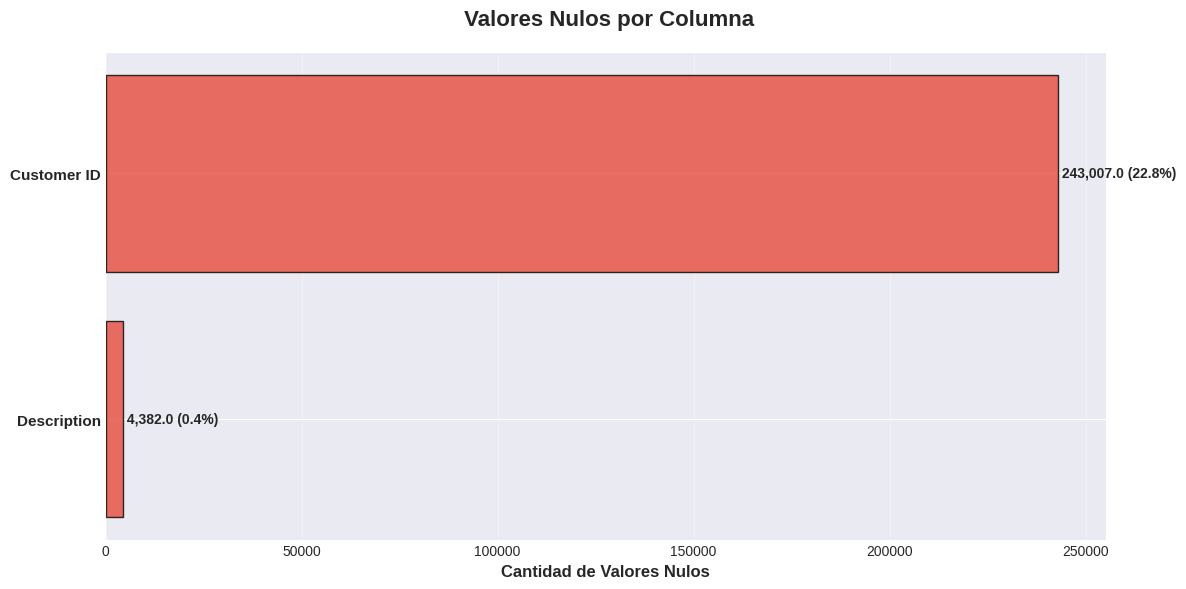

Invoices con Customer ID nulo: 8752
¿Son principalmente cancelaciones? 750
Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
RSA                         46
Bermuda                     34
Sweden                      19
Lebanon                     13
Nigeria                      2
Name: count, dtype: int64
Descripciones recuperadas: 363
% Revenue de transacciones sin Customer ID: 13.68%
customer_type
Registered                 824364
UK_Anonymous               240029
International_Anonymous      2978
Name: count, dtype: int64

Revenue por segmento:
customer_type
International_Anonymous      62797.31
Registered                16648292.39
UK_Anonymous               2576160.87
dtype: float64
                         Quantity  P

In [ ]:
# ----------------------------------------------------------------------------
# 4.1. ANÁLISIS DE VALORES NULOS
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("4. ANÁLISIS DE VALORES NULOS Y CALIDAD DE DATOS")
print("=" * 80)

# Calcular valores nulos
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df) * 100).round(2)

null_analysis = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentages
})

print("\n Resumen de valores nulos:")
display(null_analysis[null_analysis['Valores Nulos'] > 0])

print("\n Análisis específico de columnas con nulos:")
print(f"   - Customer ID: {df['Customer ID'].isnull().sum():,} nulos ({df['Customer ID'].isnull().sum()/len(df)*100:.2f}%)")
print(f"   - Description: {df['Description'].isnull().sum():,} nulos ({df['Description'].isnull().sum()/len(df)*100:.2f}%)")
print(f"   - Invoice: {df['Invoice'].isnull().sum():,} nulos")

# Visualización de valores nulos
if null_analysis['Valores Nulos'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    null_data = null_analysis[null_analysis['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=True)

    bars = ax.barh(range(len(null_data)), null_data['Valores Nulos'],
                   color='#E74C3C', edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(null_data)))
    ax.set_yticklabels(null_data.index, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cantidad de Valores Nulos', fontsize=12, fontweight='bold')
    ax.set_title(' Valores Nulos por Columna', fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)

    # Añadir valores y porcentajes
    for i, (idx, row) in enumerate(null_data.iterrows()):
        ax.text(row['Valores Nulos'], i,
                f" {row['Valores Nulos']:,} ({row['Porcentaje (%)']:.1f}%)",
                va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()



# Análisis adicional recomendado:
# ¿Estos nulos siguen algún patrón?
df_nulls = df[df['Customer ID'].isnull()]

# Verificar si son transacciones específicas:
print(f"Invoices con Customer ID nulo: {df_nulls['Invoice'].nunique()}")
print(f"¿Son principalmente cancelaciones? {df_nulls['Invoice'].str.contains('C').sum()}")

# ¿Hay países específicos con más nulos?
print(df_nulls['Country'].value_counts())

# Implementación del completado con StockCode:
desc_mapping = df.dropna(subset=['Description']).groupby('StockCode')['Description'].first()
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_mapping))

# Verificar efectividad:
print(f"Descripciones recuperadas: {df['Description'].isnull().sum()}")

#  Limpieza y conversión de Price para que Revenue no se cuelgue

df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(',', '.', regex=False)  # cambiar comas por puntos
    .str.strip()                         # eliminar espacios
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Crear Revenue de una vez (más eficiente que recalcular)

df['Revenue'] = df['Quantity'] * df['Price']


# Análisis de impacto financiero:
total_revenue = df['Revenue'].sum()
null_revenue = df.loc[df['Customer ID'].isnull(), 'Revenue'].sum()

print(f"% Revenue de transacciones sin Customer ID: {null_revenue / total_revenue * 100:.2f}%")

# Crear segmentos claros
df['customer_type'] = 'Unknown'
df.loc[df['Customer ID'].notna(), 'customer_type'] = 'Registered'
df.loc[(df['Customer ID'].isna()) & (df['Country'] == 'United Kingdom'), 'customer_type'] = 'UK_Anonymous'
df.loc[(df['Customer ID'].isna()) & (df['Country'] != 'United Kingdom'), 'customer_type'] = 'International_Anonymous'

print(df['customer_type'].value_counts())
print(f"\nRevenue por segmento:")
print(df.groupby('customer_type').apply(lambda x: (x['Quantity'] * x['Price']).sum()))
# Comparar comportamiento registered vs anonymous
comparison = df.groupby('customer_type').agg({
    'Quantity': 'mean',
    'Price': 'mean',
    'Invoice': 'nunique'
}).round(2)
print(comparison)
# Para análisis de clientes individuales
df_customers = df[df['Customer ID'].notna()].copy()

# Para análisis de mercado/producto (incluye todos)
df_market = df.copy()

# Para análisis B2B específico
df_b2b = df[df['customer_type'] == 'UK_Anonymous'].copy()


# Análisis profundo recomendado
uk_anon = df[df['customer_type'] == 'UK_Anonymous']

# ¿Qué productos compran?
print("Top 10 productos UK_Anonymous:")
print(uk_anon.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))

# ¿Hay patrones temporales?
uk_anon['InvoiceDate'] = pd.to_datetime(uk_anon['InvoiceDate'])
print("\nFrecuencia por día de la semana:")
print(uk_anon['InvoiceDate'].dt.day_name().value_counts())

# ¿Son compras recurrentes o one-time?
print(f"\nFacturas promedio por Invoice: {uk_anon.groupby('Invoice')['StockCode'].count().mean():.1f} items")

# UK_Anonymous representa £2.5M con bajo engagement
# Si conviertes 20% a Registered:
potential_revenue = 2576160.87 * 0.20
print(f"Revenue potencial de conversión: £{potential_revenue:,.2f}")

# Con aumento de ticket promedio del 15%:
registered_avg_ticket = 16648292.39 / 44876  # £371
uk_anon_avg_ticket = 2576160.87 / 8603  # £299

print(f"\nTicket promedio Registered: £{registered_avg_ticket:.2f}")
print(f"Ticket promedio UK_Anonymous: £{uk_anon_avg_ticket:.2f}")
print(f"Upside potencial: {(registered_avg_ticket/uk_anon_avg_ticket - 1)*100:.1f}%")

# Verificar si realmente son compras unitarias pequeñas
uk_anon = df[df['customer_type'] == 'UK_Anonymous']

# Distribución de cantidades
print("Distribución de Quantity:")
print(uk_anon['Quantity'].describe())
print("\nHistograma de cantidades:")
print(uk_anon['Quantity'].value_counts().head(20))

# ¿Cuántas líneas por factura realmente?
lineas_por_factura = uk_anon.groupby('Invoice').size()
print(f"\nLíneas por factura - Estadísticas:")
print(lineas_por_factura.describe())

# ¿Hay facturas grandes que distorsionen el promedio?
print("\nTop 10 facturas por número de líneas:")
print(lineas_por_factura.sort_values(ascending=False).head(10))

# Verificar si 27.9 es el promedio real o hay outliers
print(f"\nMediana de líneas por factura: {lineas_por_factura.median()}")
print(f"Promedio de líneas por factura: {lineas_por_factura.mean():.1f}")

# Análisis corregido
uk_anon = df[df['customer_type'] == 'UK_Anonymous']
lineas = uk_anon.groupby('Invoice').size()

print("="*70)
print("DISTRIBUCIÓN REAL DE FACTURAS UK_ANONYMOUS")
print("="*70)

# Crear buckets
distribucion = {
    '1 línea (walk-in simple)': (lineas == 1).sum(),
    '2-5 líneas (compra pequeña)': ((lineas >= 2) & (lineas <= 5)).sum(),
    '6-20 líneas (compra media)': ((lineas >= 6) & (lineas <= 20)).sum(),
    '21-50 líneas (mayorista pequeño)': ((lineas >= 21) & (lineas <= 50)).sum(),
    '51-100 líneas (mayorista medio)': ((lineas >= 51) & (lineas <= 100)).sum(),
    '>100 líneas (pedido masivo)': (lineas > 100).sum()
}

total_facturas = len(lineas)
for categoria, count in distribucion.items():
    pct = count/total_facturas*100
    print(f"{categoria:.<45} {count:>5} ({pct:>5.1f}%)")

print(f"\n{'TOTAL':.<45} {total_facturas:>5} (100.0%)")

# Revenue por segmento
revenue_por_size = uk_anon.groupby('Invoice').apply(
    lambda x: (x['Quantity'] * x['Price']).sum()
)

print("\n" + "="*70)
print("REVENUE POR TAMAÑO DE FACTURA")
print("="*70)

revenue_dist = {
    '1 línea': revenue_por_size[lineas == 1].sum(),
    '2-5 líneas': revenue_por_size[(lineas >= 2) & (lineas <= 5)].sum(),
    '6-20 líneas': revenue_por_size[(lineas >= 6) & (lineas <= 20)].sum(),
    '21-50 líneas': revenue_por_size[(lineas >= 21) & (lineas <= 50)].sum(),
    '51-100 líneas': revenue_por_size[(lineas >= 51) & (lineas <= 100)].sum(),
    '>100 líneas': revenue_por_size[lineas > 100].sum()
}

total_revenue = sum(revenue_dist.values())
for categoria, rev in revenue_dist.items():
    pct = rev/total_revenue*100
    print(f"{categoria:.<30} £{rev:>12,.2f} ({pct:>5.1f}%)")

print(f"\n{'TOTAL':.<30} £{total_revenue:>12,.2f} (100.0%)")

# Análisis para entender las devoluciones
uk_anon = df[df['customer_type'] == 'UK_Anonymous'].copy()

print("="*70)
print("ANÁLISIS DE DEVOLUCIONES UK_ANONYMOUS")
print("="*70)

# Identificar devoluciones
uk_anon['es_devolucion'] = (uk_anon['Quantity'] < 0) | (uk_anon['Invoice'].str.contains('C', na=False))

devoluciones = uk_anon[uk_anon['es_devolucion']]
ventas = uk_anon[~uk_anon['es_devolucion']]

print(f"\nTRANSACCIONES:")
print(f"Ventas:        {len(ventas):,} ({len(ventas)/len(uk_anon)*100:.1f}%)")
print(f"Devoluciones:  {len(devoluciones):,} ({len(devoluciones)/len(uk_anon)*100:.1f}%)")

print(f"\nREVENUE:")
revenue_ventas = (ventas['Quantity'] * ventas['Price']).sum()
revenue_devoluciones = (devoluciones['Quantity'] * devoluciones['Price']).sum()
print(f"Ventas brutas:     £{revenue_ventas:,.2f}")
print(f"Devoluciones:      £{revenue_devoluciones:,.2f}")
print(f"Revenue neto:      £{revenue_ventas + revenue_devoluciones:,.2f}")

print(f"\nFACTURAS:")
facturas_ventas = ventas['Invoice'].nunique()
facturas_dev = devoluciones['Invoice'].nunique()
print(f"Facturas de venta:      {facturas_ventas:,}")
print(f"Facturas con devolución: {facturas_dev:,}")

# Análisis por tamaño de factura
lineas_por_factura = uk_anon.groupby('Invoice').size()
uk_anon['lineas_factura'] = uk_anon['Invoice'].map(lineas_por_factura)

print("\n" + "="*70)
print("TASA DE DEVOLUCIÓN POR TAMAÑO DE FACTURA")
print("="*70)

for rango, (min_l, max_l) in [
    ('1 línea', (1, 1)),
    ('2-5 líneas', (2, 5)),
    ('6-20 líneas', (6, 20)),
    ('21-50 líneas', (21, 50)),
    ('51-100 líneas', (51, 100)),
    ('>100 líneas', (101, 9999))
]:
    mask = (uk_anon['lineas_factura'] >= min_l) & (uk_anon['lineas_factura'] <= max_l)
    subset = uk_anon[mask]

    if len(subset) > 0:
        dev_rate = subset['es_devolucion'].sum() / len(subset) * 100
        rev_total = (subset['Quantity'] * subset['Price']).sum()

        print(f"{rango:.<30} {dev_rate:>5.1f}% dev | Revenue: £{rev_total:>12,.2f}")

        # Hipótesis a investigar:
print("="*70)
print("INVESTIGACIÓN DE DEVOLUCIONES - FACTURAS 1 LÍNEA")
print("="*70)

uk_anon_1linea = df[
    (df['customer_type'] == 'UK_Anonymous') &
    (df.groupby('Invoice')['Invoice'].transform('size') == 1)
].copy()

# Identificar devoluciones
devoluciones_1l = uk_anon_1linea[
    (uk_anon_1linea['Quantity'] < 0) |
    (uk_anon_1linea['Invoice'].str.contains('C', na=False))
]

print("\n TOP PRODUCTOS DEVUELTOS (1 línea):")
print(devoluciones_1l['Description'].value_counts().head(10))

print("\n TOP PRODUCTOS VENDIDOS (1 línea):")
ventas_1l = uk_anon_1linea[
    (uk_anon_1linea['Quantity'] > 0) &
    (~uk_anon_1linea['Invoice'].str.contains('C', na=False))
]
print(ventas_1l['Description'].value_counts().head(10))

print("\n PATRÓN TEMPORAL:")
uk_anon_1linea['Month'] = pd.to_datetime(uk_anon_1linea['InvoiceDate']).dt.to_period('M')
temporal = uk_anon_1linea.groupby('Month').apply(
    lambda x: (x['Quantity'] < 0).sum() / len(x) * 100
)
print(temporal.tail(12))  # Últimos 12 meses

print("\n ANÁLISIS DE PRECIOS:")
print(f"Precio promedio devoluciones: £{devoluciones_1l['Price'].mean():.2f}")
print(f"Precio promedio ventas:       £{ventas_1l['Price'].mean():.2f}")

### 4.2 Analisis CostumerId

AL SER TAN ALTA LA TASA DE CustomerID anonimo, nos adentramos en su estudio

In [ ]:
# Análisis adicional CustomerID Nulo:
# ¿Estos nulos siguen algún patrón?
df_nulls = df[df['Customer ID'].isnull()]

# Verificar si son transacciones específicas:
print(f"Invoices con Customer ID nulo: {df_nulls['Invoice'].nunique()}")
print(f"¿Son principalmente cancelaciones? {df_nulls['Invoice'].str.contains('C').sum()}")

# ¿Hay países específicos con más nulos?
print(df_nulls['Country'].value_counts())

# Implementación del completado con StockCode:
desc_mapping = df.dropna(subset=['Description']).groupby('StockCode')['Description'].first()
df['Description'] = df.apply(
    lambda row: desc_mapping.get(row['StockCode']) if pd.isna(row['Description']) else row['Description'],
    axis=1
)

# Verificar efectividad:
print(f"Descripciones recuperadas: {df['Description'].isnull().sum()}")

# Análisis de impacto financiero:
total_revenue = (df['Quantity'] * df['Price']).sum()
null_revenue = (df[df['Customer ID'].isnull()]['Quantity'] *
                df[df['Customer ID'].isnull()]['Price']).sum()

print(f"% Revenue de transacciones sin Customer ID: {null_revenue/total_revenue*100:.2f}%")

# Crear segmentos claros
df['customer_type'] = 'Unknown'
df.loc[df['Customer ID'].notna(), 'customer_type'] = 'Registered'
df.loc[(df['Customer ID'].isna()) & (df['Country'] == 'United Kingdom'), 'customer_type'] = 'UK_Anonymous'
df.loc[(df['Customer ID'].isna()) & (df['Country'] != 'United Kingdom'), 'customer_type'] = 'International_Anonymous'

print(df['customer_type'].value_counts())
print(f"\nRevenue por segmento:")
print(df.groupby('customer_type').apply(lambda x: (x['Quantity'] * x['Price']).sum()))
# Comparar comportamiento registered vs anonymous
comparison = df.groupby('customer_type').agg({
    'Quantity': 'mean',
    'Price': 'mean',
    'Invoice': 'nunique'
}).round(2)
print(comparison)
# Para análisis de clientes individuales
df_customers = df[df['Customer ID'].notna()].copy()

# Para análisis de mercado/producto (incluye todos)
df_market = df.copy()

# Para análisis B2B específico
df_b2b = df[df['customer_type'] == 'UK_Anonymous'].copy()


# Análisis profundo recomendado
uk_anon = df[df['customer_type'] == 'UK_Anonymous']

# ¿Qué productos compran?
print("Top 10 productos UK_Anonymous:")
print(uk_anon.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))

# ¿Hay patrones temporales?
uk_anon['InvoiceDate'] = pd.to_datetime(uk_anon['InvoiceDate'])
print("\nFrecuencia por día de la semana:")
print(uk_anon['InvoiceDate'].dt.day_name().value_counts())

# ¿Son compras recurrentes o one-time?
print(f"\nFacturas promedio por Invoice: {uk_anon.groupby('Invoice')['StockCode'].count().mean():.1f} items")

# UK_Anonymous representa £2.5M con bajo engagement
# Si conviertes 20% a Registered:
potential_revenue = 2576160.87 * 0.20
print(f"Revenue potencial de conversión: £{potential_revenue:,.2f}")

# Con aumento de ticket promedio del 15%:
registered_avg_ticket = 16648292.39 / 44876  # £371
uk_anon_avg_ticket = 2576160.87 / 8603  # £299

print(f"\nTicket promedio Registered: £{registered_avg_ticket:.2f}")
print(f"Ticket promedio UK_Anonymous: £{uk_anon_avg_ticket:.2f}")
print(f"Upside potencial: {(registered_avg_ticket/uk_anon_avg_ticket - 1)*100:.1f}%")

# Verificar si realmente son compras unitarias pequeñas
uk_anon = df[df['customer_type'] == 'UK_Anonymous']

# Distribución de cantidades
print("Distribución de Quantity:")
print(uk_anon['Quantity'].describe())
print("\nHistograma de cantidades:")
print(uk_anon['Quantity'].value_counts().head(20))

# ¿Cuántas líneas por factura realmente?
lineas_por_factura = uk_anon.groupby('Invoice').size()
print(f"\nLíneas por factura - Estadísticas:")
print(lineas_por_factura.describe())

# ¿Hay facturas grandes que distorsionen el promedio?
print("\nTop 10 facturas por número de líneas:")
print(lineas_por_factura.sort_values(ascending=False).head(10))

# Verificar si 27.9 es el promedio real o hay outliers
print(f"\nMediana de líneas por factura: {lineas_por_factura.median()}")
print(f"Promedio de líneas por factura: {lineas_por_factura.mean():.1f}")

# Análisis corregido
uk_anon = df[df['customer_type'] == 'UK_Anonymous']
lineas = uk_anon.groupby('Invoice').size()

print("="*70)
print("DISTRIBUCIÓN REAL DE FACTURAS UK_ANONYMOUS")
print("="*70)

# Crear buckets
distribucion = {
    '1 línea (walk-in simple)': (lineas == 1).sum(),
    '2-5 líneas (compra pequeña)': ((lineas >= 2) & (lineas <= 5)).sum(),
    '6-20 líneas (compra media)': ((lineas >= 6) & (lineas <= 20)).sum(),
    '21-50 líneas (mayorista pequeño)': ((lineas >= 21) & (lineas <= 50)).sum(),
    '51-100 líneas (mayorista medio)': ((lineas >= 51) & (lineas <= 100)).sum(),
    '>100 líneas (pedido masivo)': (lineas > 100).sum()
}

total_facturas = len(lineas)
for categoria, count in distribucion.items():
    pct = count/total_facturas*100
    print(f"{categoria:.<45} {count:>5} ({pct:>5.1f}%)")

print(f"\n{'TOTAL':.<45} {total_facturas:>5} (100.0%)")

# Revenue por segmento
revenue_por_size = uk_anon.groupby('Invoice').apply(
    lambda x: (x['Quantity'] * x['Price']).sum()
)

print("\n" + "="*70)
print("REVENUE POR TAMAÑO DE FACTURA")
print("="*70)

revenue_dist = {
    '1 línea': revenue_por_size[lineas == 1].sum(),
    '2-5 líneas': revenue_por_size[(lineas >= 2) & (lineas <= 5)].sum(),
    '6-20 líneas': revenue_por_size[(lineas >= 6) & (lineas <= 20)].sum(),
    '21-50 líneas': revenue_por_size[(lineas >= 21) & (lineas <= 50)].sum(),
    '51-100 líneas': revenue_por_size[(lineas >= 51) & (lineas <= 100)].sum(),
    '>100 líneas': revenue_por_size[lineas > 100].sum()
}

total_revenue = sum(revenue_dist.values())
for categoria, rev in revenue_dist.items():
    pct = rev/total_revenue*100
    print(f"{categoria:.<30} £{rev:>12,.2f} ({pct:>5.1f}%)")

print(f"\n{'TOTAL':.<30} £{total_revenue:>12,.2f} (100.0%)")

# ANÁLISIS URGENTE: Entender las devoluciones
uk_anon = df[df['customer_type'] == 'UK_Anonymous'].copy()

print("="*70)
print("ANÁLISIS DE DEVOLUCIONES UK_ANONYMOUS")
print("="*70)

# Identificar devoluciones
uk_anon['es_devolucion'] = (uk_anon['Quantity'] < 0) | (uk_anon['Invoice'].str.contains('C', na=False))

devoluciones = uk_anon[uk_anon['es_devolucion']]
ventas = uk_anon[~uk_anon['es_devolucion']]

print(f"\nTRANSACCIONES:")
print(f"Ventas:        {len(ventas):,} ({len(ventas)/len(uk_anon)*100:.1f}%)")
print(f"Devoluciones:  {len(devoluciones):,} ({len(devoluciones)/len(uk_anon)*100:.1f}%)")

print(f"\nREVENUE:")
revenue_ventas = (ventas['Quantity'] * ventas['Price']).sum()
revenue_devoluciones = (devoluciones['Quantity'] * devoluciones['Price']).sum()
print(f"Ventas brutas:     £{revenue_ventas:,.2f}")
print(f"Devoluciones:      £{revenue_devoluciones:,.2f}")
print(f"Revenue neto:      £{revenue_ventas + revenue_devoluciones:,.2f}")

print(f"\nFACTURAS:")
facturas_ventas = ventas['Invoice'].nunique()
facturas_dev = devoluciones['Invoice'].nunique()
print(f"Facturas de venta:      {facturas_ventas:,}")
print(f"Facturas con devolución: {facturas_dev:,}")

# Análisis por tamaño de factura
lineas_por_factura = uk_anon.groupby('Invoice').size()
uk_anon['lineas_factura'] = uk_anon['Invoice'].map(lineas_por_factura)

print("\n" + "="*70)
print("TASA DE DEVOLUCIÓN POR TAMAÑO DE FACTURA")
print("="*70)

for rango, (min_l, max_l) in [
    ('1 línea', (1, 1)),
    ('2-5 líneas', (2, 5)),
    ('6-20 líneas', (6, 20)),
    ('21-50 líneas', (21, 50)),
    ('51-100 líneas', (51, 100)),
    ('>100 líneas', (101, 9999))
]:
    mask = (uk_anon['lineas_factura'] >= min_l) & (uk_anon['lineas_factura'] <= max_l)
    subset = uk_anon[mask]

    if len(subset) > 0:
        dev_rate = subset['es_devolucion'].sum() / len(subset) * 100
        rev_total = (subset['Quantity'] * subset['Price']).sum()

        print(f"{rango:.<30} {dev_rate:>5.1f}% dev | Revenue: £{rev_total:>12,.2f}")

        # Hipótesis a investigar:
print("="*70)
print("INVESTIGACIÓN DE DEVOLUCIONES - FACTURAS 1 LÍNEA")
print("="*70)

uk_anon_1linea = df[
    (df['customer_type'] == 'UK_Anonymous') &
    (df.groupby('Invoice')['Invoice'].transform('size') == 1)
].copy()

# Identificar devoluciones
devoluciones_1l = uk_anon_1linea[
    (uk_anon_1linea['Quantity'] < 0) |
    (uk_anon_1linea['Invoice'].str.contains('C', na=False))
]

print("\n TOP PRODUCTOS DEVUELTOS (1 línea):")
print(devoluciones_1l['Description'].value_counts().head(10))

print("\n TOP PRODUCTOS VENDIDOS (1 línea):")
ventas_1l = uk_anon_1linea[
    (uk_anon_1linea['Quantity'] > 0) &
    (~uk_anon_1linea['Invoice'].str.contains('C', na=False))
]
print(ventas_1l['Description'].value_counts().head(10))

print("\n PATRÓN TEMPORAL:")
uk_anon_1linea['Month'] = pd.to_datetime(uk_anon_1linea['InvoiceDate']).dt.to_period('M')
temporal = uk_anon_1linea.groupby('Month').apply(
    lambda x: (x['Quantity'] < 0).sum() / len(x) * 100
)
print(temporal.tail(12))  # Últimos 12 meses

print("\n ANÁLISIS DE PRECIOS:")
print(f"Precio promedio devoluciones: £{devoluciones_1l['Price'].mean():.2f}")
print(f"Precio promedio ventas:       £{ventas_1l['Price'].mean():.2f}")

Invoices con Customer ID nulo: 8752
¿Son principalmente cancelaciones? 750
Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
RSA                         46
Bermuda                     34
Sweden                      19
Lebanon                     13
Nigeria                      2
Name: count, dtype: int64
Descripciones recuperadas: 363
% Revenue de transacciones sin Customer ID: 13.68%
customer_type
Registered                 824364
UK_Anonymous               240029
International_Anonymous      2978
Name: count, dtype: int64

Revenue por segmento:
customer_type
International_Anonymous      62797.31
Registered                16648292.39
UK_Anonymous               2576160.87
dtype: float64
                         Quantity  P

**Insights:**

DISTRIBUCIÓN DE TRANSACCIONES:

    • Registered (con Customer ID):     824,364 transacciones (77.2%)
    • UK_Anonymous:                     240,029 transacciones (22.5%)
    • International_Anonymous:            2,978 transacciones (0.3%)

REVENUE POR SEGMENTO:

    • Registered:                £16,648,292 (86.0%)
    • UK_Anonymous:              £2,576,161  (13.3%)
    • International_Anonymous:   £62,797     (0.3%)

TOTAL SIN CUSTOMER ID: £2,638,958 (13.68% del negocio total)  - NO PODEMOS IGNORAR ESTA DATA

MÉTRICAS COMPARATIVAS:


    UK_Anonymous                      1.41 Qty/Trans      £7.87  Precio/Unit     8,603  Facturas
    Registered                       12.41 Qty/Trans      £3.68  Precio/Unit    44,876  Facturas
    International_Anonymous          11.75 Qty/Trans      £14.38 Precio/Unit      149  Facturas


TAMAÑO DE FACTURA                          

    1 línea                         5,938 Qty     (69.0%)  £-257,915 Rev  (-10.0%)
    2-5 líneas                        765 Qty     (8.9%)   £-78,167 Rev   (-3.0%)
    6-20 líneas                       477 Qty     (5.5%)   £43,082  Rev    (1.7%)
    21-50 líneas                      422 Qty     (4.9%)   £155,638 Rev    (6.0%)
    51-100 líneas                     205 Qty     (2.4%)   £370,752 Rev   (14.4%)
    +100 líneas                       796 Qty     (9.3%)   £2,342,771 Rev  (90.9%)

    TOTAL                           8,603 Qty   (100.0%)   £2,576,161 Rev (100.0%)

9.3% de facturas (pedidos >100 líneas) generan 90.9% del revenue
77.9% de facturas (1-5 líneas) tienen revenue NEGATIVO (-13%)

### 4.3 **Analisis de devoluciones**

TRANSACCIONES UK_ANONYMOUS:

    Ventas:                 235,927  (98.3%)
    Devoluciones:             4,102  (1.7%)

REVENUE:

    Ventas brutas:      £2,989,154
    Devoluciones:       £-412,993
    Revenue neto:       £2,576,161

TAMAÑO FACTURA              

    1 línea                         60.3%         £-257,915
    2-5 líneas                      16.3%         £-78,167
    6-20 líneas                      1.6%         £43,082
    21-50 líneas                     0.6%         £155,638
    51-100 líneas                    0.0%         £370,752
    +100 líneas                      0.0%         £2,342,771

 60.3% de las facturas de 1 línea son "devoluciones"

TOP "PRODUCTOS" EN FACTURAS DE 1 LÍNEA CON QTY NEGATIVA:

    UNKNOWN                   303
    check                     119
    Manual                     90
    damages                    82
    ?                          80
    damaged                    78
    Bank Charges               47
    AMAZON FEE                 27
    missing                    27
    sold as set on dotcom      20

Entendemos que son:
    Ajustes manuales ("Manual", "check", "adjustment")
    Costos operativos ("Bank Charges", "AMAZON FEE", "POSTAGE")
    Problemas de inventario ("damages", "missing", "damaged")
    Items sin clasificar ("UNKNOWN", "?")

POR LO TANTO INFERIMOS QUE SON AJUSTES CONTABLES, NO SON DEVOLUCIONES


## **5. Análisis de anomalías**


1.   **Conversión robusta de Tipos de datos:** Analizamos el tipo de dato de cada columna y determinamos si podemos o no establecer algún tipo de dato más acorde al actual (ejemplo, columas con tipo String reconvertidas a num). **Convertimos Price de Object a Float64**
2.   **Análisis de valores:** Evaluamos las columnas con datos numéricos para poder tomar decisiones. Esto va a ser muy importante para que podamos determinar qué es lo que tenemos en cada uno de los casos.

 En base a esto determinamos que:

*   Son ***ventas normales*** aquellas que la cantidad y el precio ambos son mayores a 0. Tenemos 1.041.671 de casos (97.59%)
*   Son ***Devoluciones*** aquellas que la cantidad es menor a 0 y el precio es mayor a 0. Tenemos 19.493 de casos (1.83%)
*   Son ***Muestras/regalos*** aquellos que la cantidad es mayor a 0 y el precio es 0. Tenemos 2.745 casos (0.26%)
*   Son ***Ajustes negativos*** aquellos que la cantidad es menor a 0 y el precio es 0. Tenemos 3.457 (0.32%)
*   Son ***Precios negativos*** aquellos cuyo precio es menor a 0. Tenemos 5 casos (> 0.01%)

## **6. Preparación de datos**

En esta etapa continuamos con la modificación de los tipos de datos y continuamos con la organización de la información. Partiendo de 1.067.371 hicimos lo siguiente **en este orden**
 1.   Convertimos la columna InvoiceDate a Datetime.
 2.   Completamos en los casos en donde la descripción estaba incompleta, primero tratando de obtener la descripción tomando de alguna de los otros registros que tengan la descripción. En su defecto, que ponga en la descripción "UNKNOWN". Haciendo esto recuperamos 4.019 datos de 4.382 vacíos que teníamos.
 3.   Creamos la columna totalPrice que surge de multiplicar en cada registro cantidad por precio.
 4.   Creamos las variables temporales con el fin de poder obtener mejor información temporal respecto a los pagos.
 5.   Creamos la variable IsUK para poder evaluar si se trata de una compra nacional o internacional.
 6.   Separamos en tres DF distintos para trabajar:
   
    df_sales (ventas con cliente): 805,549 registros

    df_returns (devoluciones): 19,493 registros

    df_clean (dataset completo limpio): 1,067,366 registros
 7.   Eliminamos los datos con valor negativo.


       ANÁLISIS DE ANOMALÍAS Y CLASIFICACIÓN DE TRANSACCIONES

 Preparando datos...
--------------------------------------------------------------------------------
 Procesando 'Price'
   └─ Tipo original: float64
   └─  Ya es numérico
 Procesando 'Customer ID'
   └─ Tipo original: float64
   └─  Ya es numérico

 Columna 'TotalPrice' creada
 InvoiceDate convertido a datetime
 Description completado - ¡Recuperamos 0 casos!
 Variables temporales creadas
 Variable IsUK creada

 Clasificando transacciones...
   └─  1,067,371 transacciones clasificadas


 RESUMEN DE CLASIFICACIÓN:
--------------------------------------------------------------------------------
Tipo                               Cantidad          %         Revenue
--------------------------------------------------------------------------------
Product Sale                      1,036,661     97.12% £20,127,471.35
Product Return                       18,579      1.74% £  -754,920.98
Costs                                 3,713

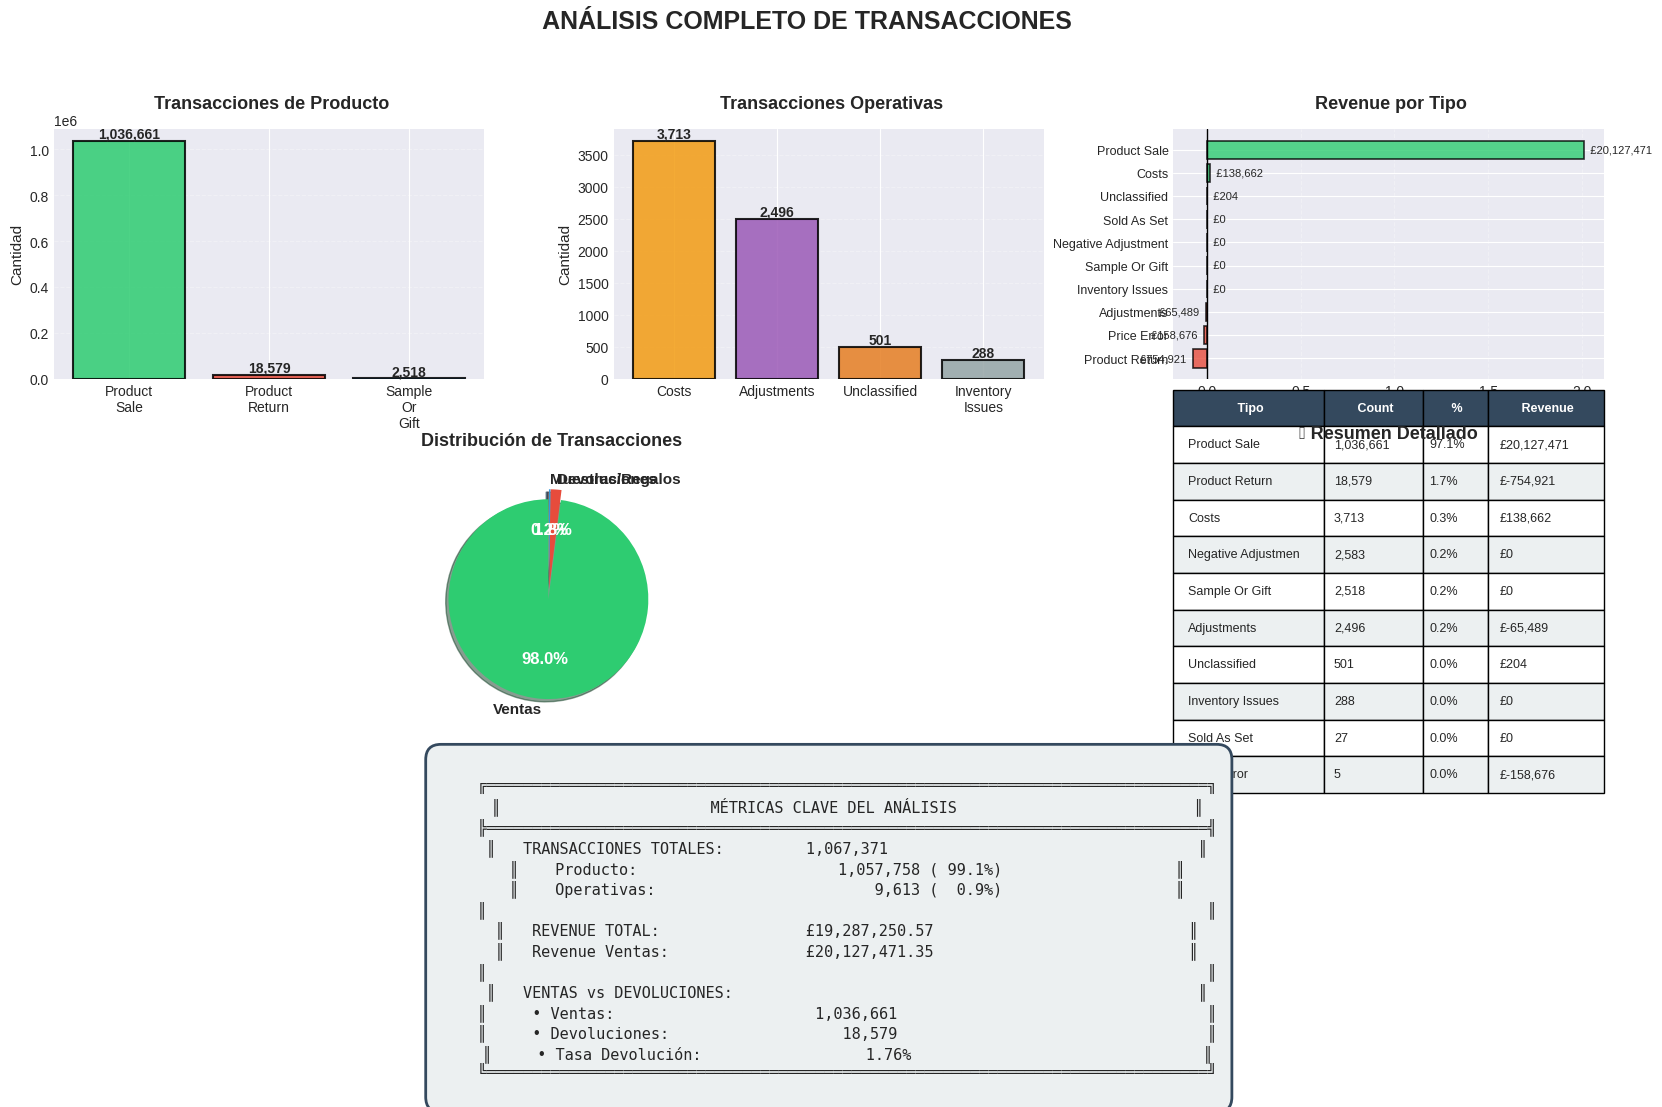


  PROCESO FINALIZADO EXITOSAMENTE

 PRÓXIMOS PASOS SUGERIDOS:
   1. Usar 'df_sales' para análisis de clientes y segmentación
   2. Usar 'df_returns' para análisis de devoluciones
   3. Usar 'df_clean' para análisis generales de ventas


In [ ]:
# ============================================================================
# 5. ANÁLISIS DE ANOMALÍAS Y CLASIFICACIÓN DE TRANSACCIONES
# ============================================================================



OPERATIONAL_KEYWORDS = {
    'adjustments': ['manual', 'check', 'adjustment', 'found', 'mailout'],
    'costs': ['bank charges', 'amazon fee', 'postage'],
    'inventory_issues': ['damages', 'damaged', 'missing', 'lost', 'crushed', 'smashed'],
    'unclassified': ['unknown', '?', 'test', 'dotcom postage'],
    'sold_as_set': ['sold as set']
}

# ============================================================================
# FUNCIONES
# ============================================================================

def safe_numeric_conversion(dataframe: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """Convierte columna a numérico de forma segura."""
    df = dataframe.copy()
    original_dtype = df[column_name].dtype

    print(f" Procesando '{column_name}'")
    print(f"   └─ Tipo original: {original_dtype}")

    if original_dtype == 'object':
        df[column_name] = pd.to_numeric(
            df[column_name].astype(str).str.replace(',', '.').str.strip(),
            errors='coerce'
        )

        nan_count = df[column_name].isna().sum()
        success_rate = (1 - nan_count / len(df)) * 100

        print(f"   └─  Convertido a: {df[column_name].dtype}")
        print(f"   └─  Éxito: {success_rate:.1f}%")

        if nan_count > 0:
            print(f"   └─   {nan_count:,} NaN generados")
    else:
        print(f"   └─  Ya es numérico")

    return df


def classify_transaction_type(row: pd.Series) -> str:
    """Clasifica tipo de transacción."""
    description = str(row['Description']).lower().strip()
    quantity = row['Quantity']
    price = row['Price']

    for category, keywords in OPERATIONAL_KEYWORDS.items():
        if any(keyword in description for keyword in keywords):
            return category

    if quantity > 0 and price > 0:
        return 'product_sale'
    elif quantity < 0 and price > 0:
        return 'product_return'
    elif quantity > 0 and price == 0:
        return 'sample_or_gift'
    elif quantity < 0 and price == 0:
        return 'negative_adjustment'
    elif price < 0:
        return 'price_error'
    elif quantity == 0:
        return 'zero_quantity'
    else:
        return 'unclassified'


def analyze_transaction_types(df: pd.DataFrame) -> Tuple[Dict, pd.Series, pd.DataFrame]:
    """Analiza y clasifica transacciones."""
    print("\n Clasificando transacciones...")

    df['transaction_type'] = df.apply(classify_transaction_type, axis=1)
    type_counts = df['transaction_type'].value_counts().to_dict()
    type_revenue = df.groupby('transaction_type')['TotalPrice'].sum()

    print(f"   └─  {len(df):,} transacciones clasificadas")

    return type_counts, type_revenue, df









def identify_and_mark_cancelled_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Versión CORREGIDA: Usa los índices correctos del dataframe original.
    """

    print("\n Identificando pares cancelados (modo optimizado)...")

    df_marked = df.copy()
    df_marked['is_cancelled_pair'] = False

    # Guardar el índice original como columna
    df_marked['_original_index'] = df_marked.index

    # Separar cancelaciones y compras
    mask_cancel = df_marked['Invoice'].astype(str).str.startswith('C')

    cancelaciones = df_marked[mask_cancel].copy()
    compras = df_marked[~mask_cancel].copy()

    print(f"   └─  Cancelaciones: {len(cancelaciones):,}")
    print(f"   └─  Compras: {len(compras):,}")

    if len(cancelaciones) == 0:
        print("   └─  No hay cancelaciones")
        return df_marked

    print(f"   └─  Preparando datos para merge...")

    # Preparar datos
    cancelaciones['CustomerID_norm'] = cancelaciones['Customer ID'].fillna(-1).astype(float).astype(int)
    cancelaciones['Quantity_positive'] = -cancelaciones['Quantity']
    cancelaciones['Price_rounded'] = cancelaciones['Price'].round(2)

    compras['CustomerID_norm'] = compras['Customer ID'].fillna(-1).astype(float).astype(int)
    compras['Price_rounded'] = compras['Price'].round(2)

    print(f"   └─  Buscando coincidencias con merge...")

    # Preparar cancelaciones para merge
    cancel_cols = cancelaciones[[
        'StockCode', 'CustomerID_norm', 'Quantity_positive', 'Price_rounded',
        'Invoice', '_original_index'
    ]].copy()

    cancel_cols.columns = [
        'StockCode', 'CustomerID_norm', 'Quantity', 'Price_rounded',
        'CancelInvoice', 'CancelOriginalIndex'
    ]


    matched = compras.merge(
        cancel_cols,
        on=['StockCode', 'CustomerID_norm', 'Quantity', 'Price_rounded'],
        how='inner'
    )

    print(f"   └─ ✅ Pares encontrados: {len(matched):,}")

    if len(matched) == 0:
        print("   └─ ℹ️  No hay coincidencias")
        df_marked = df_marked.drop('_original_index', axis=1)
        return df_marked


    # Obtener los índices ORIGINALES (no los del subset)
    compras_original_indices = matched['_original_index'].tolist()
    cancel_original_indices = matched['CancelOriginalIndex'].tolist()

    # Marcar usando los índices originales
    all_indices_to_mark = compras_original_indices + cancel_original_indices
    df_marked.loc[all_indices_to_mark, 'is_cancelled_pair'] = True

    # Estadísticas
    print(f"      • Compras marcadas:       {len(compras_original_indices):,}")
    print(f"      • Cancelaciones marcadas: {len(cancel_original_indices):,}")
    print(f"      • Total:                  {len(all_indices_to_mark):,} ({len(all_indices_to_mark)/len(df_marked)*100:.2f}%)")

    # Verificación específica 581483
    if '581483' in matched['Invoice'].astype(str).values:
        caso = matched[matched['Invoice'].astype(str) == '581483'].iloc[0]
        idx_581483 = caso['_original_index']

        print(f"\n    VERIFICACIÓN ESPECÍFICA 581483:")
        print(f"      Índice original: {idx_581483}")
        print(f"      is_cancelled_pair marcado: {df_marked.loc[idx_581483, 'is_cancelled_pair']}")
        print(f"      Cancelación: {caso['CancelInvoice']}")

    # TOP 5
    top_5 = matched.nlargest(5, 'TotalPrice')

    print(f"\n    TOP 5 PARES:")
    print("   " + "-" * 76)

    for i, (idx, row) in enumerate(top_5.iterrows(), 1):
        print(f"\n   {i}. {row['Invoice']} ↔ {row['CancelInvoice']}")
        print(f"      {row['Description'][:55]}")
        print(f"      Cantidad: {row['Quantity']:,} | Valor: £{row['TotalPrice']:,.2f}")

    # Limpiar columna temporal
    df_marked = df_marked.drop('_original_index', axis=1)

    return df_marked





def create_clean_datasets(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """Crea datasets especializados EXCLUYENDO pares cancelados."""

    print("\n Creando datasets especializados...")

    # PASO 1: Filtrar pares cancelados
    if 'is_cancelled_pair' in df.columns:
        cancelled_count = (df['is_cancelled_pair'] == True).sum()
        print(f"   └─   Excluidos {cancelled_count:,} registros de pares cancelados")

        df_filtered = df[df['is_cancelled_pair'] == False].copy()
        print(f"   └─  Registros disponibles: {len(df_filtered):,}")

        # Verificación: ¿581483 está en df_filtered?
        if '581483' in df['Invoice'].astype(str).values:
            if '581483' in df_filtered['Invoice'].astype(str).values:
                print(f"   └─   ADVERTENCIA: 581483 AÚN está en df_filtered")
            else:
                print(f"   └─  CONFIRMADO: 581483 fue excluida correctamente")
    else:
        print(f"   └─  Columna 'is_cancelled_pair' NO encontrada - NO se aplicó filtro")
        df_filtered = df.copy()

    datasets = {}

    # PASO 2: Crear datasets desde df_filtered
    datasets['sales'] = df_filtered[
        (df_filtered['transaction_type'] == 'product_sale') &
        (df_filtered['Customer ID'].notna())
    ].copy()

    if len(datasets['sales']) > 0:
        datasets['sales']['Customer ID'] = datasets['sales']['Customer ID'].astype(int)

    datasets['returns'] = df_filtered[
        df_filtered['transaction_type'] == 'product_return'
    ].copy()

    operational_types = ['adjustments', 'costs', 'inventory_issues', 'unclassified']
    datasets['operational'] = df_filtered[
        df_filtered['transaction_type'].isin(operational_types)
    ].copy()

    datasets['anonymous_sales'] = df_filtered[
        (df_filtered['transaction_type'] == 'product_sale') &
        (df_filtered['Customer ID'].isna())
    ].copy()

    datasets['clean'] = df_filtered[
        ~df_filtered['transaction_type'].isin(['price_error', 'zero_quantity'])
    ].copy()

    print(f"\n    Datasets creados (sin pares cancelados):")
    for name, dataset in datasets.items():
        print(f"      └─ df_{name:<18s}: {len(dataset):>8,} registros")

    return datasets




def visualize_transaction_analysis(type_counts: Dict, type_revenue: pd.Series):
    """Crea visualizaciones mejoradas."""

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(' ANÁLISIS COMPLETO DE TRANSACCIONES',
                 fontsize=18, fontweight='bold', y=0.98)

    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

    # ========================================================================
    # GRÁFICO 1: Transacciones de Producto
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    sales_types = {k: v for k, v in type_counts.items()
                   if k in ['product_sale', 'product_return', 'sample_or_gift']}

    if sales_types:
        colors = ['#2ecc71', '#e74c3c', '#3498db']
        ax1.bar(range(len(sales_types)), sales_types.values(),
                color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
        ax1.set_xticks(range(len(sales_types)))
        ax1.set_xticklabels([k.replace('_', '\n').title() for k in sales_types.keys()], fontsize=10)
        ax1.set_title(' Transacciones de Producto', fontsize=13, fontweight='bold', pad=15)
        ax1.set_ylabel('Cantidad', fontsize=11)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')

        for i, v in enumerate(sales_types.values()):
            ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # ========================================================================
    # GRÁFICO 2: Operaciones
    # ========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    operational_types = {k: v for k, v in type_counts.items()
                        if k in ['adjustments', 'costs', 'inventory_issues', 'unclassified']}

    if operational_types:
        colors = ['#f39c12', '#9b59b6', '#e67e22', '#95a5a6']
        ax2.bar(range(len(operational_types)), operational_types.values(),
                color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
        ax2.set_xticks(range(len(operational_types)))
        ax2.set_xticklabels([k.replace('_', '\n').title() for k in operational_types.keys()], fontsize=10)
        ax2.set_title(' Transacciones Operativas', fontsize=13, fontweight='bold', pad=15)
        ax2.set_ylabel('Cantidad', fontsize=11)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')

        for i, v in enumerate(operational_types.values()):
            ax2.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, ' Sin operaciones', ha='center', va='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title(' Transacciones Operativas', fontsize=13, fontweight='bold', pad=15)

    # ========================================================================
    # GRÁFICO 3: Revenue por Tipo
    # ========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    revenue_data = type_revenue.sort_values(ascending=True)
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in revenue_data.values]

    ax3.barh(range(len(revenue_data)), revenue_data.values,
             color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax3.set_yticks(range(len(revenue_data)))
    ax3.set_yticklabels([k.replace('_', ' ').title() for k in revenue_data.index], fontsize=9)
    ax3.set_title(' Revenue por Tipo', fontsize=13, fontweight='bold', pad=15)
    ax3.set_xlabel('Revenue (£)', fontsize=11)
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax3.grid(axis='x', alpha=0.3, linestyle='--')

    for i, valor in enumerate(revenue_data.values):
        label = f'£{abs(valor):,.0f}'
        ha = 'left' if valor >= 0 else 'right'
        ax3.text(valor, i, f'  {label}' if valor >= 0 else f'{label}  ',
                va='center', ha=ha, fontsize=8)

    # ========================================================================
    # GRÁFICO 4: Pie Chart
    # ========================================================================
    ax4 = fig.add_subplot(gs[1, :2])
    sales_only = {
        'Ventas': type_counts.get('product_sale', 0),
        'Devoluciones': type_counts.get('product_return', 0),
        'Muestras/Regalos': type_counts.get('sample_or_gift', 0)
    }
    sales_only = {k: v for k, v in sales_only.items() if v > 0}

    if sales_only:
        colors = ['#2ecc71', '#e74c3c', '#3498db']
        explode = [0.08] + [0.02] * (len(sales_only) - 1)
        wedges, texts, autotexts = ax4.pie(
            sales_only.values(), labels=sales_only.keys(),
            autopct='%1.1f%%', startangle=90,
            colors=colors, explode=explode, shadow=True,
            textprops={'fontsize': 11, 'fontweight': 'bold'}
        )

        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(12)

        ax4.set_title(' Distribución de Transacciones', fontsize=13, fontweight='bold', pad=15)

    # ========================================================================
    # GRÁFICO 5: Tabla Resumen
    # ========================================================================
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')

    summary_data = []
    total_count = sum(type_counts.values())

    for tipo in sorted(type_counts.keys(), key=lambda x: type_counts[x], reverse=True):
        count = type_counts[tipo]
        revenue = type_revenue.get(tipo, 0)
        pct = (count / total_count) * 100
        summary_data.append([
            tipo.replace('_', ' ').title()[:18],
            f'{count:,}',
            f'{pct:.1f}%',
            f'£{revenue:,.0f}'
        ])

    table = ax5.table(
        cellText=summary_data,
        colLabels=[' Tipo', ' Count', ' %', ' Revenue'],
        cellLoc='left', loc='center',
        colWidths=[0.35, 0.23, 0.15, 0.27]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.2)

    for i in range(len(summary_data) + 1):
        for j in range(4):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#34495e')
                cell.set_text_props(weight='bold', color='white')
            else:
                cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')

    ax5.set_title('📄 Resumen Detallado', fontsize=13, fontweight='bold', pad=20)

    # ========================================================================
    # GRÁFICO 6: Panel de Métricas
    # ========================================================================
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('off')

    total_trans = sum(type_counts.values())
    product_trans = sum(v for k, v in type_counts.items()
                       if k in ['product_sale', 'product_return', 'sample_or_gift'])
    operational_trans = total_trans - product_trans

    real_sales = type_counts.get('product_sale', 0)
    real_returns = type_counts.get('product_return', 0)
    return_rate = (real_returns / (real_sales + real_returns) * 100) if (real_sales + real_returns) > 0 else 0

    total_revenue = type_revenue.sum()
    sales_revenue = type_revenue.get('product_sale', 0)

    metrics_text = f"""
    ╔═══════════════════════════════════════════════════════════════════════════════╗
    ║                       MÉTRICAS CLAVE DEL ANÁLISIS                          ║
    ╠═══════════════════════════════════════════════════════════════════════════════╣
    ║   TRANSACCIONES TOTALES:        {total_trans:>10,}                                  ║
    ║    Producto:                     {product_trans:>10,} ({product_trans/total_trans*100:>5.1f}%)                   ║
    ║    Operativas:                   {operational_trans:>10,} ({operational_trans/total_trans*100:>5.1f}%)                   ║
    ║                                                                               ║
    ║   REVENUE TOTAL:                £{total_revenue:>13,.2f}                            ║
    ║   Revenue Ventas:               £{sales_revenue:>13,.2f}                            ║
    ║                                                                               ║
    ║   VENTAS vs DEVOLUCIONES:                                                   ║
    ║     • Ventas:                     {real_sales:>10,}                                  ║
    ║     • Devoluciones:               {real_returns:>10,}                                  ║
    ║     • Tasa Devolución:            {return_rate:>10.2f}%                                ║
    ╚═══════════════════════════════════════════════════════════════════════════════╝
    """

    ax6.text(0.5, 0.5, metrics_text, ha='center', va='center',
            fontfamily='monospace', fontsize=11,
            bbox=dict(boxstyle='round,pad=1', facecolor='#ecf0f1',
                     edgecolor='#34495e', linewidth=2))

    plt.tight_layout()
    plt.show()


def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """Prepara datos: conversiones, limpieza y features temporales."""
    print("\n Preparando datos...")
    print("-" * 80)

    # Conversiones numéricas
    df = safe_numeric_conversion(df, 'Price')
    df = safe_numeric_conversion(df, 'Customer ID')

    # Eliminar Price NaN
    price_nans = df['Price'].isna().sum()
    if price_nans > 0:
        print(f"\n  {price_nans:,} registros con Price = NaN ({price_nans/len(df)*100:.2f}%)")
        print(f"   └─ Eliminando...")
        df = df[df['Price'].notna()].copy()
        print(f"   └─  Nuevo tamaño: {len(df):,} registros")

    # TotalPrice
    if 'TotalPrice' not in df.columns:
        df['TotalPrice'] = df['Quantity'] * df['Price']
        print(f"\n Columna 'TotalPrice' creada")

    # Convertir InvoiceDate
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    print(f" InvoiceDate convertido a datetime")

    # Completar Description usando StockCode
    casos_NA = df['Description'].isna().sum()
    if casos_NA > 0:
        desc_map = df.dropna(subset=['Description']).drop_duplicates('StockCode').set_index('StockCode')['Description']
        df['Description'] = df.apply(
            lambda row: desc_map.get(row['StockCode'], 'UNKNOWN') if pd.isna(row['Description']) else row['Description'],
            axis=1
        )
        recuperados = casos_NA - (df['Description'] == 'UNKNOWN').sum()
        print(f" Description completado - ¡Recuperamos {recuperados} casos!")

    # Variables temporales
    df['Year'] = df['InvoiceDate'].dt.year
    df['Month'] = df['InvoiceDate'].dt.month
    df['MonthName'] = df['InvoiceDate'].dt.month_name()
    df['Week'] = df['InvoiceDate'].dt.isocalendar().week
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
    df['DayOfWeekNum'] = df['InvoiceDate'].dt.dayofweek
    df['Day'] = df['InvoiceDate'].dt.day
    df['Hour'] = df['InvoiceDate'].dt.hour
    df['Date'] = df['InvoiceDate'].dt.date
    df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
    print(f" Variables temporales creadas")

    # Variable geográfica
    df['IsUK'] = df['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'International')
    print(f" Variable IsUK creada")

    return df


# ============================================================================
#  EJECUCIÓN PRINCIPAL
# ============================================================================

print("\n" + "="*80)
print("       ANÁLISIS DE ANOMALÍAS Y CLASIFICACIÓN DE TRANSACCIONES")
print("="*80)

# PASO 1: Preparar datos
df = prepare_data(df)

# PASO 2: Clasificar transacciones

type_counts, type_revenue, df = analyze_transaction_types(df)

print("\n" + "="*80)
# 4.8 Mostrar resumen de clasificación
print("\n RESUMEN DE CLASIFICACIÓN:")
print("-" * 80)
print(f"{'Tipo':<30} {'Cantidad':>12} {'%':>10} {'Revenue':>15}")
print("-" * 80)

for tipo in sorted(type_counts.keys(), key=lambda x: type_counts[x], reverse=True):
    count = type_counts[tipo]
    revenue = type_revenue.get(tipo, 0)
    pct = (count / len(df)) * 100
    print(f"{tipo.replace('_', ' ').title():<30} {count:>12,} {pct:>9.2f}% £{revenue:>13,.2f}")


# PASO 3: Identificar y marcar pares cancelados
df = identify_and_mark_cancelled_pairs(df)


# PASO 4: Crear datasets especializados
datasets = create_clean_datasets(df)

# Asignar a variables globales para fácil acceso
df_sales = datasets['sales']
df_returns = datasets['returns']
df_operational = datasets['operational']
df_anonymous_sales = datasets['anonymous_sales']
df_clean = datasets['clean']





# PASO 5: Mostrar información de datasets
print("\n" + "="*80)
print("  ANÁLISIS COMPLETADO - DATASETS DISPONIBLES:")
print("="*80)
print(f"""
   df                  → Dataset ORIGINAL completo          ({len(df):,} registros)
   df_sales            → Ventas CON Customer ID (LIMPIO)    ({len(df_sales):,} registros) ✨
   df_returns          → Devoluciones REALES                ({len(df_returns):,} registros)
   df_operational      → Ajustes contables/costos           ({len(df_operational):,} registros)
   df_anonymous_sales  → Ventas SIN Customer ID             ({len(df_anonymous_sales):,} registros)
   df_clean            → Dataset limpio sin errores         ({len(df_clean):,} registros)
""")

# PASO 6: Visualizaciones
print("\n Generando visualizaciones...")
print("-" * 80)
visualize_transaction_analysis(type_counts, type_revenue)

print("\n" + "="*80)
print("  PROCESO FINALIZADO EXITOSAMENTE")
print("="*80)
print("\n PRÓXIMOS PASOS SUGERIDOS:")
print("   1. Usar 'df_sales' para análisis de clientes y segmentación")
print("   2. Usar 'df_returns' para análisis de devoluciones")
print("   3. Usar 'df_clean' para análisis generales de ventas")
print("="*80)




## **7. Estadísticas descriptivas**
 Ahora analizamos *df_sales*. Este DF, que lo creamos en el paso anterior, **tiene solamente los registros que tinene indicado el cliente registrado**. Vamos a usar este DF para hacer analisis respecto a los clientes.

 Las estadísticas de venta nos van a indicar la cantidad de registros, la media, desviación estandard, el valor mínimo, los percentiles 25, 50 y 75 y los valores máximos de las variables numércias que tenemos (Quantity -cantidad-, Price -Precio por unidad- y TotalPrice -Precio por cantidad-)
  Luego analizamos los principales KPIs del negocio.


Luego hacemos una breve descripción de los valores temporales que manejamos, tales como fecha de inicio, fecha de finalización días y meses analizados.

Por último, hacemos un análisis de las devoluciones, indicando la cantidad de registros, el porcentaje del total y el monto total perdido por devoluciones.

In [ ]:
# ----------------------------------------------------------------------------
# 7. ESTADÍSTICAS DESCRIPTIVAS POST-LIMPIEZA
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("6. ESTADÍSTICAS DESCRIPTIVAS (DATASET LIMPIO)")
print("=" * 80)

print("\n Estadísticas de las ventas:")
display(df_sales[['Quantity', 'Price', 'TotalPrice']].describe())

print("\n KPIs PRINCIPALES DEL NEGOCIO:")
print(f"    Revenue Total: £{df_sales['TotalPrice'].sum():,.2f}")
print(f"    Transacciones únicas: {df_sales['Invoice'].nunique():,}")
print(f"    Clientes únicos: {df_sales['Customer ID'].nunique():,}")
print(f"    Productos únicos: {df_sales['StockCode'].nunique():,}")
print(f"    Países atendidos: {df_sales['Country'].nunique()}")
print(f"    Ticket promedio: £{df_sales.groupby('Invoice')['TotalPrice'].sum().mean():,.2f}")
print(f"    Gasto promedio por cliente: £{df_sales.groupby('Customer ID')['TotalPrice'].sum().mean():,.2f}")
print(f"    Compras promedio por cliente: {df_sales.groupby('Customer ID')['Invoice'].nunique().mean():.2f}")

print("\n Información temporal:")
print(f"   - Fecha inicio: {df_sales['InvoiceDate'].min()}")
print(f"   - Fecha fin: {df_sales['InvoiceDate'].max()}")
print(f"   - Días de operación: {(df_sales['InvoiceDate'].max() - df_sales['InvoiceDate'].min()).days}")
print(f"   - Meses de operación: {df_sales['YearMonth'].nunique()}")

print("\n Información de devoluciones:")
total_transacciones = len(df_clean)
tasa_devolucion = (len(df_returns) / total_transacciones * 100)
print(f"   - Total devoluciones: {len(df_returns):,}")
print(f"   - Tasa de devolución: {tasa_devolucion:.2f}%")
print(f"   - Revenue perdido por devoluciones: £{abs(df_returns['TotalPrice'].sum()):,.2f}")


6. ESTADÍSTICAS DESCRIPTIVAS (DATASET LIMPIO)

 Estadísticas de las ventas:


,Quantity,Price,TotalPrice
count,790074.00,790074.00,790074.00
mean,12.89,2.91,21.10
std,72.37,4.15,80.30
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,5.00,1.95,11.80
75%,12.00,3.75,19.50
max,19152.00,649.50,38970.00



 KPIs PRINCIPALES DEL NEGOCIO:
    Revenue Total: £16,670,410.35
    Transacciones únicas: 36,128
    Clientes únicos: 5,834
    Productos únicos: 4,608
    Países atendidos: 41
    Ticket promedio: £461.43
    Gasto promedio por cliente: £2,857.46
    Compras promedio por cliente: 6.19

 Información temporal:
   - Fecha inicio: 2009-12-01 07:45:00
   - Fecha fin: 2011-12-09 12:50:00
   - Días de operación: 738
   - Meses de operación: 25

 Información de devoluciones:
   - Total devoluciones: 11,330
   - Tasa de devolución: 1.08%
   - Revenue perdido por devoluciones: £181,868.68


Con esto **damos por finalizado el trabajo de limpieza de la base de datos.**

##**8. Análisis de outliers**

 Los outliers son valores **reales** que pueden distorsionar los valores estadísiticos. En consecuencia, **deben ser tenido en cuenta por su utilidad** (Por ejemplo, para definir potenciales clientes VIP) pero, que a los fines estadísticos deben descartarse con el fin de poder tener valores que tengan relación con los datos más agrupados.

 Para detectar los outliers creamos una función que utiliza la diferencia entre el Q3 y Q1. Para estblecer los valores por debajo del Q1 vamos a este valor restarle el resultante del rango intercuartiles por 1.5, para los valores superiores, vamos a sumarle a Q3 el resultante del rango intercuartiler por 1.5


7. DETECCIÓN Y ANÁLISIS DE OUTLIERS

 Análisis de outliers en TotalPrice:
   - Límite inferior: £-16.88
   - Límite superior: £41.33
   - Número de outliers: 63,197 (8.00%)
   - Valor máximo: £38,970.00


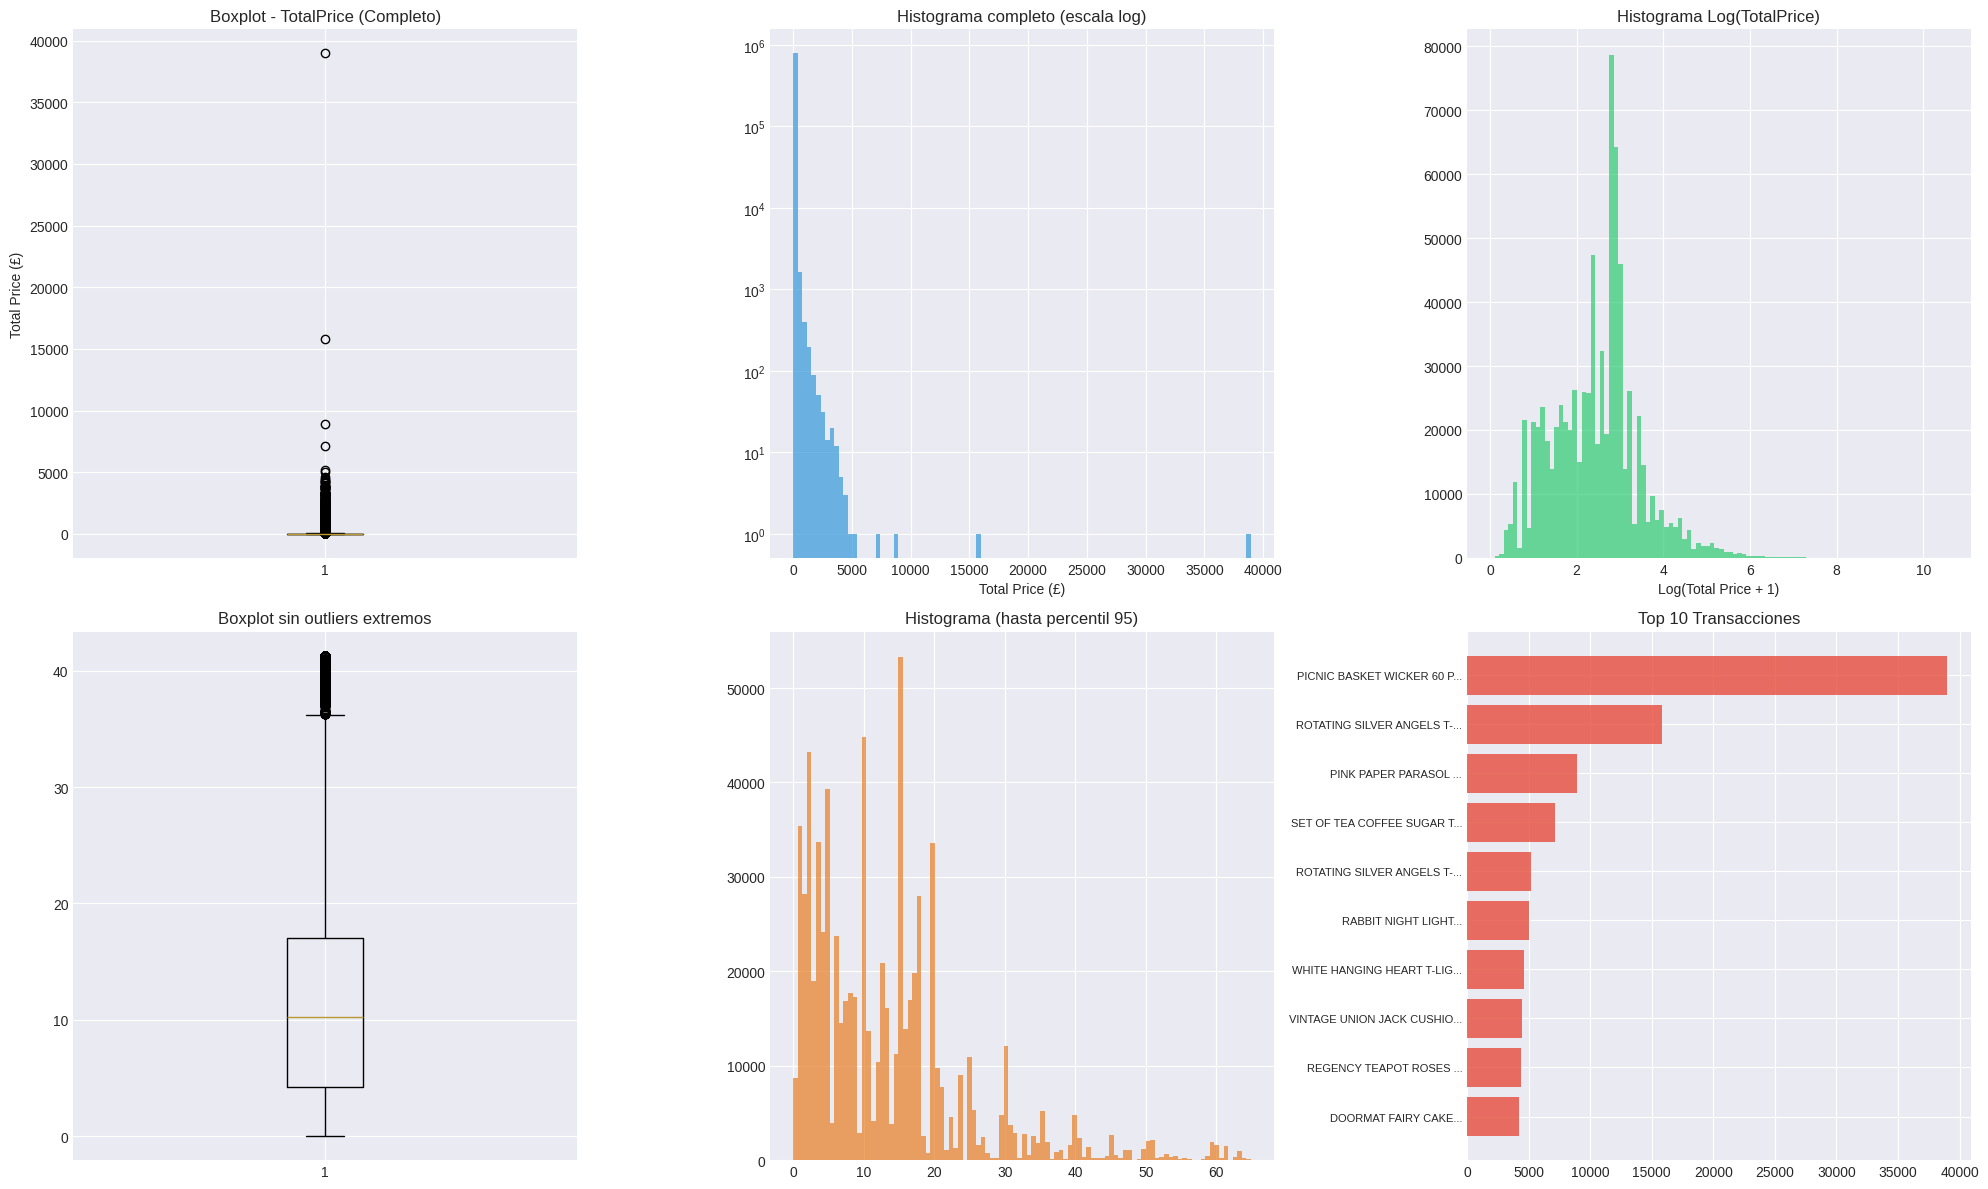


 ESTADÍSTICAS CLAVE:
 - Media: £21.10
 - Mediana: £11.80
 - Desviación estándar: £80.30
 - Percentil 25: £4.95
 - Percentil 75: £19.50
 - Percentil 95: £64.90
 - Percentil 99: £185.00


In [ ]:
# ----------------------------------------------------------------------------
# 8. ANÁLISIS DE OUTLIERS
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("7. DETECCIÓN Y ANÁLISIS DE OUTLIERS")
print("=" * 80)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detectar outliers en TotalPrice
outliers_price, lower, upper = detect_outliers_iqr(df_sales, 'TotalPrice')

print(f"\n Análisis de outliers en TotalPrice:")
print(f"   - Límite inferior: £{lower:.2f}")
print(f"   - Límite superior: £{upper:.2f}")
print(f"   - Número de outliers: {len(outliers_price):,} ({len(outliers_price)/len(df_sales)*100:.2f}%)")
print(f"   - Valor máximo: £{df_sales['TotalPrice'].max():,.2f}")

# Visualización de outliers
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Boxplot completo
axes[0, 0].boxplot(df_sales['TotalPrice'], vert=True)
axes[0, 0].set_title('Boxplot - TotalPrice (Completo)')
axes[0, 0].set_ylabel('Total Price (£)')

# 2. Histograma completo (log scale Y)
axes[0, 1].hist(df_sales['TotalPrice'], bins=100, color='#3498DB', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Histograma completo (escala log)')
axes[0, 1].set_xlabel('Total Price (£)')

# 3. Histograma log-transformado
log_prices = np.log1p(df_sales['TotalPrice'])
axes[0, 2].hist(log_prices, bins=100, color='#2ECC71', alpha=0.7)
axes[0, 2].set_title('Histograma Log(TotalPrice)')
axes[0, 2].set_xlabel('Log(Total Price + 1)')

# 4. Boxplot sin outliers extremos
df_no_extreme = df_sales[df_sales['TotalPrice'] <= upper]
axes[1, 0].boxplot(df_no_extreme['TotalPrice'], vert=True)
axes[1, 0].set_title('Boxplot sin outliers extremos')

# 5. Histograma percentil 95
upper_95 = df_sales['TotalPrice'].quantile(0.95)
axes[1, 1].hist(df_sales['TotalPrice'][df_sales['TotalPrice'] <= upper_95],
                bins=100, color='#E67E22', alpha=0.7)
axes[1, 1].set_title('Histograma (hasta percentil 95)')

# 6. Top 10 transacciones
top_10 = df_sales.nlargest(10, 'TotalPrice')[['Description', 'TotalPrice']]
axes[1, 2].barh(range(10), top_10['TotalPrice'].values, color='#E74C3C', alpha=0.8)
axes[1, 2].set_yticks(range(10))
axes[1, 2].set_yticklabels([f"{d[:25]}..." for d in top_10['Description']], fontsize=8)
axes[1, 2].set_title('Top 10 Transacciones')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n ESTADÍSTICAS CLAVE:")
print(f" - Media: £{df_sales['TotalPrice'].mean():.2f}")
print(f" - Mediana: £{df_sales['TotalPrice'].median():.2f}")
print(f" - Desviación estándar: £{df_sales['TotalPrice'].std():.2f}")
print(f" - Percentil 25: £{df_sales['TotalPrice'].quantile(0.25):.2f}")
print(f" - Percentil 75: £{df_sales['TotalPrice'].quantile(0.75):.2f}")
print(f" - Percentil 95: £{df_sales['TotalPrice'].quantile(0.95):.2f}")
print(f" - Percentil 99: £{df_sales['TotalPrice'].quantile(0.99):.2f}")



    Boxplot Completo: Muestra la extrema dispersión con muchos puntos atípicos
    Histograma log-Y: Distribución sesgada a la derecha
    Histograma Log-transformado: Normaliza la visualización
    Boxplot sin extremos: Vista más clara del 90%+ de datos
    Histograma P95: El 95% de transacciones están bajo £66.60
    Top 10 Transacciones: Las compras más grandes del dataset

Insights Importantes
    
    Distribución muy sesgada: Media (£21.73) > Mediana (£11.80)
        Indica que pocos valores extremos elevan el promedio
    Desviación estándar enorme (£222.60):
        Mayor que la media misma
        Refleja alta variabilidad en los montos
    8.13% outliers:
        Proporción significativa de valores atípicos
        Pueden ser compras corporativas, mayoristas o errores
    Valor máximo sospechoso:
        £168,469.60 parece inusualmente alto
        (¿error o compra legítima?)

 DECISIÓN SOBRE OUTLIERS:
   
    ✓ Los outliers representan compras legítimas de alto valor
    ✓ Se mantendrán en el análisis (no son errores)
    ✓ Son importantes para análisis de clientes VIP

##**9. Análisis de correlación**

Analizamos la relación que tienen las variables numéricas. Los valores van de -1 a 1 siendo que mientras más cerca está del 0 la relación es más debil y, mientras más cerca está del -1 y del 1 es mayor la relación.


8. ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES

 Matriz de Correlación:


,Quantity,Price,TotalPrice
Quantity,1.00,-0.05,0.41
Price,-0.05,1.00,0.17
TotalPrice,0.41,0.17,1.00


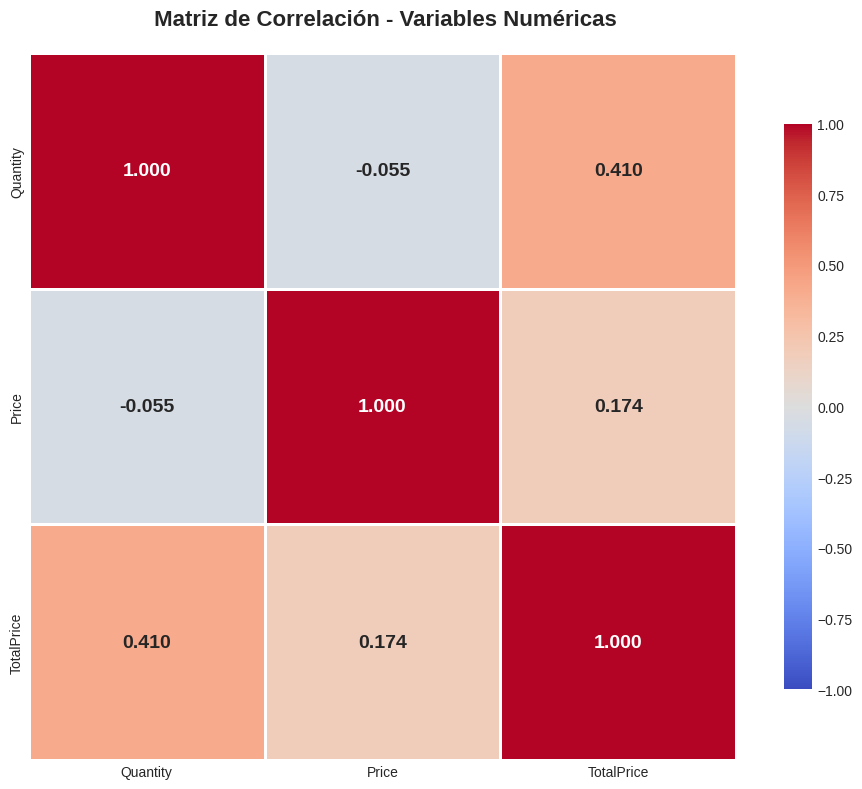


 INSIGHTS DE CORRELACIÓN:
   - Quantity ↔ TotalPrice: 0.410 (correlación moderada)
   - Price ↔ TotalPrice: 0.174 (correlación moderada)
   - Quantity ↔ Price: -0.055 (correlación débil)


In [ ]:
# ----------------------------------------------------------------------------
# 8. ANÁLISIS DE CORRELACIÓN
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("8. ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES")
print("=" * 80)

# Matriz de correlación
correlation_vars = ['Quantity', 'Price', 'TotalPrice']
correlation_matrix = df_sales[correlation_vars].corr()

print("\n Matriz de Correlación:")
display(correlation_matrix)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(' Matriz de Correlación - Variables Numéricas',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n INSIGHTS DE CORRELACIÓN:")
corr_qty_total = correlation_matrix.loc['Quantity', 'TotalPrice']
corr_price_total = correlation_matrix.loc['Price', 'TotalPrice']
corr_qty_price = correlation_matrix.loc['Quantity', 'Price']

print(f"   - Quantity ↔ TotalPrice: {corr_qty_total:.3f} (correlación {'fuerte' if abs(corr_qty_total) > 0.7 else 'moderada'})")
print(f"   - Price ↔ TotalPrice: {corr_price_total:.3f} (correlación {'fuerte' if abs(corr_price_total) > 0.7 else 'moderada'})")
print(f"   - Quantity ↔ Price: {corr_qty_price:.3f} (correlación {'débil' if abs(corr_qty_price) < 0.3 else 'moderada'})")

    La cantidad y el precio influyen en TotalPrice como se esperaba
    Price y Quantity son independientes (los clientes no compran más porque sea barato)

##**10. Comparación por períodos**
Comparamos ingreso final por período y cantidad de clientes por año. Compartimos los resultados analizados.


9. COMPARACIÓN ENTRE PERÍODOS 2009-2010 vs 2010-2011

 Comparación entre períodos:


,Transacciones,Clientes,Productos,Revenue,Unidades Vendidas
Period,,,,,
2009-2010,18727,4269,3995,8401576.10,5306956
2010-2011,18171,4322,3641,8268834.24,4879182



 CRECIMIENTO:
   - Revenue: -1.58%
   - Clientes: +1.24%


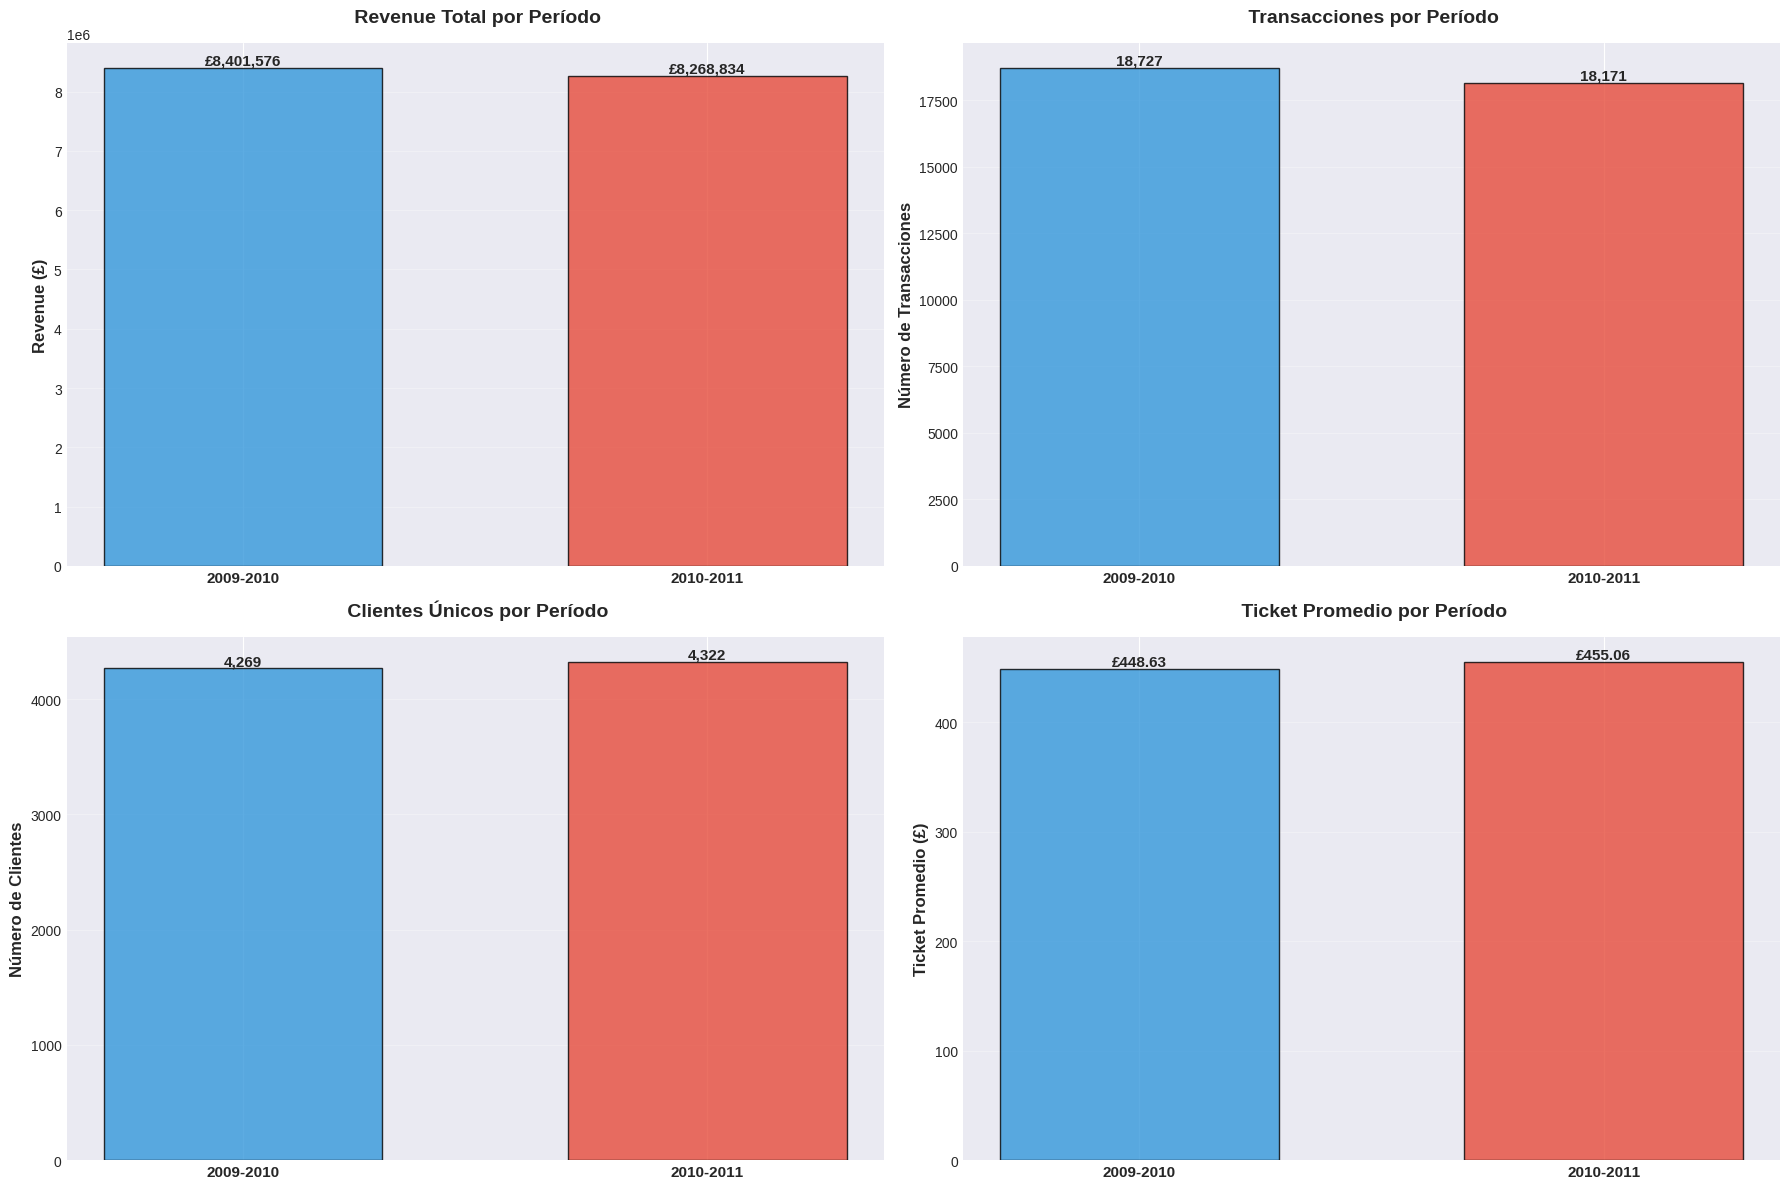

In [ ]:
# ----------------------------------------------------------------------------
# 9. COMPARACIÓN ENTRE PERÍODOS
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("9. COMPARACIÓN ENTRE PERÍODOS 2009-2010 vs 2010-2011")
print("=" * 80)

# Análisis por período
period_comparison = df_sales.groupby('Period').agg({
    'Invoice': 'nunique',
    'Customer ID': 'nunique',
    'StockCode': 'nunique',
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).round(2)

period_comparison.columns = ['Transacciones', 'Clientes', 'Productos', 'Revenue', 'Unidades Vendidas']

print("\n Comparación entre períodos:")
display(period_comparison)

# Calcular crecimiento
if len(period_comparison) == 2:
    periods = list(period_comparison.index)
    revenue_growth = ((period_comparison.loc[periods[1], 'Revenue'] -
                      period_comparison.loc[periods[0], 'Revenue']) /
                     period_comparison.loc[periods[0], 'Revenue'] * 100)

    customers_growth = ((period_comparison.loc[periods[1], 'Clientes'] -
                        period_comparison.loc[periods[0], 'Clientes']) /
                       period_comparison.loc[periods[0], 'Clientes'] * 100)

    print(f"\n CRECIMIENTO:")
    print(f"   - Revenue: {revenue_growth:+.2f}%")
    print(f"   - Clientes: {customers_growth:+.2f}%")

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Revenue por período
revenue_by_period = period_comparison['Revenue']
colors_period = ['#3498DB', '#E74C3C']
bars1 = axes[0, 0].bar(range(len(revenue_by_period)), revenue_by_period.values,
                        color=colors_period, edgecolor='black', alpha=0.8, width=0.6)
axes[0, 0].set_xticks(range(len(revenue_by_period)))
axes[0, 0].set_xticklabels(revenue_by_period.index, fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Revenue (£)', fontsize=12, fontweight='bold')
axes[0, 0].set_title(' Revenue Total por Período', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, revenue_by_period.values)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val,
                    f'£{val:,.0f}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# 2. Transacciones por período
trans_by_period = period_comparison['Transacciones']
bars2 = axes[0, 1].bar(range(len(trans_by_period)), trans_by_period.values,
                        color=colors_period, edgecolor='black', alpha=0.8, width=0.6)
axes[0, 1].set_xticks(range(len(trans_by_period)))
axes[0, 1].set_xticklabels(trans_by_period.index, fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Número de Transacciones', fontsize=12, fontweight='bold')
axes[0, 1].set_title(' Transacciones por Período', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars2, trans_by_period.values)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val,
                    f'{val:,}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# 3. Clientes por período
customers_by_period = period_comparison['Clientes']
bars3 = axes[1, 0].bar(range(len(customers_by_period)), customers_by_period.values,
                        color=colors_period, edgecolor='black', alpha=0.8, width=0.6)
axes[1, 0].set_xticks(range(len(customers_by_period)))
axes[1, 0].set_xticklabels(customers_by_period.index, fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Número de Clientes', fontsize=12, fontweight='bold')
axes[1, 0].set_title(' Clientes Únicos por Período', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars3, customers_by_period.values)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val,
                    f'{val:,}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# 4. Ticket promedio por período
ticket_promedio = revenue_by_period / trans_by_period
bars4 = axes[1, 1].bar(range(len(ticket_promedio)), ticket_promedio.values,
                        color=colors_period, edgecolor='black', alpha=0.8, width=0.6)
axes[1, 1].set_xticks(range(len(ticket_promedio)))
axes[1, 1].set_xticklabels(ticket_promedio.index, fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Ticket Promedio (£)', fontsize=12, fontweight='bold')
axes[1, 1].set_title(' Ticket Promedio por Período', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars4, ticket_promedio.values)):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val,
                    f'£{val:.2f}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


##**11. Análisis temporal de ventas**
Hacemos un análisis temporal de las ventas. Observamos las mismas por mes y por mes agregado (es decir, la suma de las ventas de c/Enero, Febrero, etc), por día de la semana, por rango horario.


10. ANÁLISIS TEMPORAL DE VENTAS

 Ventas mensuales:


,Year,Month,MonthName,TotalPrice,Invoice,Customer ID
0,2009,12,December,668131.61,1482,949
1,2010,1,January,526136.52,945,694
2,2010,2,February,487408.92,1075,767
3,2010,3,March,656602.82,1495,1047
4,2010,4,April,567025.96,1301,933
5,2010,5,May,571086.95,1341,956
6,2010,6,June,603215.26,1463,1031
7,2010,7,July,560401.56,1334,919
8,2010,8,August,568329.94,1263,906
9,2010,9,September,783011.79,1633,1126



 Ventas por día:
DayOfWeek
Thursday     158355
Sunday       134407
Tuesday      134218
Wednesday    133978
Monday       125645
Friday       103086
Saturday        385
Name: count, dtype: int64


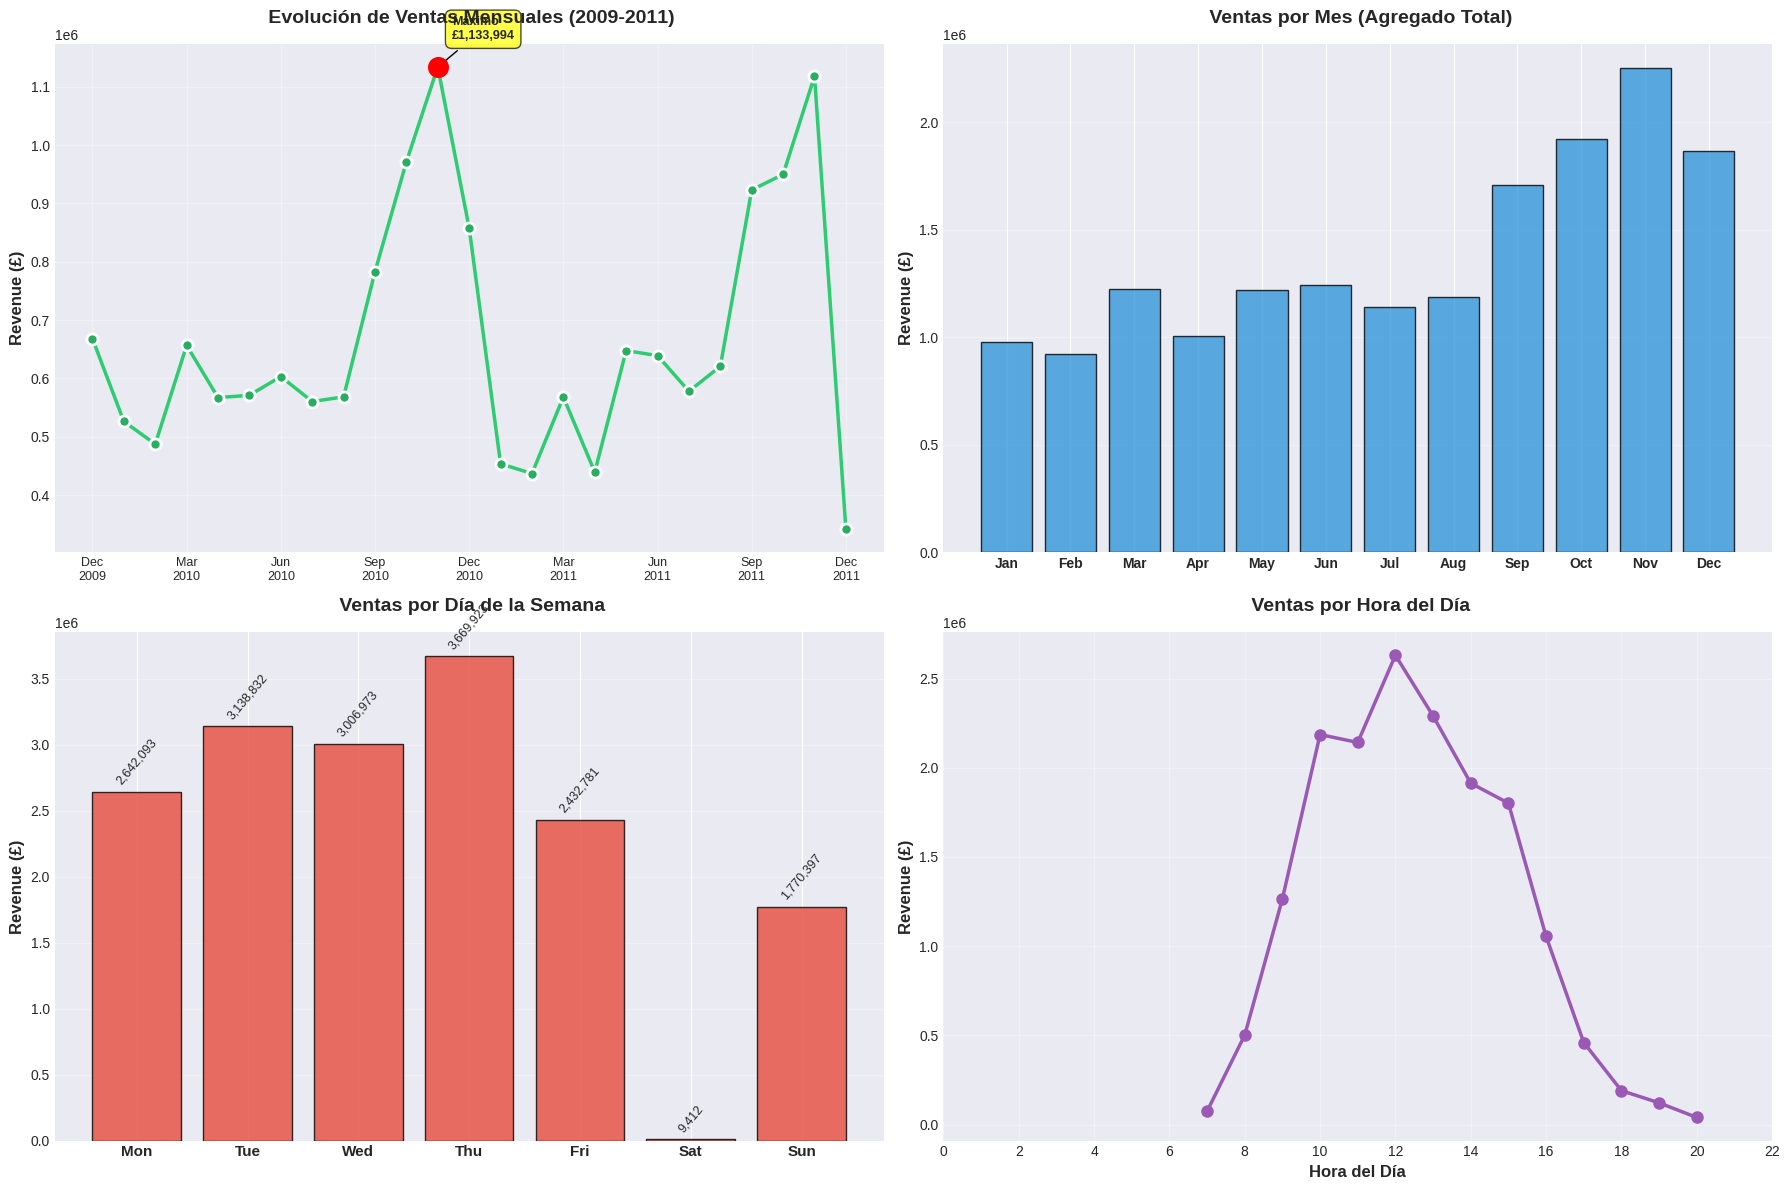


 INSIGHTS TEMPORALES:
   - Mejor mes: November 2010 (£1,133,993.51)
   - Peor mes: December 2011 (£341,554.13)
   - Mejor día de la semana: Thursday (£3,669,922.60)
   - Peor día de la semana: Saturday (£9,411.93)
   - Hora pico: 12:00 hrs (£2,630,953.66)

 ESTACIONALIDAD:
   - Q4 (Oct-Dic) representa: 36.2% de las ventas anuales
   - ✓ Hay fuerte estacionalidad hacia fin de año (probablemente Navidad)


In [ ]:
# ----------------------------------------------------------------------------
# 10. ANÁLISIS TEMPORAL - VENTAS POR MES
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("10. ANÁLISIS TEMPORAL DE VENTAS")
print("=" * 80)

# Ventas mensuales
monthly_sales = df_sales.groupby(['Year', 'Month', 'MonthName']).agg({
    'TotalPrice': 'sum',
    'Invoice': 'nunique',
    'Customer ID': 'nunique'
}).reset_index()

monthly_sales_sorted = monthly_sales.sort_values(['Year', 'Month'])

print("\n Ventas mensuales:")
display(monthly_sales_sorted.head(12))

# Ventas por mes (agregado todos los años)
meses_orden = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

ventas_por_mes = df_sales.groupby('MonthName')['TotalPrice'].sum().reindex(meses_orden)

# Visualización temporal
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución mensual continua
axes[0, 0].plot(range(len(monthly_sales_sorted)), monthly_sales_sorted['TotalPrice'].values,
                marker='o', linewidth=2.5, markersize=8, color='#2ECC71',
                markerfacecolor='#27AE60', markeredgewidth=2, markeredgecolor='white')
axes[0, 0].set_xticks(range(0, len(monthly_sales_sorted), 3))
axes[0, 0].set_xticklabels([f"{row['MonthName'][:3]}\n{int(row['Year'])}"
                             for _, row in monthly_sales_sorted.iloc[::3].iterrows()],
                            rotation=0, fontsize=9)
axes[0, 0].set_ylabel('Revenue (£)', fontsize=12, fontweight='bold')
axes[0, 0].set_title(' Evolución de Ventas Mensuales (2009-2011)',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(True, alpha=0.3)

# Resaltar máximo
max_idx = monthly_sales_sorted['TotalPrice'].idxmax()
max_month = monthly_sales_sorted.loc[max_idx]
max_pos = monthly_sales_sorted.index.get_loc(max_idx)
axes[0, 0].scatter(max_pos, max_month['TotalPrice'], color='red', s=200, zorder=5)
axes[0, 0].annotate(f"Máximo\n£{max_month['TotalPrice']:,.0f}",
                    xy=(max_pos, max_month['TotalPrice']),
                    xytext=(10, 20), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
                    fontsize=9, fontweight='bold')

# 2. Ventas por mes (agregado)
axes[0, 1].bar(range(len(ventas_por_mes)), ventas_por_mes.values,
               color='#3498DB', edgecolor='black', alpha=0.8)
axes[0, 1].set_xticks(range(len(ventas_por_mes)))
axes[0, 1].set_xticklabels([m[:3] for m in meses_orden], fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Revenue (£)', fontsize=12, fontweight='bold')
axes[0, 1].set_title(' Ventas por Mes (Agregado Total)',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Ventas por día de la semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df_sales.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order)

axes[1, 0].bar(range(len(dow_sales)), dow_sales.values,
               color='#E74C3C', edgecolor='black', alpha=0.8)
axes[1, 0].set_xticks(range(len(dow_sales)))
axes[1, 0].set_xticklabels([day[:3] for day in day_order], fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Revenue (£)', fontsize=12, fontweight='bold')
axes[1, 0].set_title(' Ventas por Día de la Semana',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(dow_sales.values):
    axes[1, 0].text(i, v + dow_sales.max()*0.01, f"{v:,.0f}",
                    ha='center', va='bottom', fontsize=9, rotation=50)
print("\n Ventas por día:")
print(df_sales['DayOfWeek'].value_counts())

# 4. Ventas por hora del día
hour_sales = df_sales.groupby('Hour')['TotalPrice'].sum()
axes[1, 1].plot(hour_sales.index, hour_sales.values,
                marker='o', color='#9B59B6', linewidth=2.5, markersize=8)
axes[1, 1].set_xlabel('Hora del Día', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Revenue (£)', fontsize=12, fontweight='bold')
axes[1, 1].set_title(' Ventas por Hora del Día',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# Insights temporales
print("\n INSIGHTS TEMPORALES:")
best_month = monthly_sales_sorted.loc[monthly_sales_sorted['TotalPrice'].idxmax()]
worst_month = monthly_sales_sorted.loc[monthly_sales_sorted['TotalPrice'].idxmin()]
print(f"   - Mejor mes: {best_month['MonthName']} {int(best_month['Year'])} (£{best_month['TotalPrice']:,.2f})")
print(f"   - Peor mes: {worst_month['MonthName']} {int(worst_month['Year'])} (£{worst_month['TotalPrice']:,.2f})")
print(f"   - Mejor día de la semana: {dow_sales.idxmax()} (£{dow_sales.max():,.2f})")
print(f"   - Peor día de la semana: {dow_sales.idxmin()} (£{dow_sales.min():,.2f})")
print(f"   - Hora pico: {hour_sales.idxmax()}:00 hrs (£{hour_sales.max():,.2f})")

# Detectar estacionalidad
print("\n ESTACIONALIDAD:")
q4_months = ['October', 'November', 'December']
q4_sales = ventas_por_mes[ventas_por_mes.index.isin(q4_months)].sum()
total_sales = ventas_por_mes.sum()
q4_percentage = (q4_sales / total_sales * 100)
print(f"   - Q4 (Oct-Dic) representa: {q4_percentage:.1f}% de las ventas anuales")
if q4_percentage > 33:
    print(f"   - ✓ Hay fuerte estacionalidad hacia fin de año (probablemente Navidad)")

##**12.  Análisis de productos**
Analizamos los productos mas vendidos, considerando las cantidades y la facturación de los mismos






11. ANÁLISIS DE PRODUCTOS

 Total de productos únicos: 5,287
   └─ Con al menos 2 transacciones: 5,090

TOP PRODUCTOS MÁS VENDIDOS

 TOP 10 por REVENUE:


,Description,TotalQuantity,Revenue,Transactions,AvgPrice
1855,REGENCY CAKESTAND 3 TIER,23330,268321.15,3053,11.50
4733,WHITE HANGING HEART T-LIGHT HOLDER,87768,236864.46,4792,2.70
4707,JUMBO BAG RED RETROSPOT,73402,132782.30,2580,1.81
4439,ASSORTED COLOUR BIRD ORNAMENT,79330,126178.42,2637,1.59
3612,PARTY BUNTING,23255,102341.43,2054,4.40
1443,PAPER CHAIN KIT 50'S CHRISTMAS,28531,77171.63,1672,2.70
3915,CHILLI LIGHTS,15576,72136.29,899,4.63
590,BLACK RECORD COVER FRAME,19605,67119.44,533,3.42
4711,JUMBO BAG STRAWBERRY,34955,62601.87,1499,1.79
3964,WOOD BLACK BOARD ANT WHITE FINISH,10877,60402.39,1040,5.55



 TOP 10 por CANTIDAD:


,Description,TotalQuantity,Revenue,Transactions,AvgPrice
4015,WORLD WAR 2 GLIDERS ASSTD DESIGNS,108545,24755.63,911,0.23
4733,WHITE HANGING HEART T-LIGHT HOLDER,87768,236864.46,4792,2.70
4439,ASSORTED COLOUR BIRD ORNAMENT,79330,126178.42,2637,1.59
4707,JUMBO BAG RED RETROSPOT,73402,132782.30,2580,1.81
115,BROCADE RING PURSE,71057,14812.59,385,0.21
1351,PACK OF 60 PINK PAISLEY CAKE CASES,54066,26071.25,1527,0.48
4578,60 TEATIME FAIRY CAKE CASES,53015,25857.57,1747,0.49
655,PACK OF 72 RETROSPOT CAKE CASES,45507,21915.46,1336,0.48
654,PACK OF 72 RETRO SPOT CAKE CASES,43924,21269.08,1142,0.48
1573,SMALL POPCORN HOLDER,43900,33270.18,1033,0.76



PRODUCTOS MENOS VENDIDOS

 BOTTOM 10 por REVENUE:


,Description,TotalQuantity,Revenue,Transactions,AvgPrice
5285,PADS TO MATCH ALL CUSHIONS,17,0.02,17,0.00
3425,RED TOP SCANDINAVIAN HEART,4,1.52,2,0.38
4023,HAPPY BIRTHDAY CARD TEDDY/CAKE,10,1.90,3,0.19
4028,CHAMPAGNE TRAY BLANK CARD,10,1.90,4,0.19
4832,HANGING SPRING FLOWER HEART SMALL,3,1.95,2,0.65
3947,ROUND BLUE CLOCK WITH SUCKER,11,2.09,3,0.19
671,POCKET MIRROR BUTTERFLY,2,2.50,2,1.25
5027,RUBY GLASS CLUSTER EARRINGS,2,2.50,2,1.25
5095,BLUE BEADS+HAND PHONE CHARM,2,2.50,2,1.25
924,VINTAGE DESIGN GIFT TAGS,3,2.55,2,0.85



 BOTTOM 10 por CANTIDAD:


,Description,TotalQuantity,Revenue,Transactions,AvgPrice
187,PINK PORCELAIN B'FLY OIL BURNER,2,5.90,2,2.95
397,MODERN CHRISTMAS TREE CANDLE,2,4.20,2,2.10
671,POCKET MIRROR BUTTERFLY,2,2.50,2,1.25
953,BEWARE OF THE CAT DOORMAT,2,13.50,2,6.75
3358,"JEWELLED DECORATION,PINK",2,5.90,2,2.95
3361,"ACRYLIC BEAD GARLAND,PINK",2,5.90,2,2.95
3955,"BATHROOM SCALES, FAG BREAK",2,7.50,2,3.75
4042,PACK/12 RUSSIAN DOLL CARDS,2,5.90,2,2.95
4054,PINK GLASS COCKTAIL LAMP,2,4.20,2,2.10
4076,VENDETTA CANVAS PICTURE,2,7.50,2,3.75


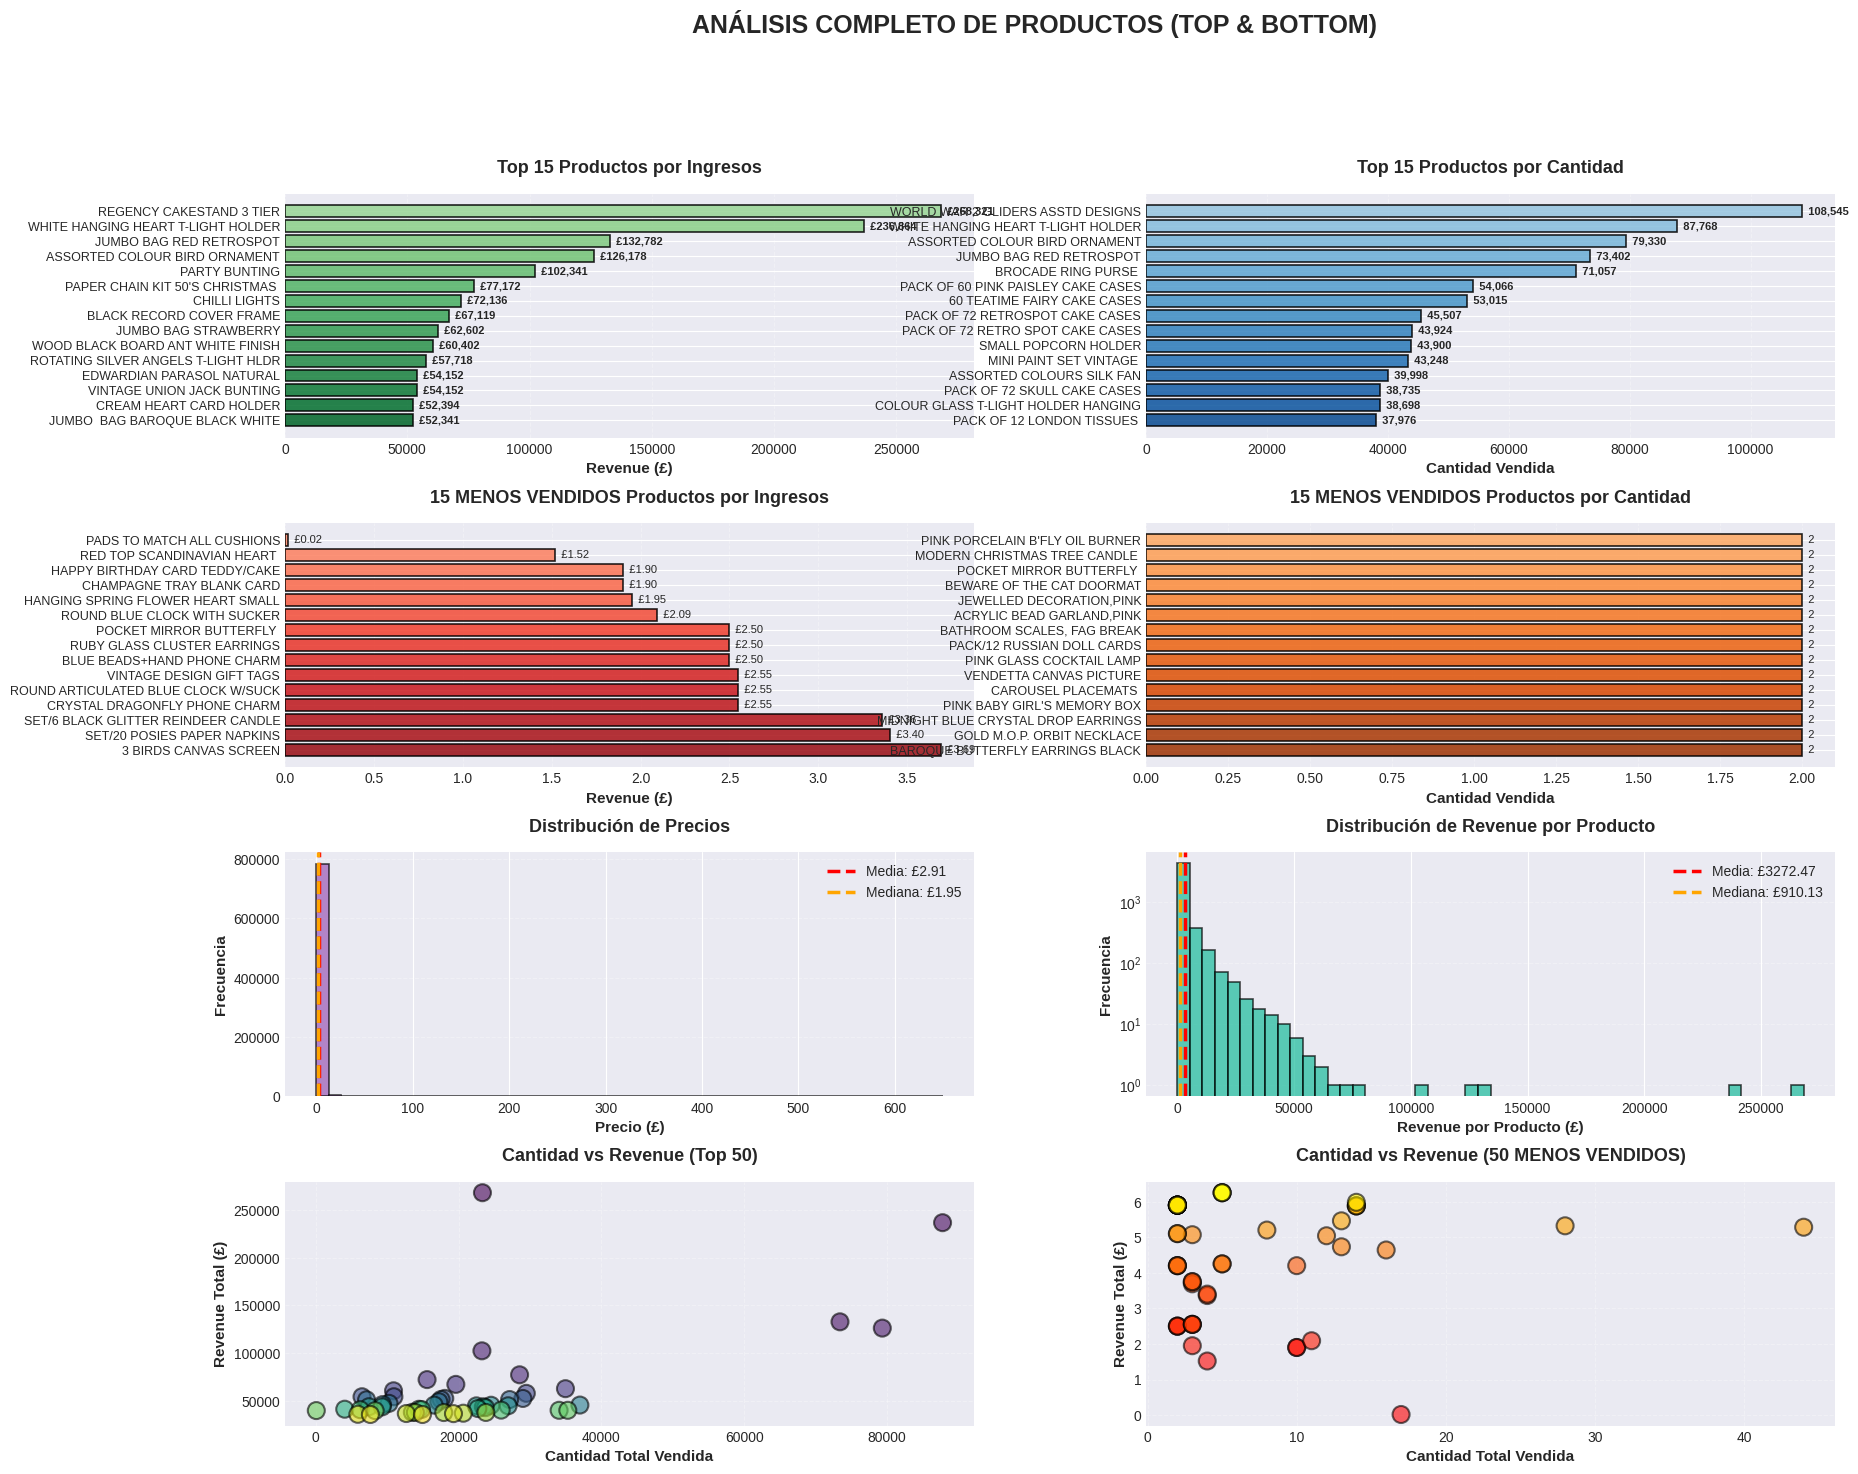


INSIGHTS DE PRODUCTOS

 CONCENTRACIÓN DE INGRESOS:
   • Producto #1: INFLATABLE POLITICAL GLOBE 
     └─ Revenue: £5,148.62
     └─ Cantidad: 6,390 unidades
   • Top 10 generan: £1,205,919.38 (7.2% del total)
   • Top 20 generan: 10.4% del total

 PRODUCTOS DE BAJO RENDIMIENTO:
   • 424 productos con revenue < £50
   • 200 productos con < 10 unidades vendidas
   • Producto menos rentable: PADS TO MATCH ALL CUSHIONS
     └─ Revenue: £0.02

 ESTADÍSTICAS GENERALES:
   • Revenue promedio por producto: £3,272.47
   • Revenue mediana por producto: £910.13
   • Precio promedio: £2.91
   • Precio mediano: £1.95

RECOMENDACIONES:

   1. POTENCIAR TOP PERFORMERS:
      • Asegurar stock suficiente de los top 10 productos
      • Crear bundles con productos complementarios
      • Marketing enfocado en estos productos estrella
   
   2. REVISAR PRODUCTOS DE BAJO RENDIMIENTO:
      • Considerar descontinuar productos con < 5 ventas/año
      • Evaluar reducción de stock en productos de baja rotac

In [ ]:
# ----------------------------------------------------------------------------
# 12. ANÁLISIS DE PRODUCTOS (COMPLETO)
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("11. ANÁLISIS DE PRODUCTOS")
print("=" * 80)

# Calcular métricas por producto
product_sales = df_sales.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'Invoice': 'nunique'
}).reset_index()
product_sales.columns = ['StockCode', 'Description', 'TotalQuantity', 'Revenue', 'Transactions']

# Calcular precio promedio
product_sales['AvgPrice'] = product_sales['Revenue'] / product_sales['TotalQuantity']

# Filtrar productos con al menos 2 transacciones (para evitar one-offs raros)
product_sales_filtered = product_sales[product_sales['Transactions'] >= 2].copy()

print(f"\n Total de productos únicos: {len(product_sales):,}")
print(f"   └─ Con al menos 2 transacciones: {len(product_sales_filtered):,}")

# ===========================================================================
# TOP PRODUCTOS (MÁS VENDIDOS)
# ===========================================================================

print("\n" + "="*80)
print("TOP PRODUCTOS MÁS VENDIDOS")
print("="*80)

# Por revenue
top_revenue = product_sales_filtered.nlargest(10, 'Revenue')
print("\n TOP 10 por REVENUE:")
display(top_revenue[['Description', 'TotalQuantity', 'Revenue', 'Transactions', 'AvgPrice']])

# Por cantidad
top_quantity = product_sales_filtered.nlargest(10, 'TotalQuantity')
print("\n TOP 10 por CANTIDAD:")
display(top_quantity[['Description', 'TotalQuantity', 'Revenue', 'Transactions', 'AvgPrice']])

# ===========================================================================
# BOTTOM PRODUCTOS (MENOS VENDIDOS)
# ===========================================================================

print("\n" + "="*80)
print("PRODUCTOS MENOS VENDIDOS")
print("="*80)

# Por revenue (los que generan menos ingresos)
bottom_revenue = product_sales_filtered.nsmallest(10, 'Revenue')
print("\n BOTTOM 10 por REVENUE:")
display(bottom_revenue[['Description', 'TotalQuantity', 'Revenue', 'Transactions', 'AvgPrice']])

# Por cantidad (los menos vendidos en unidades)
bottom_quantity = product_sales_filtered.nsmallest(10, 'TotalQuantity')
print("\n BOTTOM 10 por CANTIDAD:")
display(bottom_quantity[['Description', 'TotalQuantity', 'Revenue', 'Transactions', 'AvgPrice']])

# ===========================================================================
# VISUALIZACIONES
# ===========================================================================

fig = plt.figure(figsize=(20, 16))
fig.suptitle('ANÁLISIS COMPLETO DE PRODUCTOS (TOP & BOTTOM)',
             fontsize=18, fontweight='bold', y=0.995)

# Grid layout
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

# ---------------------------------------------------------------------------
# FILA 1: TOP PRODUCTOS
# ---------------------------------------------------------------------------

# 1. Top 15 por Revenue
ax1 = fig.add_subplot(gs[0, 0])
top_15_revenue = product_sales_filtered.nlargest(15, 'Revenue')
colors_top = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_15_revenue)))

ax1.barh(range(len(top_15_revenue)), top_15_revenue['Revenue'].values,
         color=colors_top, edgecolor='black', linewidth=1.2, alpha=0.85)
ax1.set_yticks(range(len(top_15_revenue)))
ax1.set_yticklabels([desc[:35] + '...' if len(desc) > 35 else desc
                      for desc in top_15_revenue['Description']], fontsize=9)
ax1.set_xlabel('Revenue (£)', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Productos por Ingresos',
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()

# Añadir valores
for i, v in enumerate(top_15_revenue['Revenue'].values):
    ax1.text(v, i, f'  £{v:,.0f}', va='center', fontsize=8, fontweight='bold')

# 2. Top 15 por Cantidad
ax2 = fig.add_subplot(gs[0, 1])
top_15_quantity = product_sales_filtered.nlargest(15, 'TotalQuantity')
colors_top_qty = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_quantity)))

ax2.barh(range(len(top_15_quantity)), top_15_quantity['TotalQuantity'].values,
         color=colors_top_qty, edgecolor='black', linewidth=1.2, alpha=0.85)
ax2.set_yticks(range(len(top_15_quantity)))
ax2.set_yticklabels([desc[:35] + '...' if len(desc) > 35 else desc
                      for desc in top_15_quantity['Description']], fontsize=9)
ax2.set_xlabel('Cantidad Vendida', fontsize=11, fontweight='bold')
ax2.set_title('Top 15 Productos por Cantidad',
              fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()

for i, v in enumerate(top_15_quantity['TotalQuantity'].values):
    ax2.text(v, i, f'  {v:,.0f}', va='center', fontsize=8, fontweight='bold')

# ---------------------------------------------------------------------------
# FILA 2: BOTTOM PRODUCTOS
# ---------------------------------------------------------------------------

# 3. Bottom 15 por Revenue
ax3 = fig.add_subplot(gs[1, 0])
bottom_15_revenue = product_sales_filtered.nsmallest(15, 'Revenue').sort_values('Revenue', ascending=True)
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.9, len(bottom_15_revenue)))

ax3.barh(range(len(bottom_15_revenue)), bottom_15_revenue['Revenue'].values,
         color=colors_bottom, edgecolor='black', linewidth=1.2, alpha=0.85)
ax3.set_yticks(range(len(bottom_15_revenue)))
ax3.set_yticklabels([desc[:35] + '...' if len(desc) > 35 else desc
                      for desc in bottom_15_revenue['Description']], fontsize=9)
ax3.set_xlabel('Revenue (£)', fontsize=11, fontweight='bold')
ax3.set_title('15 MENOS VENDIDOS Productos por Ingresos',
              fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--')
ax3.invert_yaxis()

for i, v in enumerate(bottom_15_revenue['Revenue'].values):
    ax3.text(v, i, f'  £{v:,.2f}', va='center', fontsize=8)

# 4. Bottom 15 por Cantidad
ax4 = fig.add_subplot(gs[1, 1])
bottom_15_quantity = product_sales_filtered.nsmallest(15, 'TotalQuantity').sort_values('TotalQuantity', ascending=True)
colors_bottom_qty = plt.cm.Oranges(np.linspace(0.4, 0.9, len(bottom_15_quantity)))

ax4.barh(range(len(bottom_15_quantity)), bottom_15_quantity['TotalQuantity'].values,
         color=colors_bottom_qty, edgecolor='black', linewidth=1.2, alpha=0.85)
ax4.set_yticks(range(len(bottom_15_quantity)))
ax4.set_yticklabels([desc[:35] + '...' if len(desc) > 35 else desc
                      for desc in bottom_15_quantity['Description']], fontsize=9)
ax4.set_xlabel('Cantidad Vendida', fontsize=11, fontweight='bold')
ax4.set_title('15 MENOS VENDIDOS Productos por Cantidad',
              fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')
ax4.invert_yaxis()

for i, v in enumerate(bottom_15_quantity['TotalQuantity'].values):
    ax4.text(v, i, f'  {int(v)}', va='center', fontsize=8)

# ---------------------------------------------------------------------------
# FILA 3: DISTRIBUCIONES
# ---------------------------------------------------------------------------

# 5. Distribución de Precios
ax5 = fig.add_subplot(gs[2, 0])
price_data = df_sales['Price']
ax5.hist(price_data, bins=50, color='#9B59B6', edgecolor='black', alpha=0.7, linewidth=1.2)
ax5.axvline(price_data.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Media: £{price_data.mean():.2f}')
ax5.axvline(price_data.median(), color='orange', linestyle='--', linewidth=2.5, label=f'Mediana: £{price_data.median():.2f}')
ax5.set_xlabel('Precio (£)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
ax5.set_title('Distribución de Precios',
              fontsize=13, fontweight='bold', pad=15)
ax5.legend(fontsize=10)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# 6. Distribución de Revenue por Producto
ax6 = fig.add_subplot(gs[2, 1])
revenue_data = product_sales_filtered['Revenue']
ax6.hist(revenue_data, bins=50, color='#1ABC9C', edgecolor='black', alpha=0.7, linewidth=1.2)
ax6.axvline(revenue_data.mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Media: £{revenue_data.mean():.2f}')
ax6.axvline(revenue_data.median(), color='orange', linestyle='--', linewidth=2.5,
            label=f'Mediana: £{revenue_data.median():.2f}')
ax6.set_xlabel('Revenue por Producto (£)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
ax6.set_title('Distribución de Revenue por Producto',
              fontsize=13, fontweight='bold', pad=15)
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
ax6.set_yscale('log')  # Escala log para mejor visualización

# ---------------------------------------------------------------------------
# FILA 4: SCATTERPLOTS
# ---------------------------------------------------------------------------

# 7. Scatter: Cantidad vs Revenue (Top 50)
ax7 = fig.add_subplot(gs[3, 0])
top_50 = product_sales_filtered.nlargest(50, 'Revenue')
scatter1 = ax7.scatter(top_50['TotalQuantity'], top_50['Revenue'],
                       s=150, alpha=0.6, c=range(len(top_50)),
                       cmap='viridis', edgecolors='black', linewidth=1.5)
ax7.set_xlabel('Cantidad Total Vendida', fontsize=11, fontweight='bold')
ax7.set_ylabel('Revenue Total (£)', fontsize=11, fontweight='bold')
ax7.set_title('Cantidad vs Revenue (Top 50)',
              fontsize=13, fontweight='bold', pad=15)
ax7.grid(True, alpha=0.3, linestyle='--')

# 8. Scatter: Cantidad vs Revenue (Bottom 50)
ax8 = fig.add_subplot(gs[3, 1])
bottom_50 = product_sales_filtered.nsmallest(50, 'Revenue')
scatter2 = ax8.scatter(bottom_50['TotalQuantity'], bottom_50['Revenue'],
                       s=150, alpha=0.6, c=range(len(bottom_50)),
                       cmap='autumn', edgecolors='black', linewidth=1.5)
ax8.set_xlabel('Cantidad Total Vendida', fontsize=11, fontweight='bold')
ax8.set_ylabel('Revenue Total (£)', fontsize=11, fontweight='bold')
ax8.set_title('Cantidad vs Revenue (50 MENOS VENDIDOS)',
              fontsize=13, fontweight='bold', pad=15)
ax8.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ===========================================================================
# INSIGHTS Y RECOMENDACIONES
# ===========================================================================

print("\n" + "="*80)
print("INSIGHTS DE PRODUCTOS")
print("="*80)

# Concentración de ingresos
top10_revenue = product_sales_filtered.nlargest(10, 'Revenue')['Revenue'].sum()
total_revenue = product_sales_filtered['Revenue'].sum()
concentration_pct = (top10_revenue / total_revenue) * 100

print(f"\n CONCENTRACIÓN DE INGRESOS:")
print(f"   • Producto #1: {product_sales_filtered.iloc[0]['Description']}")
print(f"     └─ Revenue: £{product_sales_filtered.iloc[0]['Revenue']:,.2f}")
print(f"     └─ Cantidad: {product_sales_filtered.iloc[0]['TotalQuantity']:,.0f} unidades")
print(f"   • Top 10 generan: £{top10_revenue:,.2f} ({concentration_pct:.1f}% del total)")
print(f"   • Top 20 generan: {(product_sales_filtered.nlargest(20, 'Revenue')['Revenue'].sum() / total_revenue * 100):.1f}% del total")

print(f"\n PRODUCTOS DE BAJO RENDIMIENTO:")
print(f"   • {len(product_sales_filtered[product_sales_filtered['Revenue'] < 50]):,} productos con revenue < £50")
print(f"   • {len(product_sales_filtered[product_sales_filtered['TotalQuantity'] < 10]):,} productos con < 10 unidades vendidas")
print(f"   • Producto menos rentable: {bottom_revenue.iloc[0]['Description']}")
print(f"     └─ Revenue: £{bottom_revenue.iloc[0]['Revenue']:.2f}")

print(f"\n ESTADÍSTICAS GENERALES:")
print(f"   • Revenue promedio por producto: £{product_sales_filtered['Revenue'].mean():,.2f}")
print(f"   • Revenue mediana por producto: £{product_sales_filtered['Revenue'].median():,.2f}")
print(f"   • Precio promedio: £{df_sales['Price'].mean():.2f}")
print(f"   • Precio mediano: £{df_sales['Price'].median():.2f}")

print("\n" + "="*80)
print("RECOMENDACIONES:")
print("="*80)
print("""
   1. POTENCIAR TOP PERFORMERS:
      • Asegurar stock suficiente de los top 10 productos
      • Crear bundles con productos complementarios
      • Marketing enfocado en estos productos estrella

   2. REVISAR PRODUCTOS DE BAJO RENDIMIENTO:
      • Considerar descontinuar productos con < 5 ventas/año
      • Evaluar reducción de stock en productos de baja rotación
      • Analizar si el precio es competitivo

   3. OPTIMIZACIÓN DE PRECIOS:
      • Productos con alto volumen pero bajo revenue → subir precio
      • Productos con bajo volumen pero alto precio → promociones

   4. GESTIÓN DE INVENTARIO:
      • Priorizar reposición de productos top 20
      • Liquidar stock de productos bottom 10 por revenue
""")

print("="*80)

##**13. Análisis de clientes**

Buscamos segmentar e identificacar los clientes más valiosos y rentables para la tienda.

1. Creación de Métricas Clave por Cliente
Se agrupan los datos por Customer ID para calcular las métricas y la fecha de la última compra.
*   Frequency:	Número de facturas únicas por cliente. Indica qué tan frecuentemente compra el cliente.
*   Monetary:	Suma total de dinero gastado por el cliente. Indica el valor del cliente.
*   Recency:	Calculado como la diferencia en días entre la fecha máxima de compra en el dataset y la LastPurchase del cliente. Mide qué tan recientemente compró.
*   AvgTicket:	El gasto promedio por transacción

2. Estadísticas Descriptivas del Cliente: Se muestran las estadísticas clave para entender el perfil del cliente promedio.

3. Segmentación por Gasto (Monetary)
Dividimos a los clientes en cuatro cuartiles (Bronce, Plata, Oro, Platino) según su gasto total , lo que facilita la identificación de los segmentos de mayor valor.

4. Análisis de Retención y Top Clientes
Se cuantifica el número de clientes únicos y recurrentes y se identifican a los clientes más rentables. Con retención medimos la lealtad.




12. ANÁLISIS DE COMPORTAMIENTO DE CLIENTES

 Estadísticas de clientes:
   - Total de clientes: 5,834
   - Gasto promedio por cliente: £2,857.46
   - Mediana de gasto: £871.77
   - Frecuencia promedio: 6.19 compras
   - Mediana de frecuencia: 3 compras
   - Ticket promedio: £369.74

 Segmentación de clientes por gasto:


Customer ID Monetary             Frequency Recency
              count     mean         sum      mean    mean
Segment                                                   
Bronce         1459   193.17   281841.83      1.30  340.80
Plata          1458   568.73   829205.03      2.45  233.33
Oro            1458  1406.37  2050482.67      4.73  152.44
Platino        1459  9259.00 13508880.81     16.29   71.10


 TOP 10 CLIENTES MÁS RENTABLES:


,Customer ID,Monetary,Frequency,AvgTicket,Recency
5649,18102,606963.25,145,4185.95,0
2252,14646,516823.88,144,3589.05,1
1770,14156,295264.05,142,2079.32,9
2509,14911,244649.40,364,672.11,0
5010,17450,235864.75,49,4813.57,7
1314,13694,192076.97,139,1381.85,3
5069,17511,164863.55,59,2794.30,2
67,12415,143214.52,23,6226.72,23
4258,16684,140207.03,52,2696.29,3
2656,15061,136815.19,125,1094.52,3


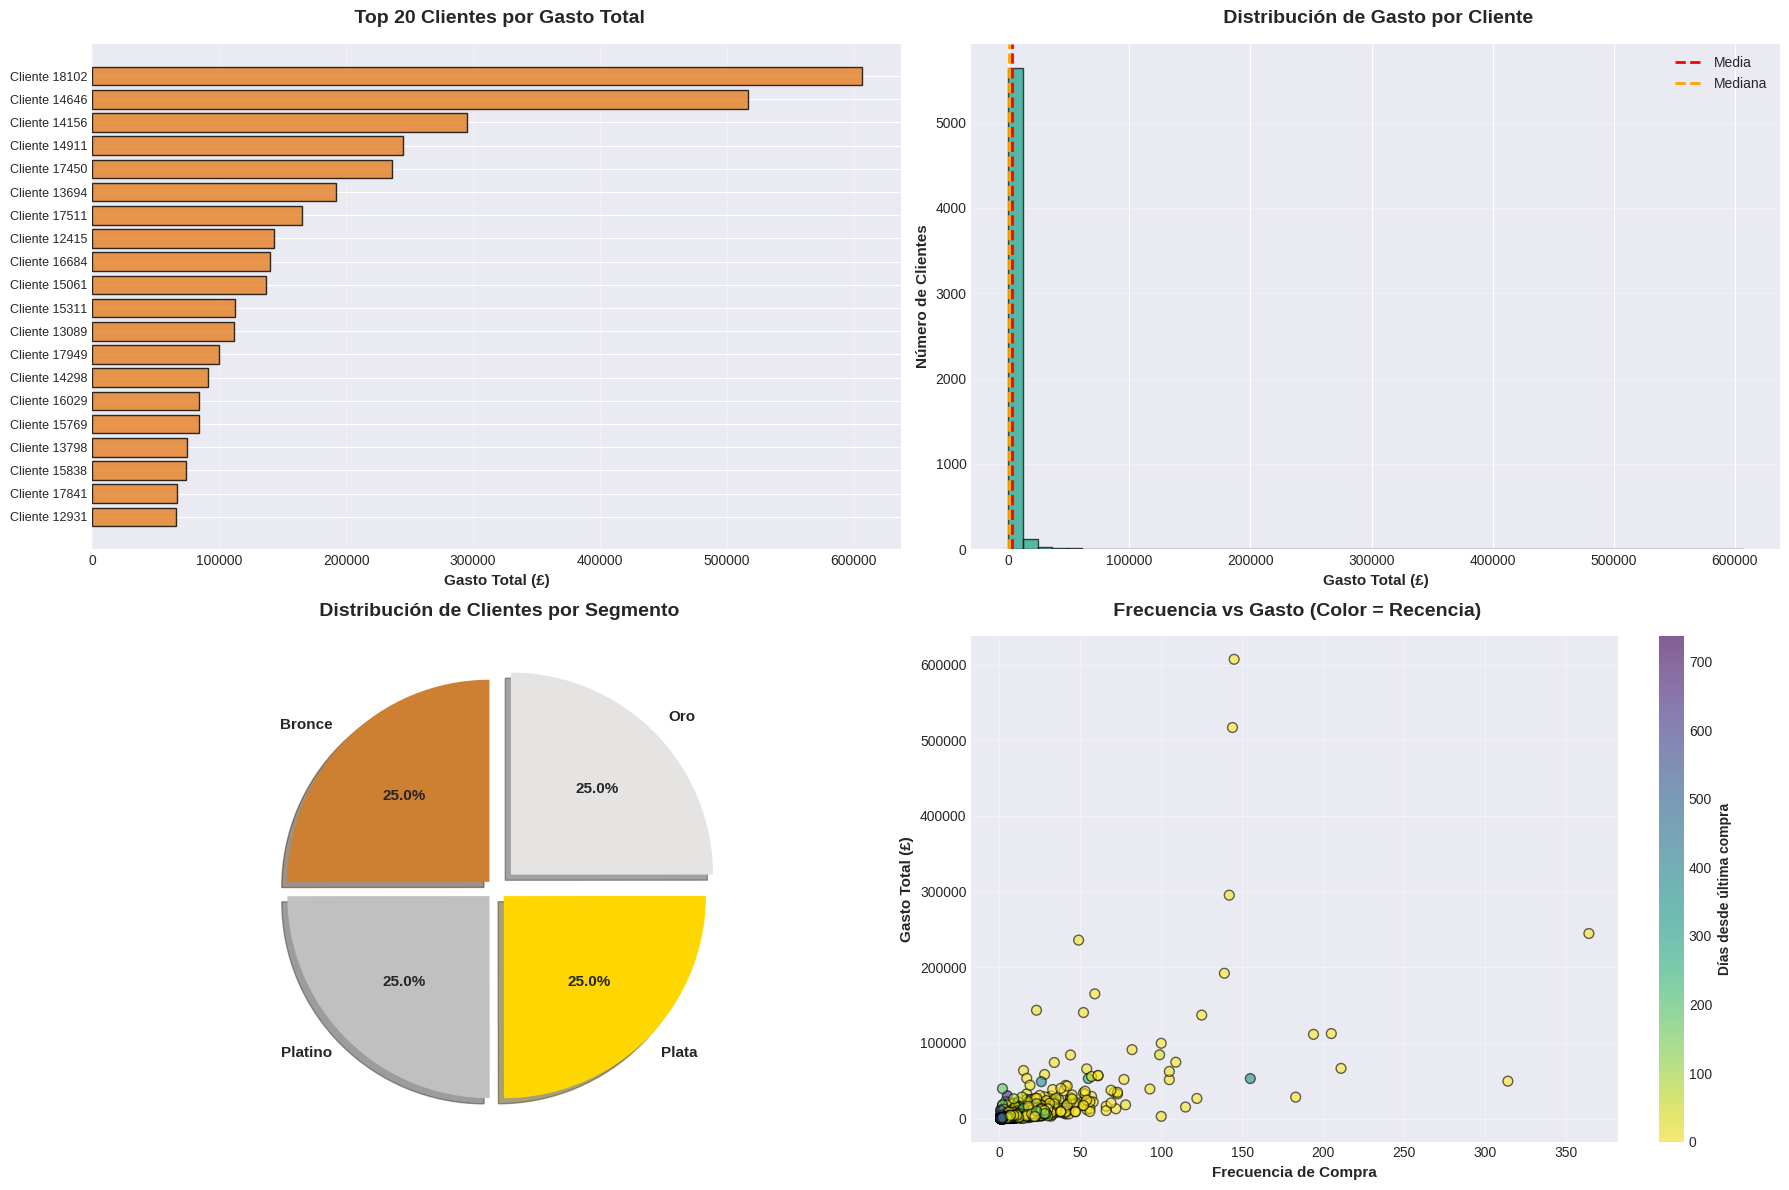


 ANÁLISIS DE RETENCIÓN:
   - Clientes con 1 sola compra: 1,613 (27.6%)
   - Clientes recurrentes (>1 compra): 4,221 (72.4%)
   - Clientes VIP (>10 compras): 849 (14.6%)


In [ ]:
# ----------------------------------------------------------------------------
# 13. ANÁLISIS DE CLIENTES
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("12. ANÁLISIS DE COMPORTAMIENTO DE CLIENTES")
print("=" * 80)

# Métricas por cliente
customer_metrics = df_sales.groupby('Customer ID').agg({
    'Invoice': 'nunique',           # Frecuencia
    'TotalPrice': 'sum',            # Monetary
    'InvoiceDate': 'max'            # Para Recency
}).reset_index()
customer_metrics.columns = ['Customer ID', 'Frequency', 'Monetary', 'LastPurchase']

# Calcular Recency (días desde última compra)
max_date = df_sales['InvoiceDate'].max()
customer_metrics['Recency'] = (max_date - customer_metrics['LastPurchase']).dt.days

# Ticket promedio por cliente
customer_metrics['AvgTicket'] = customer_metrics['Monetary'] / customer_metrics['Frequency']

print("\n Estadísticas de clientes:")
print(f"   - Total de clientes: {len(customer_metrics):,}")
print(f"   - Gasto promedio por cliente: £{customer_metrics['Monetary'].mean():,.2f}")
print(f"   - Mediana de gasto: £{customer_metrics['Monetary'].median():,.2f}")
print(f"   - Frecuencia promedio: {customer_metrics['Frequency'].mean():.2f} compras")
print(f"   - Mediana de frecuencia: {customer_metrics['Frequency'].median():.0f} compras")
print(f"   - Ticket promedio: £{customer_metrics['AvgTicket'].mean():,.2f}")

# Segmentación de clientes por gasto
customer_metrics['Segment'] = pd.qcut(customer_metrics['Monetary'],
                                       q=4,
                                       labels=['Bronce', 'Plata', 'Oro', 'Platino'],
                                       duplicates='drop')

print("\n Segmentación de clientes por gasto:")
segment_analysis = customer_metrics.groupby('Segment', observed=True).agg({
    'Customer ID': 'count',
    'Monetary': ['mean', 'sum'],
    'Frequency': 'mean',
    'Recency': 'mean'
}).round(2)
display(segment_analysis)

# Top 10 clientes
top_customers = customer_metrics.nlargest(10, 'Monetary')
print("\n TOP 10 CLIENTES MÁS RENTABLES:")
display(top_customers[['Customer ID', 'Monetary', 'Frequency', 'AvgTicket', 'Recency']])

# Visualización de clientes
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 20 clientes por gasto
top_20_customers = customer_metrics.nlargest(20, 'Monetary')
axes[0, 0].barh(range(len(top_20_customers)), top_20_customers['Monetary'].values,
                color='#E67E22', edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(range(len(top_20_customers)))
axes[0, 0].set_yticklabels([f"Cliente {int(cid)}" for cid in top_20_customers['Customer ID']],
                           fontsize=9)
axes[0, 0].set_xlabel('Gasto Total (£)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(' Top 20 Clientes por Gasto Total',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# 2. Distribución de gasto por cliente
axes[0, 1].hist(customer_metrics['Monetary'], bins=50,
                color='#16A085', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(customer_metrics['Monetary'].mean(),
                   color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 1].axvline(customer_metrics['Monetary'].median(),
                   color='orange', linestyle='--', linewidth=2, label='Mediana')
axes[0, 1].set_xlabel('Gasto Total (£)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Número de Clientes', fontsize=11, fontweight='bold')
axes[0, 1].set_title(' Distribución de Gasto por Cliente',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Segmentación de clientes (pie chart)
segment_counts = customer_metrics['Segment'].value_counts()
colors_segment = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']
explode = (0.05, 0.05, 0.05, 0.1)
axes[1, 0].pie(segment_counts.values, labels=segment_counts.index,
               autopct='%1.1f%%', startangle=90, colors=colors_segment,
               explode=explode, shadow=True,
               textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1, 0].set_title(' Distribución de Clientes por Segmento',
                     fontsize=14, fontweight='bold', pad=15)

# 4. Frecuencia vs Monetary (scatter con color por Recency)
scatter = axes[1, 1].scatter(customer_metrics['Frequency'],
                            customer_metrics['Monetary'],
                            c=customer_metrics['Recency'],
                            cmap='viridis_r', alpha=0.6, s=50, edgecolors='black')
axes[1, 1].set_xlabel('Frecuencia de Compra', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Gasto Total (£)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(' Frecuencia vs Gasto (Color = Recencia)',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Días desde última compra', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de retención
print("\n ANÁLISIS DE RETENCIÓN:")
one_time = (customer_metrics['Frequency'] == 1).sum()
recurring = (customer_metrics['Frequency'] > 1).sum()
vip = (customer_metrics['Frequency'] > 10).sum()

print(f"   - Clientes con 1 sola compra: {one_time:,} ({one_time/len(customer_metrics)*100:.1f}%)")
print(f"   - Clientes recurrentes (>1 compra): {recurring:,} ({recurring/len(customer_metrics)*100:.1f}%)")
print(f"   - Clientes VIP (>10 compras): {vip:,} ({vip/len(customer_metrics)*100:.1f}%)")

##**14. Análisis Geográfico**
Evaluamos la distribución de los ingresos por país para identificar los mercados clave, la dependencia del mercado local y el potencial de las ventas internacionales.




14. ANÁLISIS GEOGRÁFICO DE VENTAS

 TOP 15 PAÍSES POR INGRESOS:


,Country,Revenue,Transactions,Customers,Units,Revenue%,AvgTicket
38,United Kingdom,13967837.95,32965,5321,8329031,83.79,423.72
10,EIRE,551304.11,517,3,302413,3.31,1066.35
24,Netherlands,539904.32,215,22,376614,3.24,2511.18
14,Germany,383726.85,748,107,223650,2.30,513.00
13,France,298179.80,584,94,181764,1.79,510.58
0,Australia,167037.85,83,15,103459,1.00,2012.50
34,Switzerland,92311.33,77,22,51558,0.55,1198.85
33,Sweden,82458.54,95,19,87140,0.49,867.98
32,Spain,81660.71,139,37,42645,0.49,587.49
9,Denmark,64514.89,42,12,235051,0.39,1536.07



 INSIGHTS GEOGRÁFICOS:
   - Reino Unido: £13,967,837.95 (83.8%)
   - Top 5 países: 94.4% del revenue total
   - Países atendidos: 41
   - Países con >1% revenue: 5


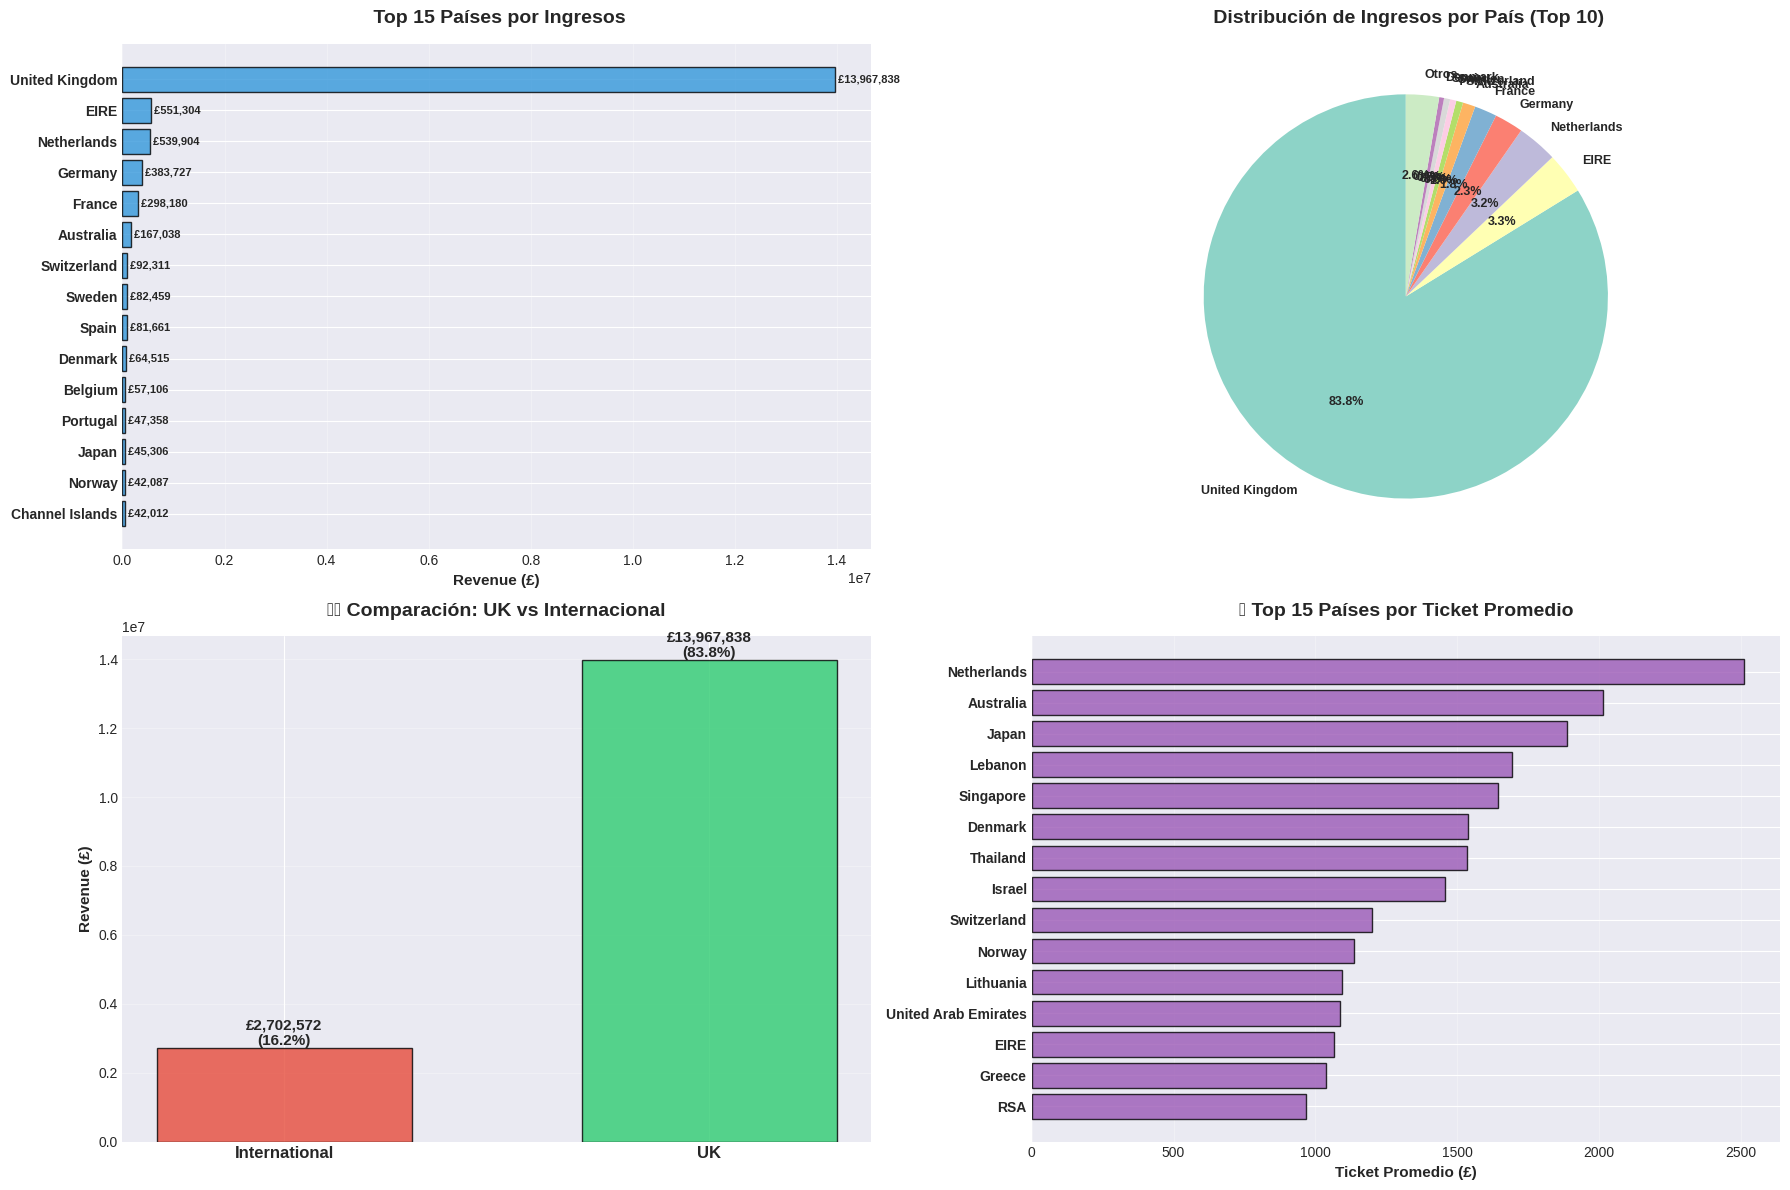


 PRODUCTO MÁS VENDIDO POR PAÍS (Top 5 países):
   - United Kingdom: REGENCY CAKESTAND 3 TIER (£220,377.10)
   - EIRE: REGENCY CAKESTAND 3 TIER (£11,647.50)
   - Netherlands: ROUND SNACK BOXES SET OF4 WOODLAND  (£13,315.10)
   - Germany: REGENCY CAKESTAND 3 TIER (£13,383.15)
   - France: RABBIT NIGHT LIGHT (£7,234.24)


In [ ]:
# ----------------------------------------------------------------------------
# 14. ANÁLISIS GEOGRÁFICO
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("14. ANÁLISIS GEOGRÁFICO DE VENTAS")
print("=" * 80)

# Ventas por país
country_sales = df_sales.groupby('Country').agg({
    'TotalPrice': 'sum',
    'Invoice': 'nunique',
    'Customer ID': 'nunique',
    'Quantity': 'sum'
}).reset_index()
country_sales.columns = ['Country', 'Revenue', 'Transactions', 'Customers', 'Units']
country_sales = country_sales.sort_values('Revenue', ascending=False)

# Calcular porcentajes
country_sales['Revenue%'] = (country_sales['Revenue'] / country_sales['Revenue'].sum() * 100).round(2)
country_sales['AvgTicket'] = (country_sales['Revenue'] / country_sales['Transactions']).round(2)

print("\n TOP 15 PAÍSES POR INGRESOS:")
display(country_sales.head(15))

print(f"\n INSIGHTS GEOGRÁFICOS:")
print(f"   - Reino Unido: £{country_sales.iloc[0]['Revenue']:,.2f} ({country_sales.iloc[0]['Revenue%']:.1f}%)")
print(f"   - Top 5 países: {country_sales.head(5)['Revenue%'].sum():.1f}% del revenue total")
print(f"   - Países atendidos: {len(country_sales)}")
print(f"   - Países con >1% revenue: {(country_sales['Revenue%'] > 1).sum()}")

# Visualización geográfica
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 15 países por revenue
top_15_countries = country_sales.head(15)
axes[0, 0].barh(range(len(top_15_countries)), top_15_countries['Revenue'].values,
                color='#3498DB', edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(range(len(top_15_countries)))
axes[0, 0].set_yticklabels(top_15_countries['Country'], fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Revenue (£)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(' Top 15 Países por Ingresos',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

for i, v in enumerate(top_15_countries['Revenue'].values):
    axes[0, 0].text(v, i, f' £{v:,.0f}', va='center', fontsize=8, fontweight='bold')

# 2. Distribución porcentual (pie chart top 10 + otros)
top_10_countries = country_sales.head(10).copy()
otros_revenue = country_sales.iloc[10:]['Revenue'].sum()
otros_row = pd.DataFrame({'Country': ['Otros'], 'Revenue': [otros_revenue]})
pie_data = pd.concat([top_10_countries[['Country', 'Revenue']], otros_row], ignore_index=True)

colors_countries = plt.cm.Set3(range(len(pie_data)))
axes[0, 1].pie(pie_data['Revenue'], labels=pie_data['Country'],
               autopct='%1.1f%%', startangle=90, colors=colors_countries,
               textprops={'fontsize': 9, 'fontweight': 'bold'})
axes[0, 1].set_title(' Distribución de Ingresos por País (Top 10)',
                     fontsize=14, fontweight='bold', pad=15)

# 3. UK vs Internacional
uk_international = df_sales.groupby('IsUK')['TotalPrice'].sum()
colors_uk = ['#E74C3C', '#2ECC71']
bars = axes[1, 0].bar(range(len(uk_international)), uk_international.values,
                      color=colors_uk, edgecolor='black', alpha=0.8, width=0.6)
axes[1, 0].set_xticks(range(len(uk_international)))
axes[1, 0].set_xticklabels(uk_international.index, fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Revenue (£)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('🇬🇧 Comparación: UK vs Internacional',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, (bar, v) in enumerate(zip(bars, uk_international.values)):
    pct = v / uk_international.sum() * 100
    axes[1, 0].text(i, v, f'£{v:,.0f}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Ticket promedio por país (top 15)
top_15_ticket = country_sales.nlargest(15, 'AvgTicket')
axes[1, 1].barh(range(len(top_15_ticket)), top_15_ticket['AvgTicket'].values,
                color='#9B59B6', edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(range(len(top_15_ticket)))
axes[1, 1].set_yticklabels(top_15_ticket['Country'], fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Ticket Promedio (£)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('💳 Top 15 Países por Ticket Promedio',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Productos más vendidos por país (top 5 países)
print("\n PRODUCTO MÁS VENDIDO POR PAÍS (Top 5 países):")
top_5_countries_list = country_sales.head(5)['Country'].tolist()

for country in top_5_countries_list:
    country_data = df_sales[df_sales['Country'] == country]
    top_product = country_data.groupby('Description')['TotalPrice'].sum().nlargest(1)
    print(f"   - {country}: {top_product.index[0]} (£{top_product.values[0]:,.2f})")


##**15. Análisis devoluciones**
Vamos cuantificar las pérdidas, identificar productos de riesgo y evaluar la eficiencia de las operaciones por geografía.


1. Resumen y Tasa de Impacto:Se cuantifica el impacto total de las devoluciones en el negocio.
2. Productos y Geografía Más Afectados: Se identifican los artículos y países que contribuyen más a las pérdidas por devoluciones.
3. Visualización de Riesgo y Eficiencia: se enfocan en comparar la popularidad de un producto con su tendencia a ser devuelto, identificando productos con altas tasas de devolución.






15. ANÁLISIS DETALLADO DE DEVOLUCIONES

 Resumen de devoluciones:
   - Total registros de devolución: 11,330
   - Revenue perdido: £181,868.68
   - Tasa de devolución: 1.41%

 TOP 10 PRODUCTOS MÁS DEVUELTOS:


,Description,Quantity
0,ROTATING SILVER ANGELS T-LIGHT HLDR,18742
1,Discount,2876
2,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2400
3,TEA TIME PARTY BUNTING,1372
4,WORLD WAR 2 GLIDERS ASSTD DESIGNS,1128
5,SMALL GLASS HEART TRINKET POT,921
6,COLOUR GLASS. STAR T-LIGHT HOLDER,894
7,WHITE CHERRY LIGHTS,850
8,LARGE CIRCULAR MIRROR MOBILE,753
9,BROCADE RING PURSE,704



 TOP 10 PAÍSES CON MÁS DEVOLUCIONES:


,Units Returned,Revenue Lost
Country,,
United Kingdom,76261,164475.89
Germany,1813,5201.89
EIRE,657,2387.44
France,1135,2208.23
Netherlands,166,2174.17
Japan,968,2164.33
Italy,119,847.21
Switzerland,101,355.95
Channel Islands,33,248.34


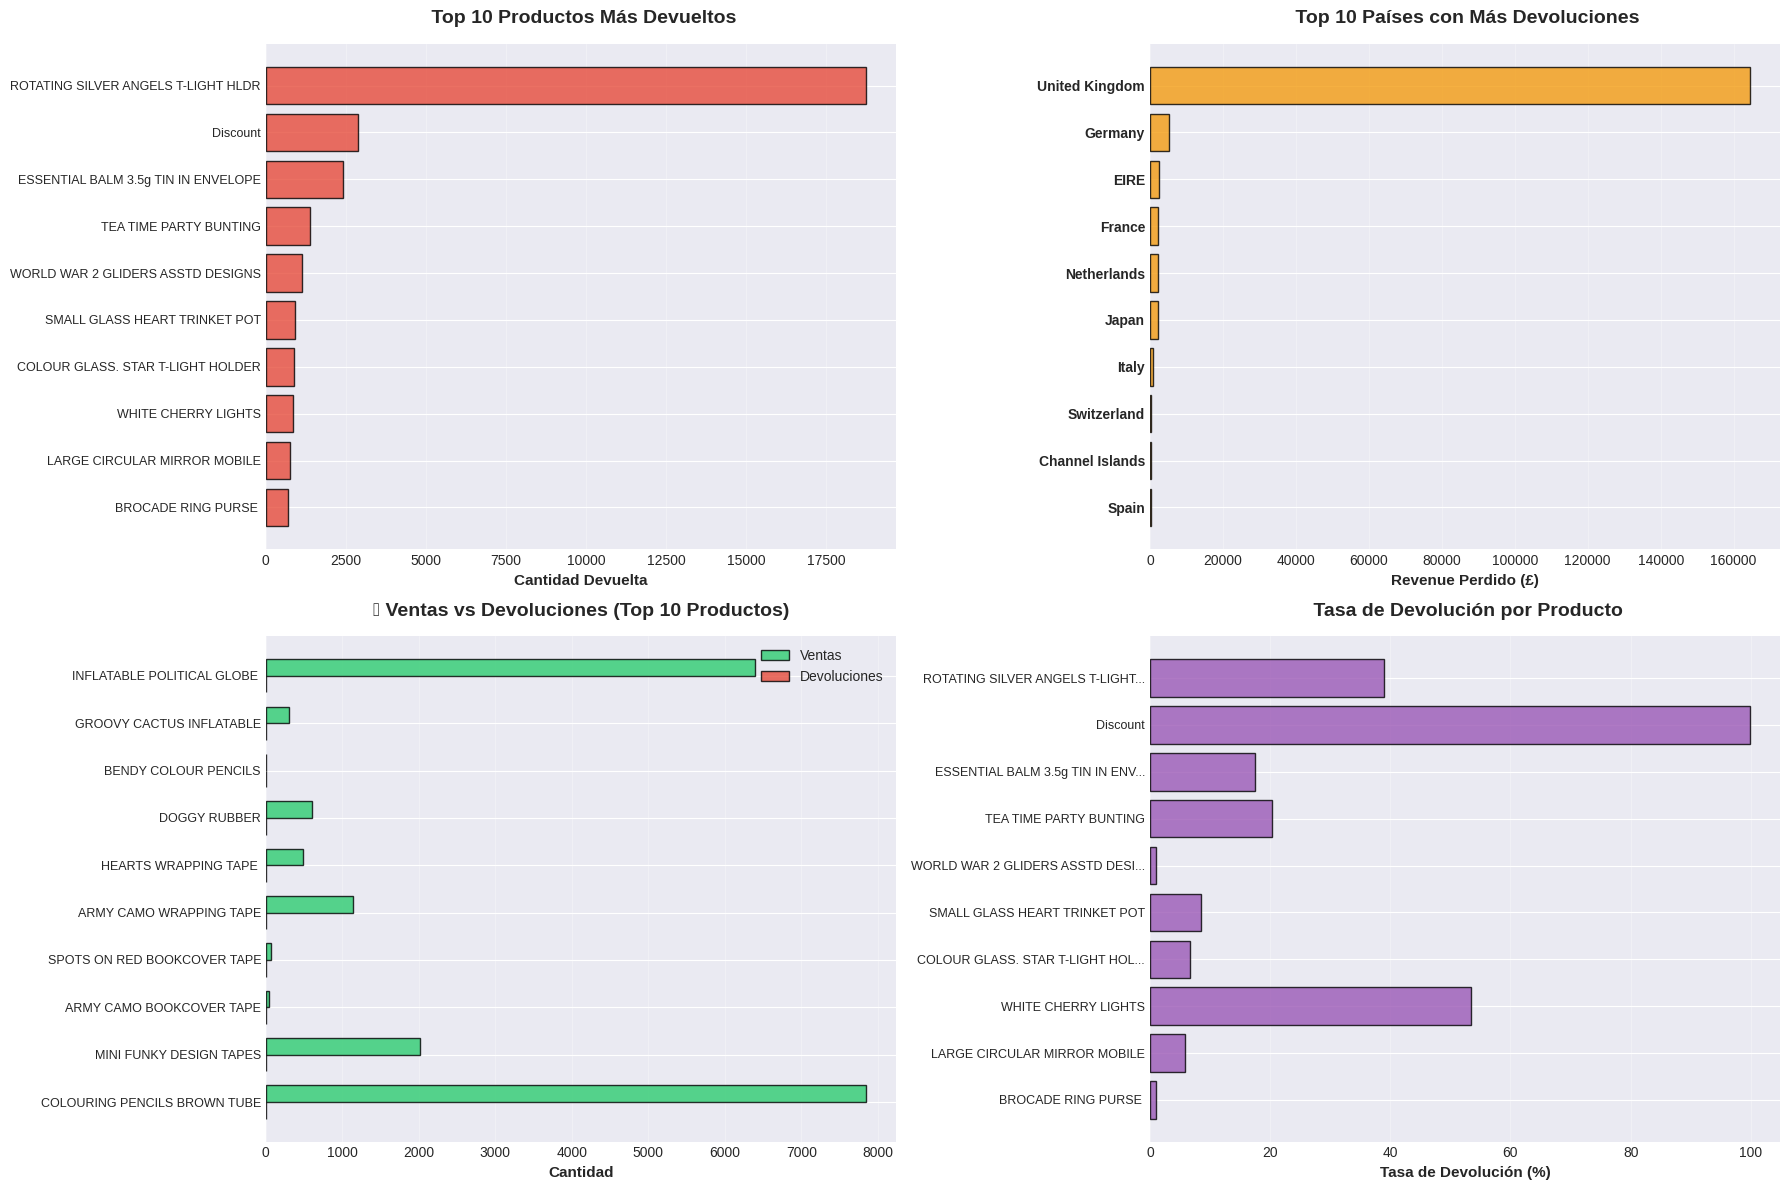


 TOP 10 CLIENTES QUE MÁS DEVUELVEN:


,Customer ID,TotalPrice
0,14096.00,7933.43
1,12931.00,7388.73
2,15749.00,3315.00
3,13694.00,3080.37
4,15369.00,2904.83
5,17949.00,2716.30
6,17389.00,2575.25
7,16013.00,2360.87
8,14646.00,2165.67
9,17940.00,1987.86


In [ ]:
# ----------------------------------------------------------------------------
# 15. ANÁLISIS DE DEVOLUCIONES
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("15. ANÁLISIS DETALLADO DE DEVOLUCIONES")
print("=" * 80)

print(f"\n Resumen de devoluciones:")
print(f"   - Total registros de devolución: {len(df_returns):,}")
print(f"   - Revenue perdido: £{abs(df_returns['TotalPrice'].sum()):,.2f}")
print(f"   - Tasa de devolución: {len(df_returns)/(len(df_sales)+len(df_returns))*100:.2f}%")

# Productos más devueltos
returns_by_product = df_returns.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False)
top_10_returns = returns_by_product.head(10)
print("\n TOP 10 PRODUCTOS MÁS DEVUELTOS:")
display(top_10_returns.reset_index())

# Devoluciones por país
returns_by_country = df_returns.groupby('Country').agg({
    'Quantity': lambda x: abs(x.sum()),
    'TotalPrice': lambda x: abs(x.sum())
}).sort_values('TotalPrice', ascending=False).head(10)
returns_by_country.columns = ['Units Returned', 'Revenue Lost']

print("\n TOP 10 PAÍSES CON MÁS DEVOLUCIONES:")
display(returns_by_country)

# Visualización de devoluciones
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 10 productos más devueltos
axes[0, 0].barh(range(len(top_10_returns)), top_10_returns.values,
                color='#E74C3C', edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(range(len(top_10_returns)))
axes[0, 0].set_yticklabels([desc[:35] + '...' if len(desc) > 35 else desc
                             for desc in top_10_returns.index], fontsize=9)
axes[0, 0].set_xlabel('Cantidad Devuelta', fontsize=11, fontweight='bold')
axes[0, 0].set_title(' Top 10 Productos Más Devueltos',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# 2. Devoluciones por país
axes[0, 1].barh(range(len(returns_by_country)), returns_by_country['Revenue Lost'].values,
                color='#F39C12', edgecolor='black', alpha=0.8)
axes[0, 1].set_yticks(range(len(returns_by_country)))
axes[0, 1].set_yticklabels(returns_by_country.index, fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Revenue Perdido (£)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(' Top 10 Países con Más Devoluciones',
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Comparación ventas vs devoluciones (top productos)
top_products_comparison = product_sales.head(10).copy()
top_products_names = top_products_comparison['Description'].tolist()

ventas_amounts = []
devoluciones_amounts = []

for product in top_products_names:
    ventas = df_sales[df_sales['Description'] == product]['Quantity'].sum()
    devolucion = abs(df_returns[df_returns['Description'] == product]['Quantity'].sum())
    ventas_amounts.append(ventas)
    devoluciones_amounts.append(devolucion)

x = np.arange(len(top_products_names))
width = 0.35

axes[1, 0].barh(x - width/2, ventas_amounts, width, label='Ventas',
                color='#2ECC71', edgecolor='black', alpha=0.8)
axes[1, 0].barh(x + width/2, devoluciones_amounts, width, label='Devoluciones',
                color='#E74C3C', edgecolor='black', alpha=0.8)
axes[1, 0].set_yticks(x)
axes[1, 0].set_yticklabels([p[:30] + '...' if len(p) > 30 else p
                             for p in top_products_names], fontsize=9)
axes[1, 0].set_xlabel('Cantidad', fontsize=11, fontweight='bold')
axes[1, 0].set_title('📊 Ventas vs Devoluciones (Top 10 Productos)',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# 4. Tasa de devolución por producto (top 10 con más devoluciones)
tasas_devolucion = []
productos_tasa = []

for product in top_10_returns.index:
    ventas_prod = df_sales[df_sales['Description'] == product]['Quantity'].sum()
    devol_prod = abs(df_returns[df_returns['Description'] == product]['Quantity'].sum())
    if ventas_prod > 0:
        tasa = (devol_prod / (ventas_prod + devol_prod)) * 100
        tasas_devolucion.append(tasa)
        productos_tasa.append(product)

axes[1, 1].barh(range(len(tasas_devolucion)), tasas_devolucion,
                color='#9B59B6', edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(range(len(tasas_devolucion)))
axes[1, 1].set_yticklabels([p[:30] + '...' if len(p) > 30 else p
                             for p in productos_tasa], fontsize=9)
axes[1, 1].set_xlabel('Tasa de Devolución (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(' Tasa de Devolución por Producto',
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Clientes que más devuelven
if 'Customer ID' in df_returns.columns:
    returns_by_customer = df_returns[df_returns['Customer ID'].notna()].groupby('Customer ID')['TotalPrice'].sum().abs().sort_values(ascending=False).head(10)
    print("\n TOP 10 CLIENTES QUE MÁS DEVUELVEN:")
    display(returns_by_customer.reset_index())

##**16. Ventas por mes y pais**
Con un Mapa de Calor logramos visualizar la distribución de las ventas a lo largo de los meses para los 15 países más importantes. Esto permite detectar rápidamente las tendencias de consumo, estacionalidad y las épocas de mayor y menor actividad en cada mercado.


16. HEATMAP: VENTAS POR PAÍS Y MES


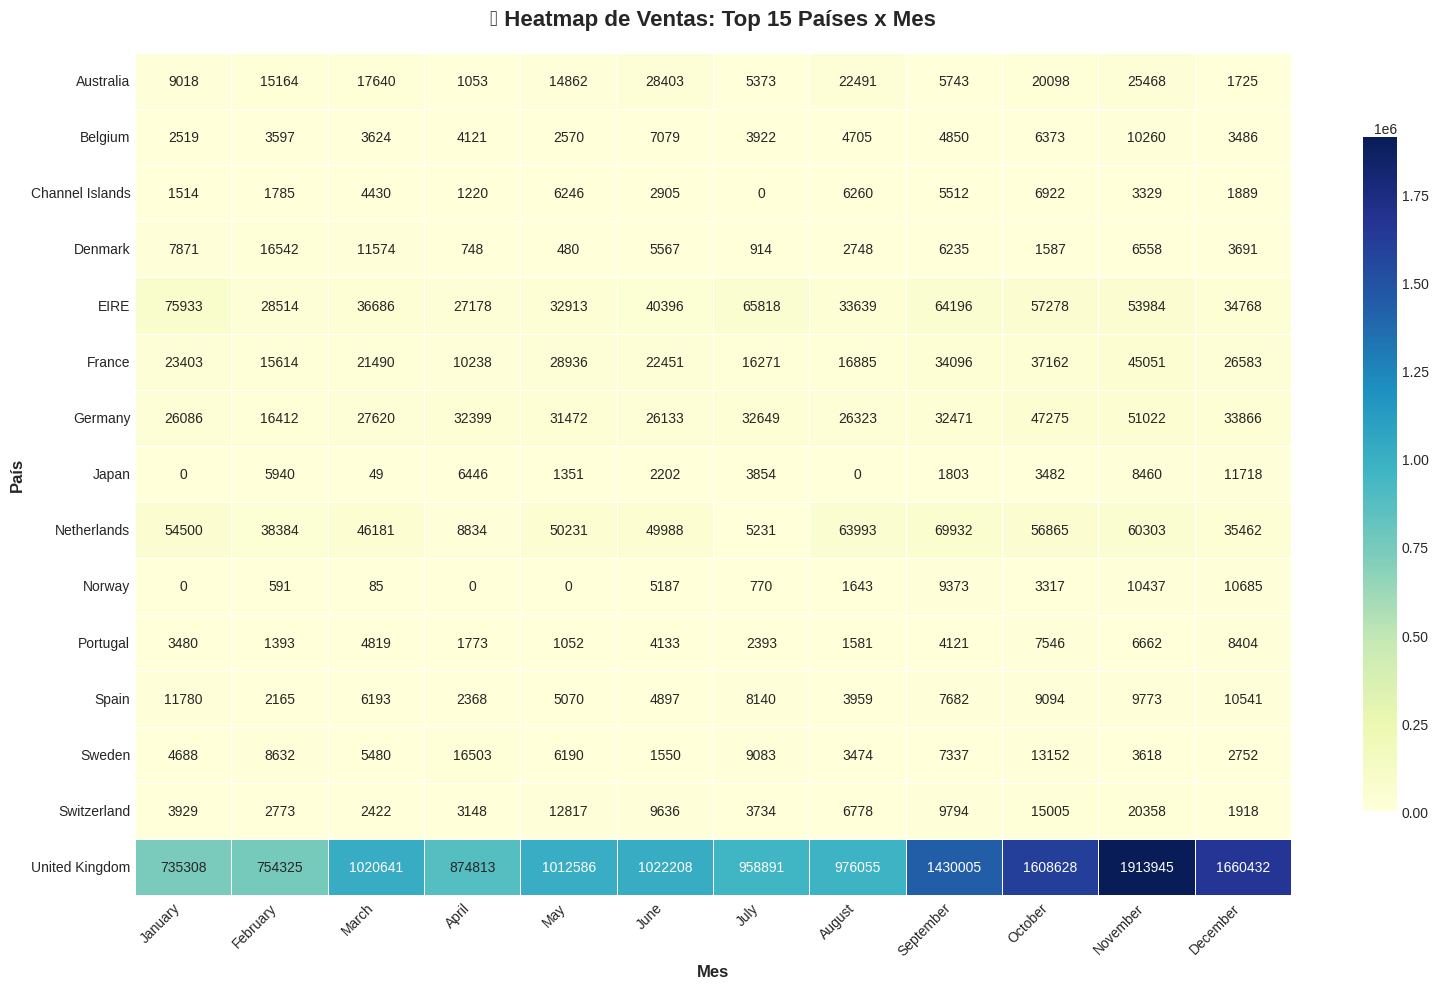

In [ ]:
# ----------------------------------------------------------------------------
# 16. HEATMAP: VENTAS POR PAÍS Y MES
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("16. HEATMAP: VENTAS POR PAÍS Y MES")
print("=" * 80)

# Crear pivot table para top 15 países
top_15_countries_list = country_sales.head(15)['Country'].tolist()
df_top_countries = df_sales[df_sales['Country'].isin(top_15_countries_list)]

meses_orden = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

pivot_country_month = df_top_countries.pivot_table(
    values='TotalPrice',
    index='Country',
    columns='MonthName',
    aggfunc='sum',
    fill_value=0
)

# Reordenar columnas según orden cronológico
pivot_country_month = pivot_country_month.reindex(columns=meses_orden)

# Visualización
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_country_month, cmap="YlGnBu", annot=True, fmt=".0f",
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title(' Heatmap de Ventas: Top 15 Países x Mes',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('País', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## **17. Conclusiones e Insights finales**
Presentar las conclusiones extraídas con el objetivo de potenciar las ventas de la empresa.

In [ ]:
# ----------------------------------------------------------------------------
# 17. CONCLUSIONES E INSIGHTS FINALES
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("17. CONCLUSIONES E INSIGHTS CLAVE PARA EL NEGOCIO")
print("=" * 80)

print("\n" + "=" * 80)
print("RESUMEN ")
print("=" * 80)

# KPIs principales
total_revenue = df_sales['TotalPrice'].sum()
total_customers = df_sales['Customer ID'].nunique()
total_transactions = df_sales['Invoice'].nunique()
avg_ticket = total_revenue / total_transactions
avg_customer_value = total_revenue / total_customers

print(f"\n RENDIMIENTO GENERAL:")
print(f"   - Revenue Total: £{total_revenue:,.2f}")
print(f"   - Transacciones: {total_transactions:,}")
print(f"   - Clientes: {total_customers:,}")
print(f"   - Ticket Promedio: £{avg_ticket:,.2f}")
print(f"   - Valor Promedio del Cliente: £{avg_customer_value:,.2f}")

print(f"\n INSIGHTS CLAVE:")

# 1. Productos
print(f"\n 1. PRODUCTOS:")
top_product = product_sales.iloc[0]
print(f"   ✓ Producto estrella: {top_product['Description']}")
print(f"   ✓ Revenue: £{top_product['Revenue']:,.2f}")
print(f"   ✓ Top 10 productos generan {product_sales.head(10)['Revenue'].sum()/total_revenue*100:.1f}% del revenue")
print(f"    RECOMENDACIÓN: Enfocar marketing en los top productos, asegurar stock")

# 2. Estacionalidad
best_month_data = monthly_sales_sorted.loc[monthly_sales_sorted['TotalPrice'].idxmax()]
q4_sales_value = ventas_por_mes[ventas_por_mes.index.isin(q4_months)].sum()
print(f"\n 2. ESTACIONALIDAD:")
print(f"   ✓ Mes pico: {best_month_data['MonthName']} {int(best_month_data['Year'])} (£{best_month_data['TotalPrice']:,.2f})")
print(f"   ✓ Q4 representa {q4_percentage:.1f}% de ventas anuales")
print(f"    RECOMENDACIÓN: Preparar inventario para Q4, campañas navideñas")

# 3. Clientes
one_time = (customer_metrics['Frequency'] == 1).sum()
recurring = (customer_metrics['Frequency'] > 1).sum()
vip = (customer_metrics['Frequency'] > 10).sum()

print(f"\n 3. CLIENTES:")
# Removing the RFM segments as they were not calculated
# champions_count = (customer_metrics['RFM_Segment'] == 'Champions').sum()
# at_risk_count = (customer_metrics['RFM_Segment'] == 'At Risk').sum()
# hibernating_count = (customer_metrics['RFM_Segment'] == 'Hibernating').sum()

# print(f"   ✓ Champions: {champions_count:,} clientes ({champions_count/total_customers*100:.1f}%)")
# print(f"   ✓ En riesgo: {at_risk_count:,} clientes ({at_risk_count/total_customers*100:.1f}%)")
# print(f"   ✓ Inactivos: {hibernating_count:,} clientes ({hibernating_count/total_customers*100:.1f}%)")

print(f"   ✓ Clientes con 1 sola compra: {one_time:,} ({one_time/total_customers*100:.1f}%)")
print(f"   ✓ Clientes recurrentes (>1 compra): {recurring:,} ({recurring/total_customers*100:.1f}%)")
print(f"   ✓ Clientes VIP (>10 compras): {vip:,} ({vip/total_customers*100:.1f}%)")
print(f"    RECOMENDACIÓN: Programa de lealtad para clientes recurrentes/VIP, estrategias para convertir one-time buyers")


# 4. Geografía
uk_percentage = country_sales.iloc[0]['Revenue%']
international_countries = len(country_sales) - 1
print(f"\n 4. GEOGRAFÍA:")
print(f"   ✓ UK domina con {uk_percentage:.1f}% del revenue")
print(f"   ✓ {international_countries} países internacionales")
print(f"   ✓ Top 5 países: {country_sales.head(5)['Revenue%'].sum():.1f}% del revenue")
print(f"    RECOMENDACIÓN: Expansión internacional gradual, enfoque en top países no-UK")

# 5. Devoluciones
print(f"\n 5. DEVOLUCIONES:")
total_transacciones = len(df_clean)
tasa_devolucion = (len(df_returns) / total_transacciones * 100)
print(f"   ✓ Tasa de devolución: {tasa_devolucion:.2f}%")
print(f"   ✓ Revenue perdido: £{abs(df_returns['TotalPrice'].sum()):,.2f}")
print(f"   ✓ Producto más devuelto: {top_10_returns.index[0]}")
print(f"    RECOMENDACIÓN: Investigar causas de devolución, mejorar descripciones de productos")

# 6. Crecimiento
if len(period_comparison) == 2:
    revenue_growth = ((period_comparison.loc[period_comparison.index[1], 'Revenue'] -
                      period_comparison.loc[period_comparison.index[0], 'Revenue']) /
                     period_comparison.loc[period_comparison.index[0], 'Revenue'] * 100)

    customers_growth = ((period_comparison.loc[period_comparison.index[1], 'Clientes'] -
                        period_comparison.loc[period_comparison.index[0], 'Clientes']) /
                       period_comparison.loc[period_comparison.index[0], 'Clientes'] * 100)

    print(f"\n 6. CRECIMIENTO:")
    print(f"   ✓ Revenue: {revenue_growth:+.2f}% entre períodos")
    print(f"   ✓ Clientes: {customers_growth:+.2f}% entre períodos")
    print(f"    RECOMENDACIÓN: {'Mantener estrategia actual' if revenue_growth > 0 else 'Revisar estrategia de ventas'}")


17. CONCLUSIONES E INSIGHTS CLAVE PARA EL NEGOCIO

RESUMEN 

 RENDIMIENTO GENERAL:
   - Revenue Total: £16,670,410.35
   - Transacciones: 36,128
   - Clientes: 5,834
   - Ticket Promedio: £461.43
   - Valor Promedio del Cliente: £2,857.46

 INSIGHTS CLAVE:

 1. PRODUCTOS:
   ✓ Producto estrella: INFLATABLE POLITICAL GLOBE 
   ✓ Revenue: £5,148.62
   ✓ Top 10 productos generan 0.1% del revenue
    RECOMENDACIÓN: Enfocar marketing en los top productos, asegurar stock

 2. ESTACIONALIDAD:
   ✓ Mes pico: November 2010 (£1,133,993.51)
   ✓ Q4 representa 36.2% de ventas anuales
    RECOMENDACIÓN: Preparar inventario para Q4, campañas navideñas

 3. CLIENTES:
   ✓ Clientes con 1 sola compra: 1,613 (27.6%)
   ✓ Clientes recurrentes (>1 compra): 4,221 (72.4%)
   ✓ Clientes VIP (>10 compras): 849 (14.6%)
    RECOMENDACIÓN: Programa de lealtad para clientes recurrentes/VIP, estrategias para convertir one-time buyers

 4. GEOGRAFÍA:
   ✓ UK domina con 83.8% del revenue
   ✓ 40 países internaciona

##**18. Recomendaciones Estratégicas**
Sugerimos un conjunto de acciones estratégicas y priorizadas con el objetivo de maximizar el rendimiento de la tienda en línea.

In [ ]:
# ----------------------------------------------------------------------------
# 19. RECOMENDACIONES ESTRATÉGICAS
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("18. RECOMENDACIONES ESTRATÉGICAS PARA EL NEGOCIO")
print("=" * 80)

print("\n ACCIONES RECOMENDADAS:")

print("\n1. PARA AUMENTAR VENTAS:")
print("   1. Promocionar productos top 10 con campañas dirigidas")
print("   2. Aprovechar estacionalidad de Q4 con stock anticipado")
print("   3. Cross-selling de productos complementarios")
print("   4. Ofertas en días/horarios de menor venta")

print("\n2. PARA RETENER CLIENTES:")
print("   1. Programa VIP para clientes Champions con beneficios exclusivos")
print("   2. Email marketing personalizado para clientes At Risk")
print("   3. Campaña de reactivación para clientes Hibernating")
print("   4. Incentivos para convertir compradores únicos en recurrentes")

print("\n3. PARA EXPANSIÓN INTERNACIONAL:")
print("   1. Fortalecer presencia en top 5 países no-UK")
print("   2. Adaptar catálogo a preferencias locales")
print("   3. Optimizar logística internacional para reducir costos")
print("   4. Marketing localizado en mercados prometedores")

print("\n4. PARA REDUCIR DEVOLUCIONES:")
print("   1. Mejorar descripciones y fotos de productos más devueltos")
print("   2. Implementar sistema de reviews y ratings")
print("   3. Analizar feedback de productos con alta tasa de devolución")
print("   4. Política de devolución flexible pero controlada")

print("\n5. PARA AUMENTAR TICKET PROMEDIO:")
print("   1. Bundles de productos complementarios")
print("   2. Envío gratis sobre cierto monto")
print("   3. Descuentos por volumen")
print("   4. Upselling en checkout")


18. RECOMENDACIONES ESTRATÉGICAS PARA EL NEGOCIO

 ACCIONES RECOMENDADAS:

1. PARA AUMENTAR VENTAS:
   1. Promocionar productos top 10 con campañas dirigidas
   2. Aprovechar estacionalidad de Q4 con stock anticipado
   3. Cross-selling de productos complementarios
   4. Ofertas en días/horarios de menor venta

2. PARA RETENER CLIENTES:
   1. Programa VIP para clientes Champions con beneficios exclusivos
   2. Email marketing personalizado para clientes At Risk
   3. Campaña de reactivación para clientes Hibernating
   4. Incentivos para convertir compradores únicos en recurrentes

3. PARA EXPANSIÓN INTERNACIONAL:
   1. Fortalecer presencia en top 5 países no-UK
   2. Adaptar catálogo a preferencias locales
   3. Optimizar logística internacional para reducir costos
   4. Marketing localizado en mercados prometedores

4. PARA REDUCIR DEVOLUCIONES:
   1. Mejorar descripciones y fotos de productos más devueltos
   2. Implementar sistema de reviews y ratings
   3. Analizar feedback de pr


20. DASHBOARD DE MÉTRICAS CLAVE


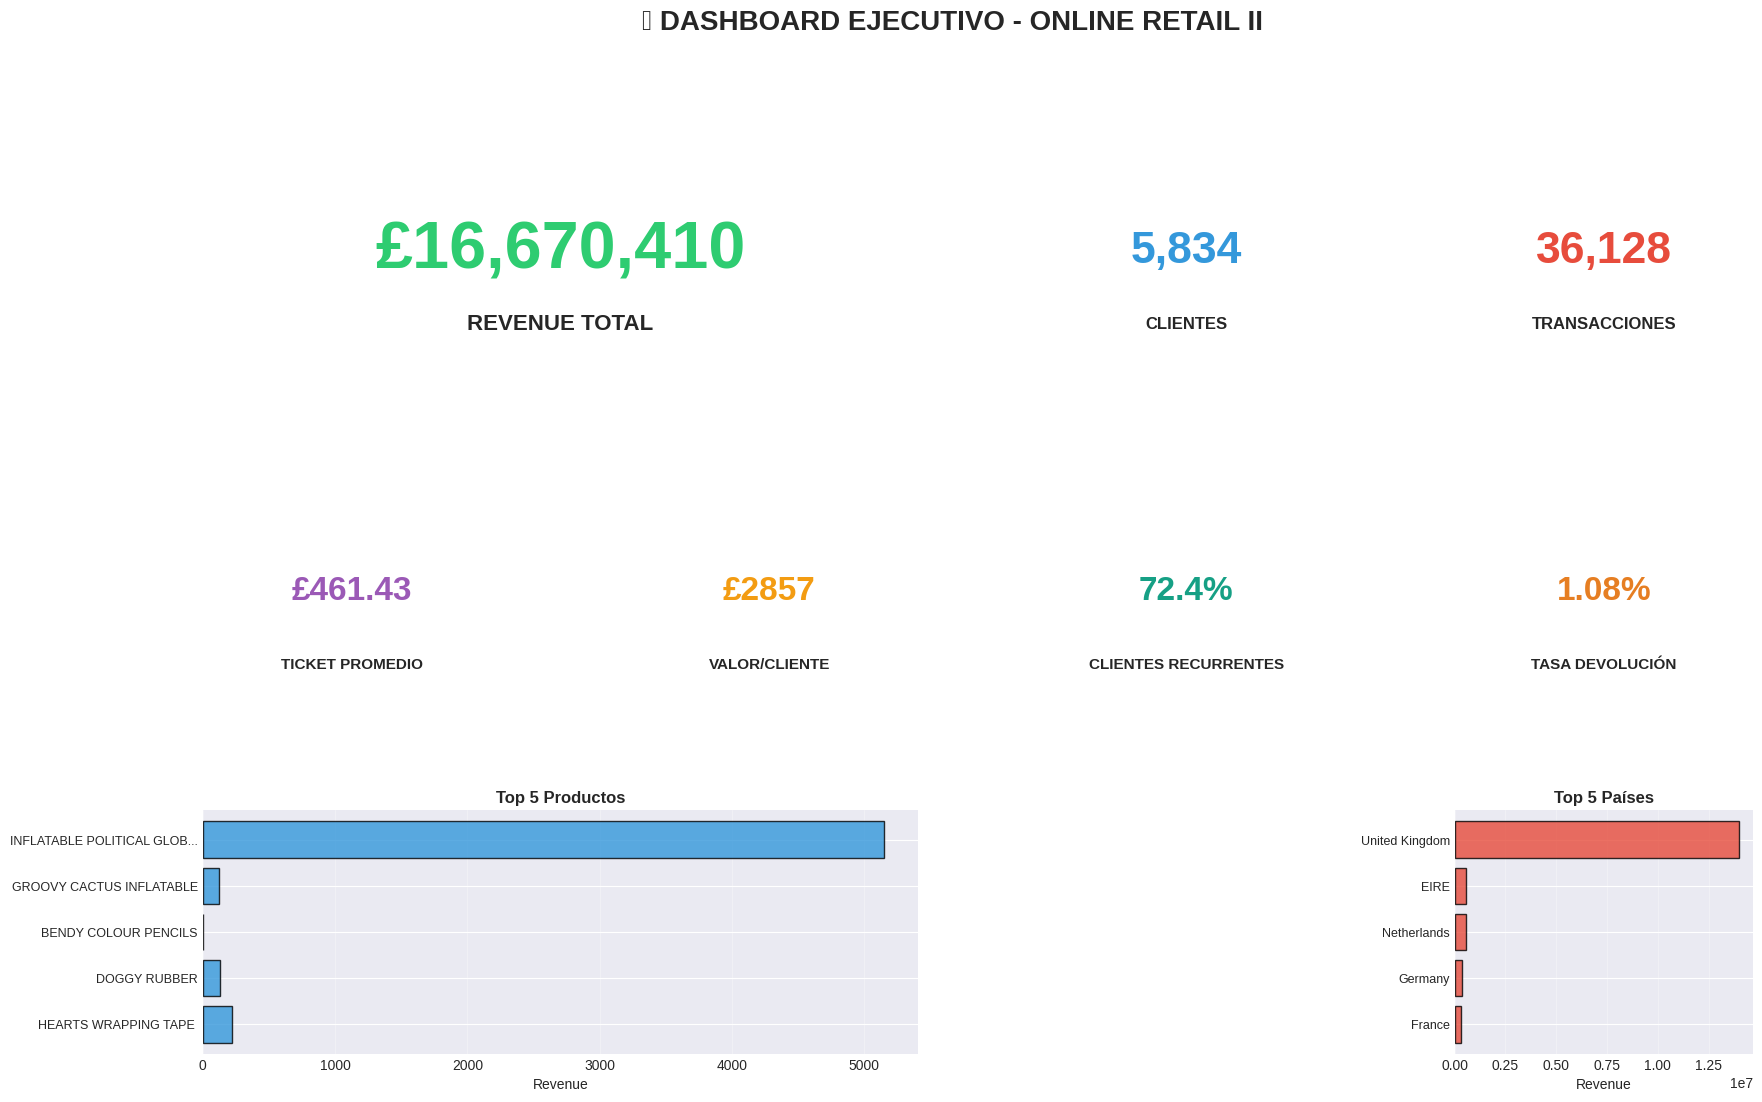

In [ ]:
# ----------------------------------------------------------------------------
# 21. DASHBOARD DE MÉTRICAS CLAVE
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("20. DASHBOARD DE MÉTRICAS CLAVE")
print("=" * 80)

# Crear un dashboard visual con las métricas más importantes
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.4)

# Título del dashboard
fig.suptitle('📊 DASHBOARD EJECUTIVO - ONLINE RETAIL II',
             fontsize=20, fontweight='bold', y=0.98)

# 1. Revenue Total (grande)
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.text(0.5, 0.5, f'£{total_revenue:,.0f}',
         ha='center', va='center', fontsize=48, fontweight='bold', color='#2ECC71')
ax1.text(0.5, 0.2, 'REVENUE TOTAL',
         ha='center', va='center', fontsize=16, fontweight='bold')
ax1.axis('off')
ax1.set_facecolor('#F0F0F0')

# 2. Total Clientes
ax2 = fig.add_subplot(gs[0, 2])
ax2.text(0.5, 0.5, f'{total_customers:,}',
         ha='center', va='center', fontsize=32, fontweight='bold', color='#3498DB')
ax2.text(0.5, 0.2, 'CLIENTES',
         ha='center', va='center', fontsize=12, fontweight='bold')
ax2.axis('off')
ax2.set_facecolor('#F0F0F0')

# 3. Total Transacciones
ax3 = fig.add_subplot(gs[0, 3])
ax3.text(0.5, 0.5, f'{total_transactions:,}',
         ha='center', va='center', fontsize=32, fontweight='bold', color='#E74C3C')
ax3.text(0.5, 0.2, 'TRANSACCIONES',
         ha='center', va='center', fontsize=12, fontweight='bold')
ax3.axis('off')
ax3.set_facecolor('#F0F0F0')

# 4. Ticket Promedio
ax4 = fig.add_subplot(gs[1, 0])
ax4.text(0.5, 0.5, f'£{avg_ticket:.2f}',
         ha='center', va='center', fontsize=24, fontweight='bold', color='#9B59B6')
ax4.text(0.5, 0.2, 'TICKET PROMEDIO',
         ha='center', va='center', fontsize=11, fontweight='bold')
ax4.axis('off')
ax4.set_facecolor('#F0F0F0')

# 5. Valor Promedio Cliente
ax5 = fig.add_subplot(gs[1, 1])
ax5.text(0.5, 0.5, f'£{avg_customer_value:.0f}',
         ha='center', va='center', fontsize=24, fontweight='bold', color='#F39C12')
ax5.text(0.5, 0.2, 'VALOR/CLIENTE',
         ha='center', va='center', fontsize=11, fontweight='bold')
ax5.axis('off')
ax5.set_facecolor('#F0F0F0')

# 6. Tasa de Retención
retention_rate = (recurring / total_customers * 100)
ax6 = fig.add_subplot(gs[1, 2])
ax6.text(0.5, 0.5, f'{retention_rate:.1f}%',
         ha='center', va='center', fontsize=24, fontweight='bold', color='#16A085')
ax6.text(0.5, 0.2, 'CLIENTES RECURRENTES',
         ha='center', va='center', fontsize=11, fontweight='bold')
ax6.axis('off')
ax6.set_facecolor('#F0F0F0')

# 7. Tasa de Devolución
ax7 = fig.add_subplot(gs[1, 3])
ax7.text(0.5, 0.5, f'{tasa_devolucion:.2f}%',
         ha='center', va='center', fontsize=24, fontweight='bold', color='#E67E22')
ax7.text(0.5, 0.2, 'TASA DEVOLUCIÓN',
         ha='center', va='center', fontsize=11, fontweight='bold')
ax7.axis('off')
ax7.set_facecolor('#F0F0F0')

# 8. Top 5 Productos (mini gráfico)
ax8 = fig.add_subplot(gs[2, 0:2])
top_5_prod = product_sales.head(5)
ax8.barh(range(len(top_5_prod)), top_5_prod['Revenue'].values,
         color='#3498DB', edgecolor='black', alpha=0.8)
ax8.set_yticks(range(len(top_5_prod)))
ax8.set_yticklabels([p[:25] + '...' if len(p) > 25 else p
                      for p in top_5_prod['Description']], fontsize=9)
ax8.set_xlabel('Revenue', fontsize=10)
ax8.set_title('Top 5 Productos', fontsize=12, fontweight='bold')
ax8.invert_yaxis()
ax8.grid(axis='x', alpha=0.3)


# 9. Top 5 Países
ax10 = fig.add_subplot(gs[2, 3])
top_5_countries_rev = country_sales.head(5)
ax10.barh(range(len(top_5_countries_rev)), top_5_countries_rev['Revenue'].values,
          color='#E74C3C', edgecolor='black', alpha=0.8)
ax10.set_yticks(range(len(top_5_countries_rev)))
ax10.set_yticklabels(top_5_countries_rev['Country'], fontsize=9)
ax10.set_xlabel('Revenue', fontsize=10)
ax10.set_title('Top 5 Países', fontsize=12, fontweight='bold')
ax10.invert_yaxis()
ax10.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()